Codigo utilizado en la plataforma Google Colab

# Importar gensim

Gensim carga el modelo de W2V

In [2]:
!pip install --upgrade gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 14.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
thinc 8.3.6 req

In [1]:
import gensim

# Descargar modelos de spacy

spacy para tokenizar

In [2]:
!python -m spacy download es_core_news_sm
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 121.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 126.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
#drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
import os
import sys
sys.path.append('/content/drive/MyDrive/UAM/PT/sentiment_analysis')


# Tiktok

## Cargar datos

In [ ]:
from src.trainers.utils import build_datasets, set_seed
from constants.constants_tiktok import TIKTOK_DATASET_SENTENCES

set_seed()

dataset_train, dataset_test, dataset_val = build_datasets(
    TIKTOK_DATASET_SENTENCES,
    test_size=0.3,
    val_size=0.5, # 0.5 de 0.3
    random_state=42,
    undersampling=True
)
print(dataset_train.shape)
print(dataset_test.shape)
print(dataset_val.shape)

(13727, 2)
(2942, 2)
(2942, 2)


## Tokenizar el texto

In [ ]:
from src.preprocesamiento.nlp_spacy import Tokenizer

tokenizer = Tokenizer()

dataset_train_tokenized = {}
dataset_val_tokenized = {}
dataset_test_tokenized = {}

dataset_train_tokenized['tokens'] = tokenizer.tokenize(dataset_train['text'], True)
dataset_val_tokenized['tokens'] = tokenizer.tokenize(dataset_val['text'], True)
dataset_test_tokenized['tokens'] = tokenizer.tokenize(dataset_test['text'], True)

dataset_train_tokenized['polarity'] = dataset_train['polarity'].to_numpy()
dataset_val_tokenized['polarity'] = dataset_val['polarity'].to_numpy()
dataset_test_tokenized['polarity'] = dataset_test['polarity'].to_numpy()

Modelo cargado: es_core_news_sm


100%|██████████| 2942/2942 [00:02<00:00, 1145.14it/s]


## Entrenar MLP

Parámetros ajustables

In [ ]:
import numpy as np
from sklearn.model_selection import ParameterGrid
from src.trainers.utils import EarlyStopping

param_grid = {
    "pooling": ["aver", "max"],
    "optim": ["adam", "sgd"],
    "lr": np.logspace(-3, -0.3, 10)
}

combinaciones = list(ParameterGrid(param_grid))
for idx, comb in enumerate(combinaciones, 1):
    print(f"Model {idx}: {comb}")

epochs = 200
patience = 15
min_delta = 1e-4
hp = {}
hp['batch_size'] = 64

model_args = {}
model_args['hidden_layers'] = [128, 64]
model_args['output_size'] = 3
model_args['dropout'] = 0.20

Model 1: {'lr': 0.001, 'optim': 'adam', 'pooling': 'aver'}
Model 2: {'lr': 0.001, 'optim': 'adam', 'pooling': 'max'}
Model 3: {'lr': 0.001, 'optim': 'sgd', 'pooling': 'aver'}
Model 4: {'lr': 0.001, 'optim': 'sgd', 'pooling': 'max'}
Model 5: {'lr': 0.001995262314968879, 'optim': 'adam', 'pooling': 'aver'}
Model 6: {'lr': 0.001995262314968879, 'optim': 'adam', 'pooling': 'max'}
Model 7: {'lr': 0.001995262314968879, 'optim': 'sgd', 'pooling': 'aver'}
Model 8: {'lr': 0.001995262314968879, 'optim': 'sgd', 'pooling': 'max'}
Model 9: {'lr': 0.003981071705534973, 'optim': 'adam', 'pooling': 'aver'}
Model 10: {'lr': 0.003981071705534973, 'optim': 'adam', 'pooling': 'max'}
Model 11: {'lr': 0.003981071705534973, 'optim': 'sgd', 'pooling': 'aver'}
Model 12: {'lr': 0.003981071705534973, 'optim': 'sgd', 'pooling': 'max'}
Model 13: {'lr': 0.00794328234724282, 'optim': 'adam', 'pooling': 'aver'}
Model 14: {'lr': 0.00794328234724282, 'optim': 'adam', 'pooling': 'max'}
Model 15: {'lr': 0.007943282347242

Device: cuda


 12%|█▏        | 24/200 [00:11<01:27,  2.02it/s, train_loss=0.531, val_loss=0.909]


[model_1 Acc: 0.6366] {'lr': 0.001, 'optim': 'adam', 'pooling': 'aver'}
New best accuracy (model_1)

Device: cuda


 11%|█         | 22/200 [00:10<01:24,  2.10it/s, train_loss=0.691, val_loss=0.942]


[model_2 Acc: 0.5935] {'lr': 0.001, 'optim': 'adam', 'pooling': 'max'}
Device: cuda


...

[model_38 Acc: 0.3331] {'lr': 0.5011872336272722, 'optim': 'adam', 'pooling': 'max'}
Device: cuda


 12%|█▏        | 24/200 [00:09<01:10,  2.51it/s, train_loss=0.53, val_loss=0.964]


[model_39 Acc: 0.6343] {'lr': 0.5011872336272722, 'optim': 'sgd', 'pooling': 'aver'}
Device: cuda


 12%|█▎        | 25/200 [00:10<01:11,  2.44it/s, train_loss=0.735, val_loss=1.11]


[model_40 Acc: 0.5360] {'lr': 0.5011872336272722, 'optim': 'sgd', 'pooling': 'max'}


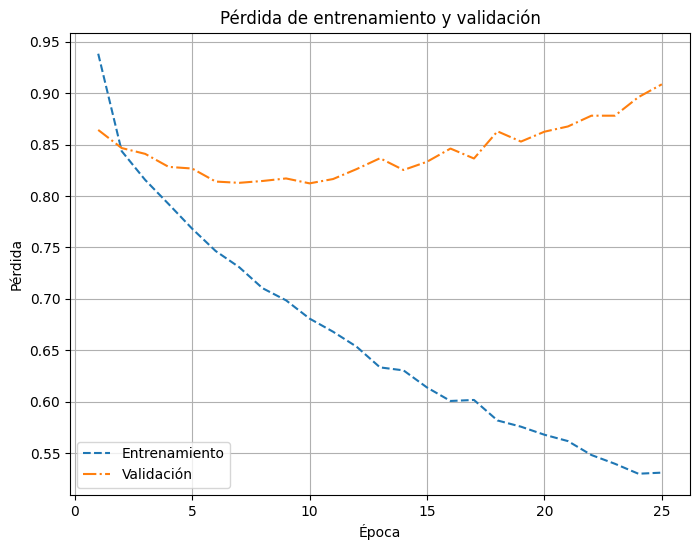

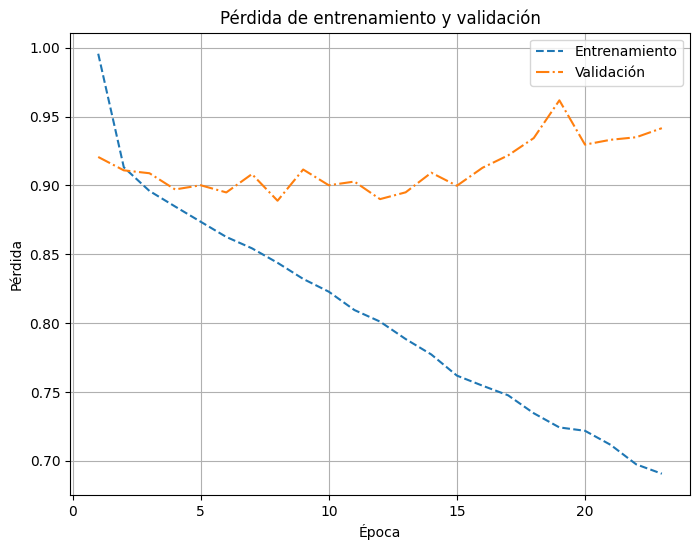

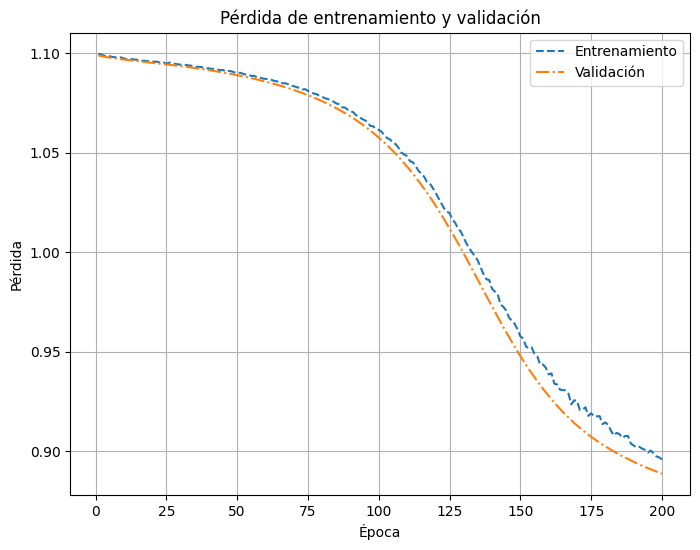

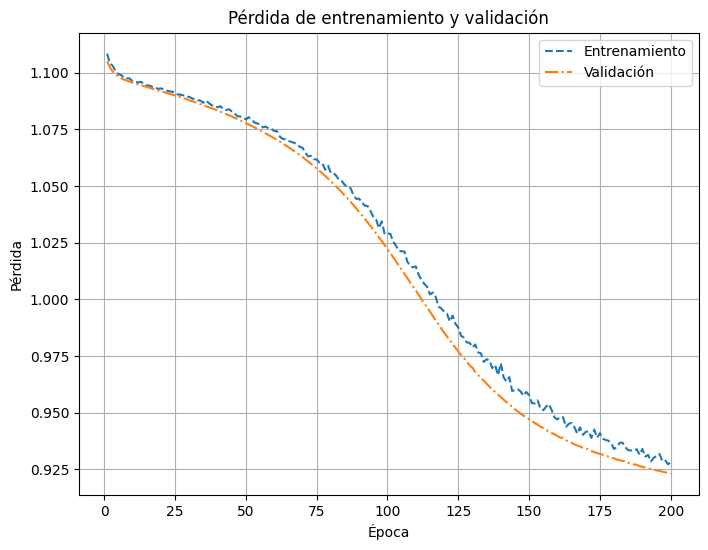

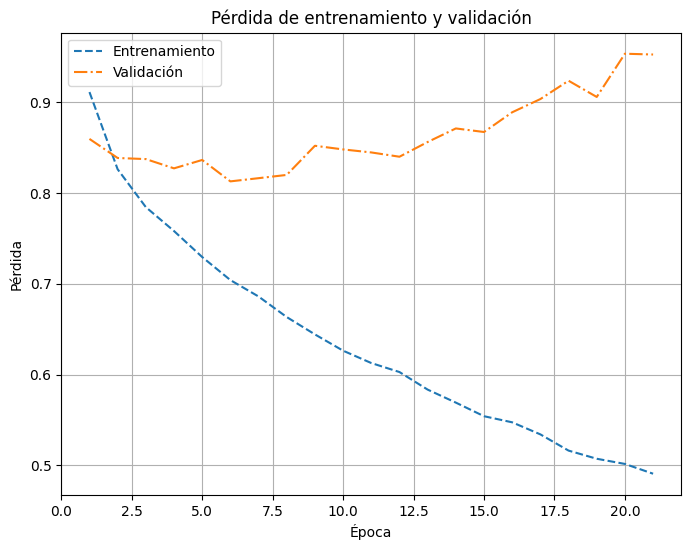

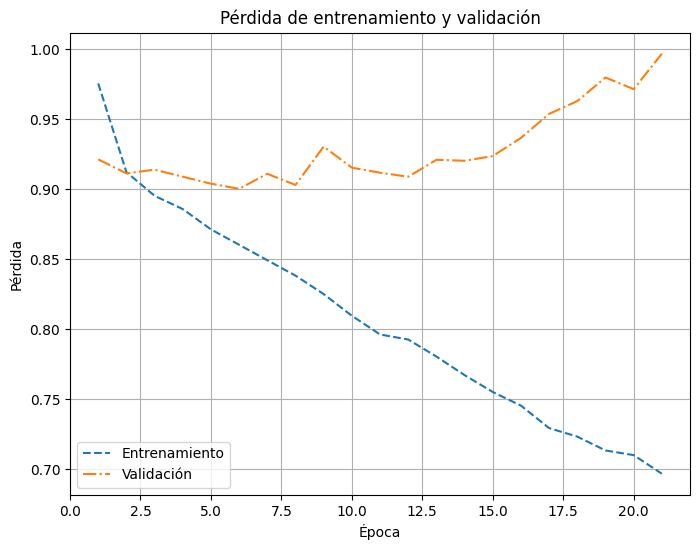

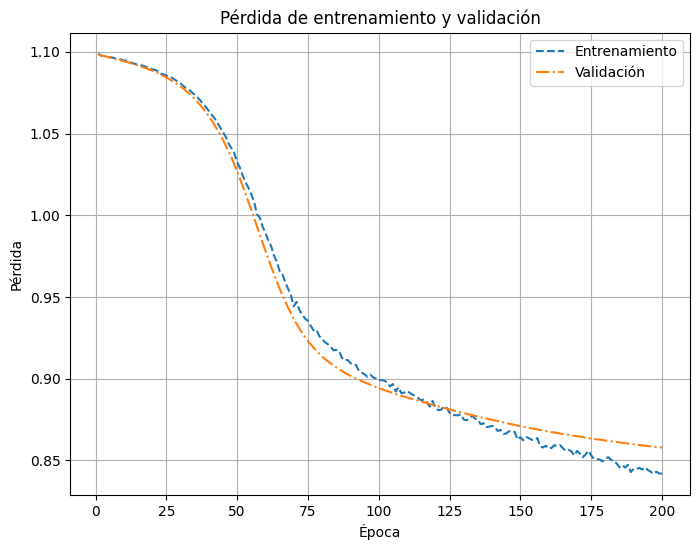

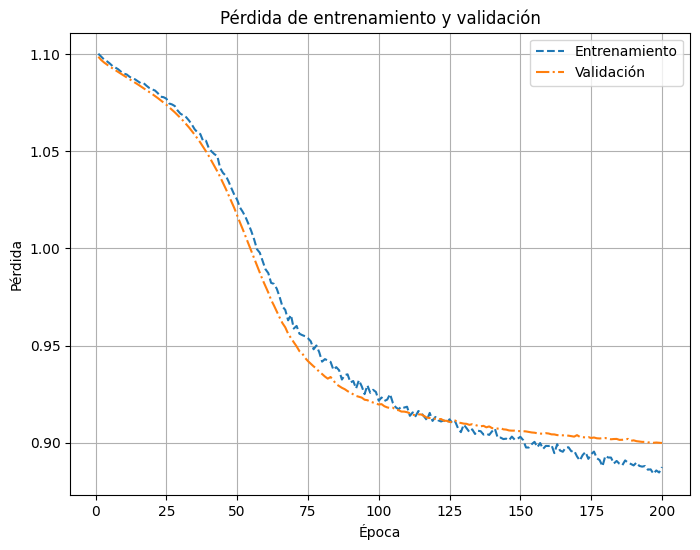

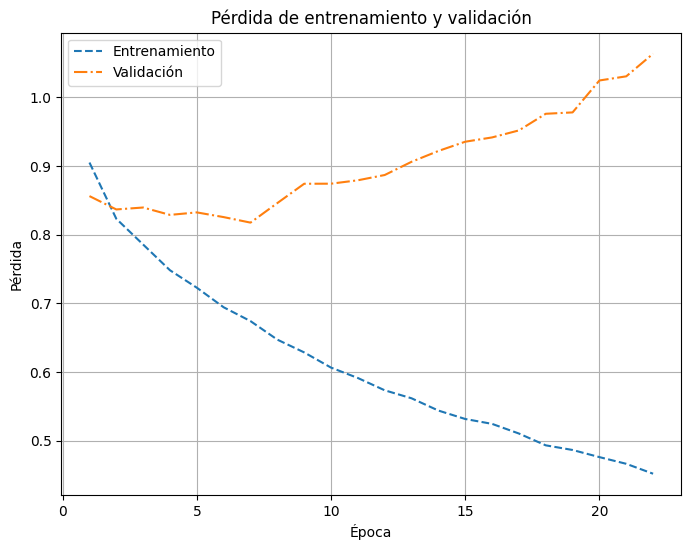

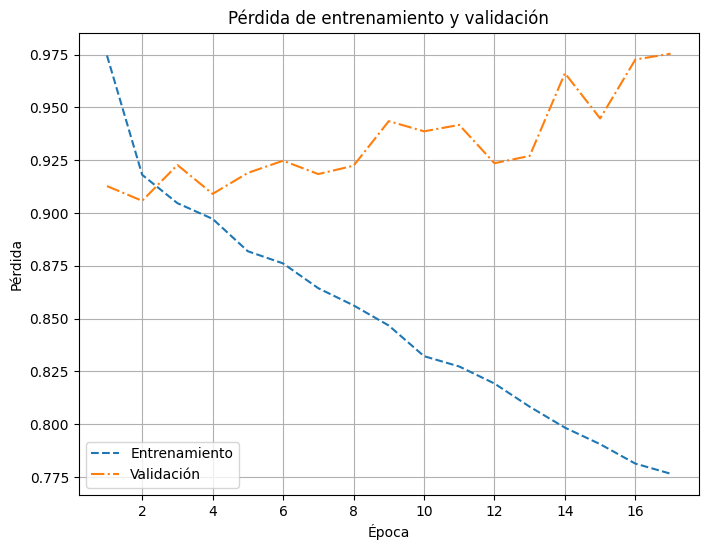

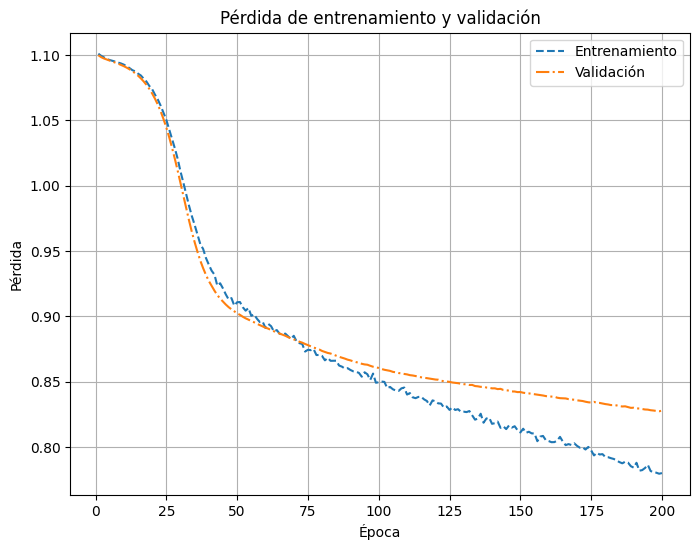

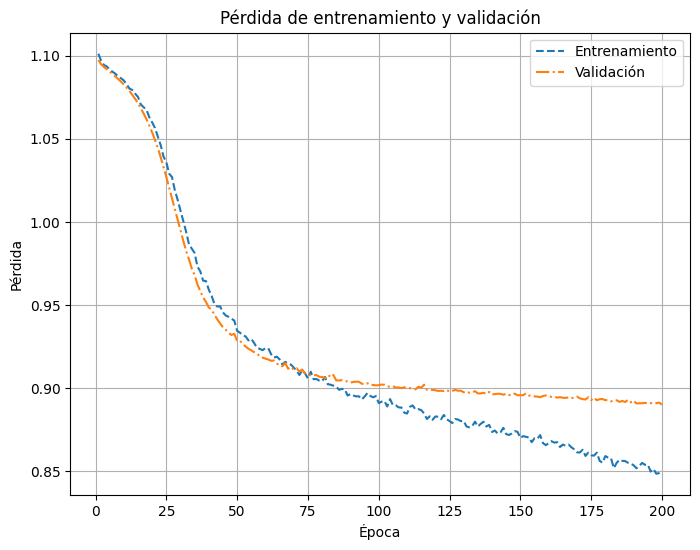

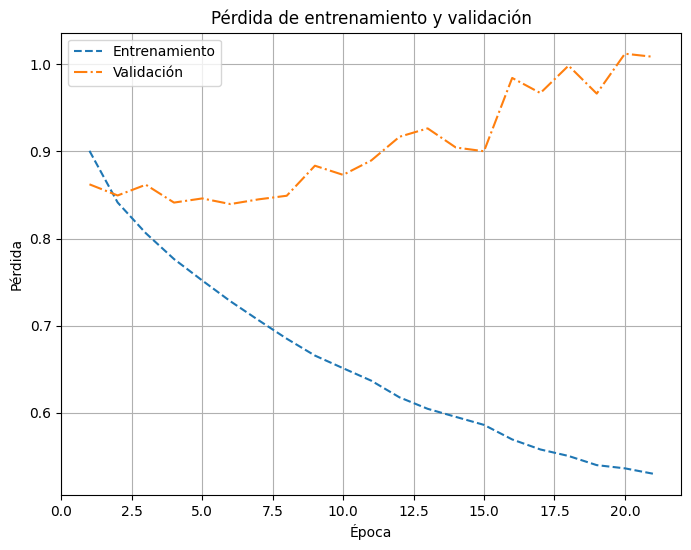

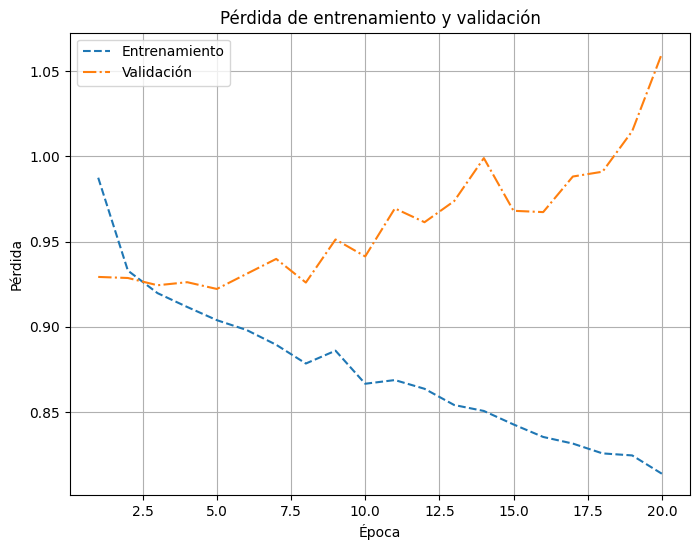

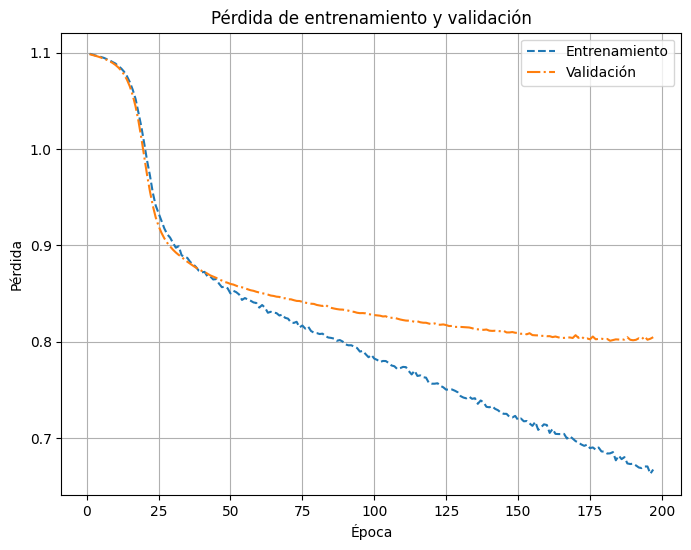

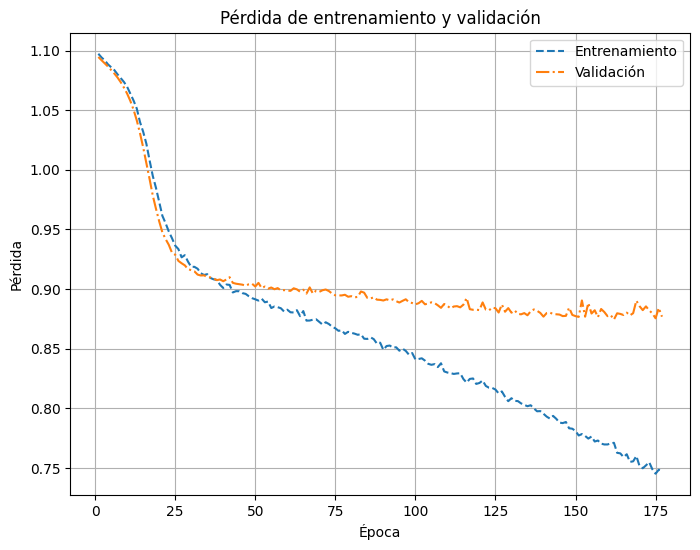

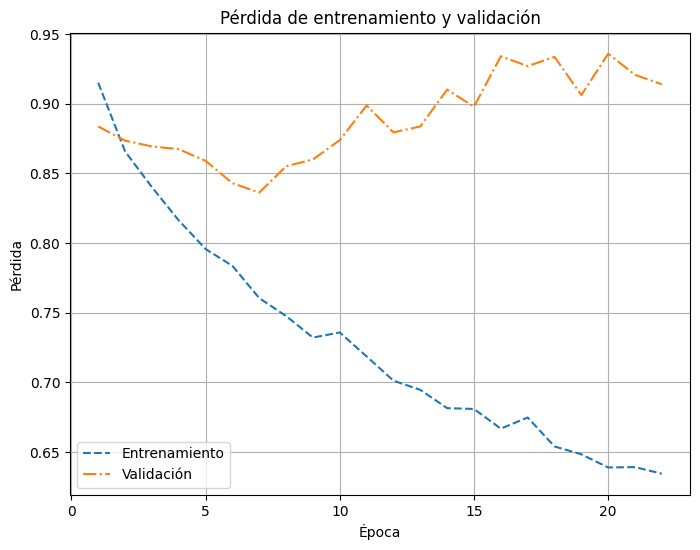

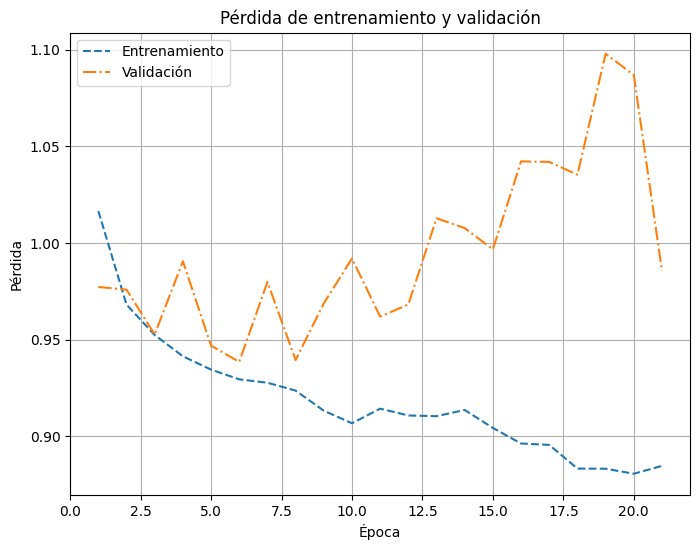

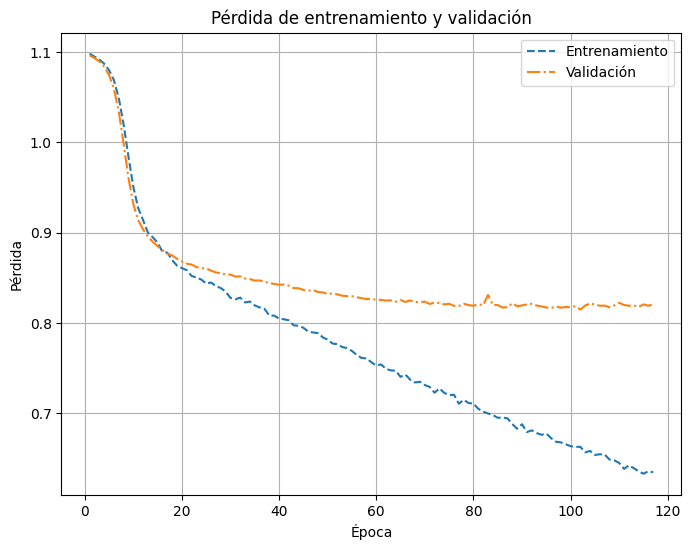

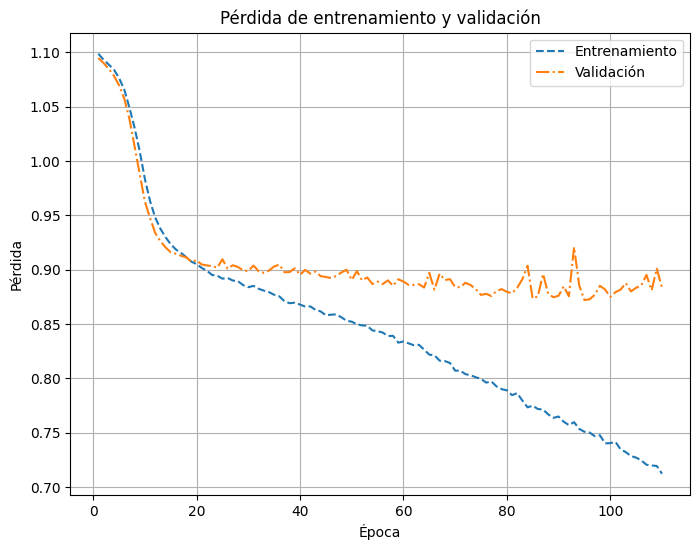

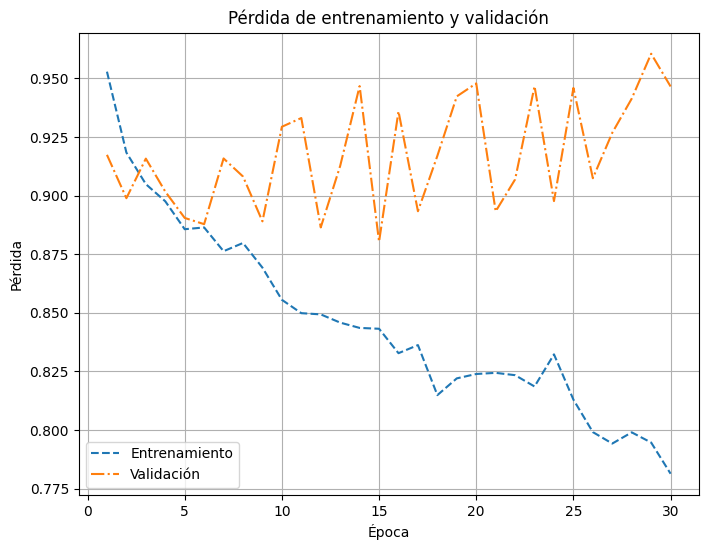

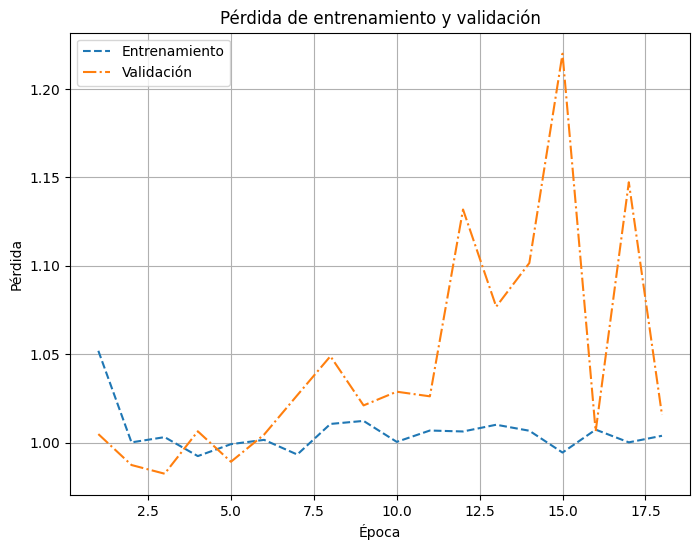

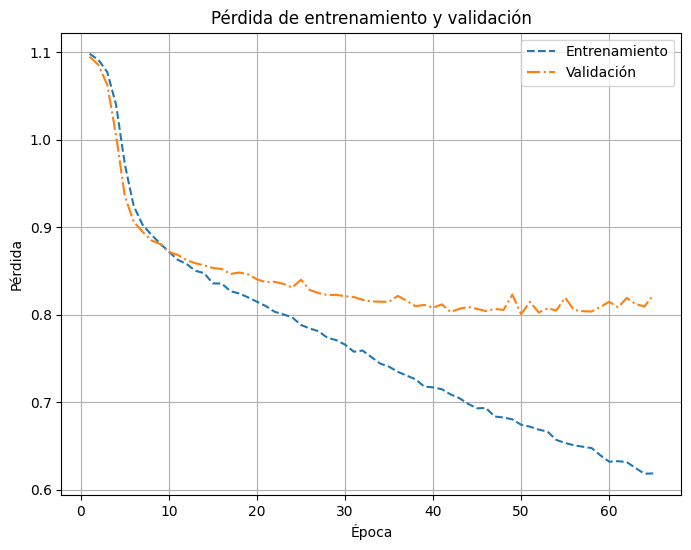

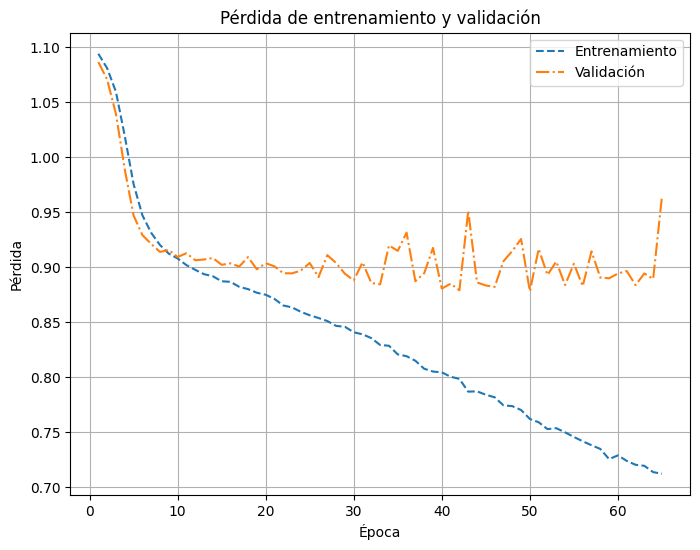

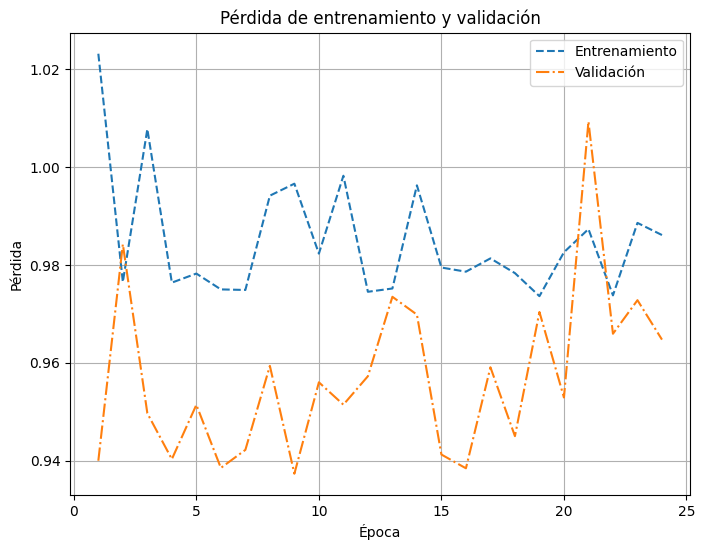

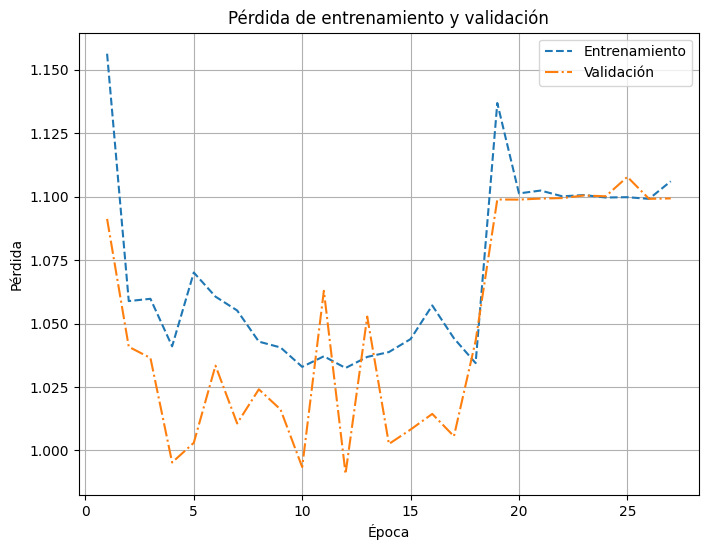

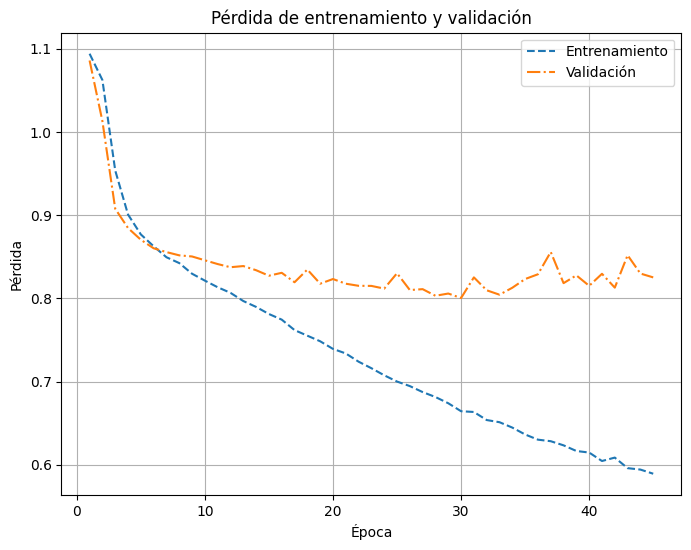

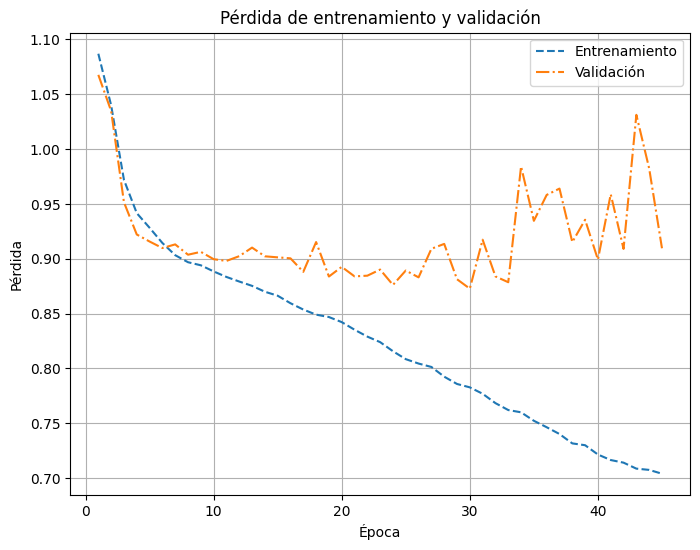

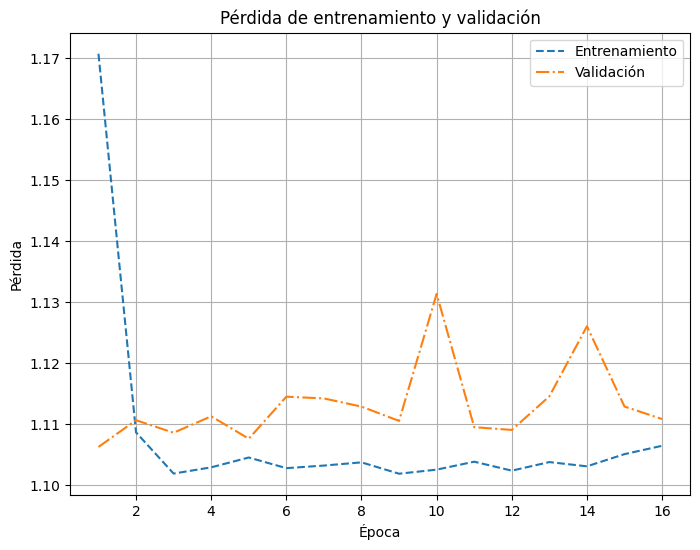

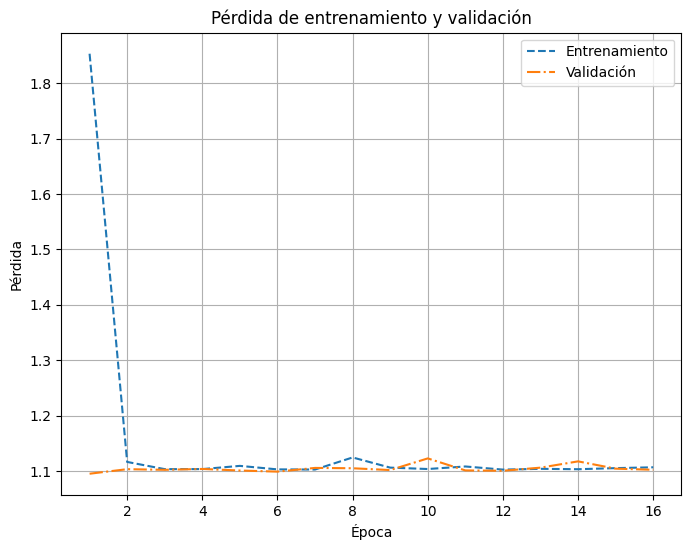

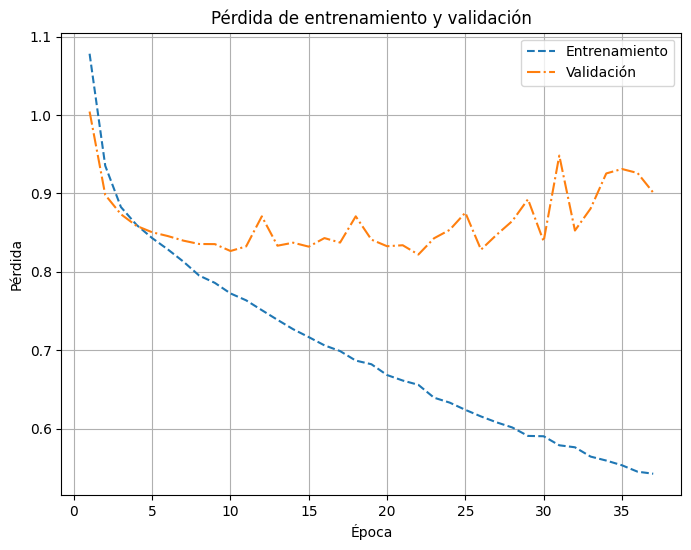

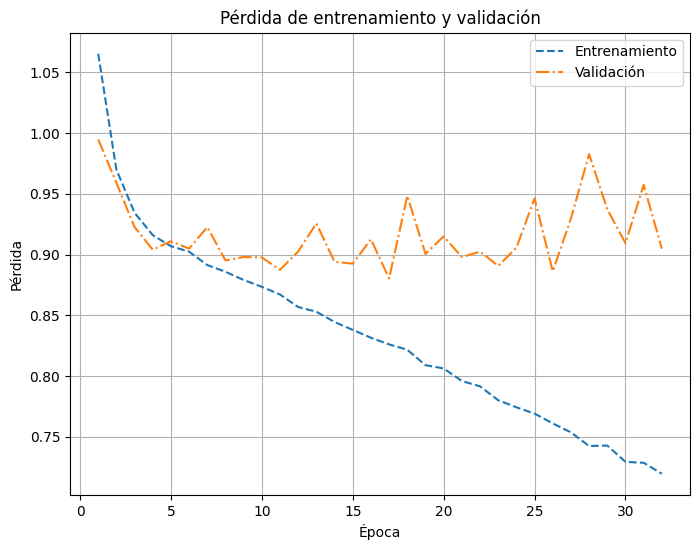

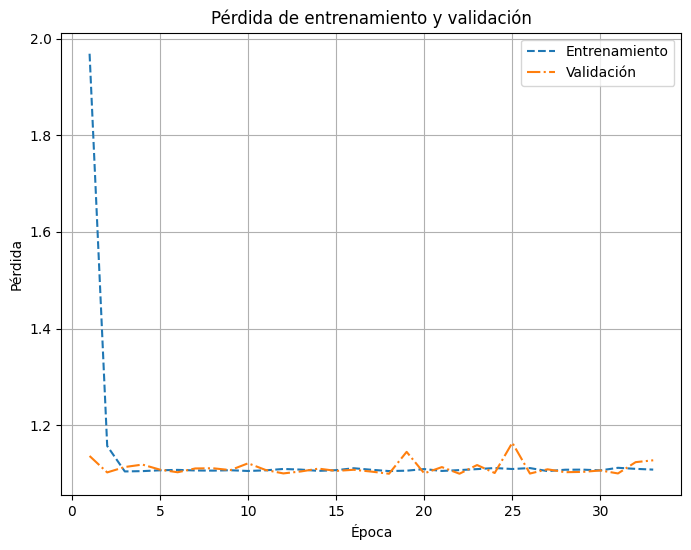

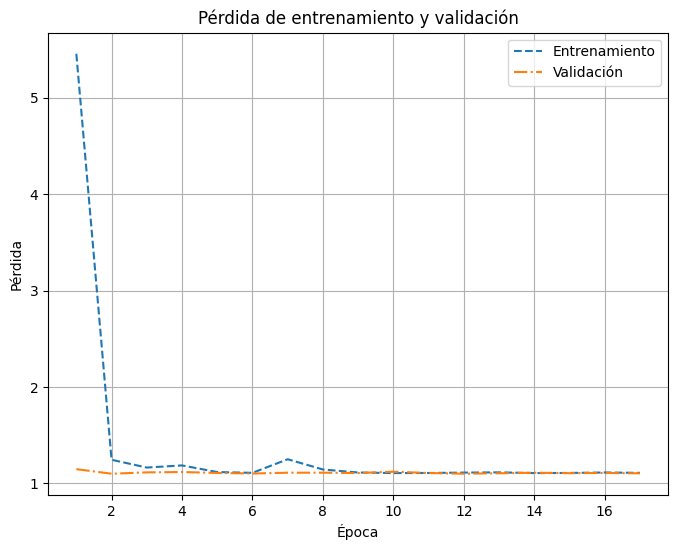

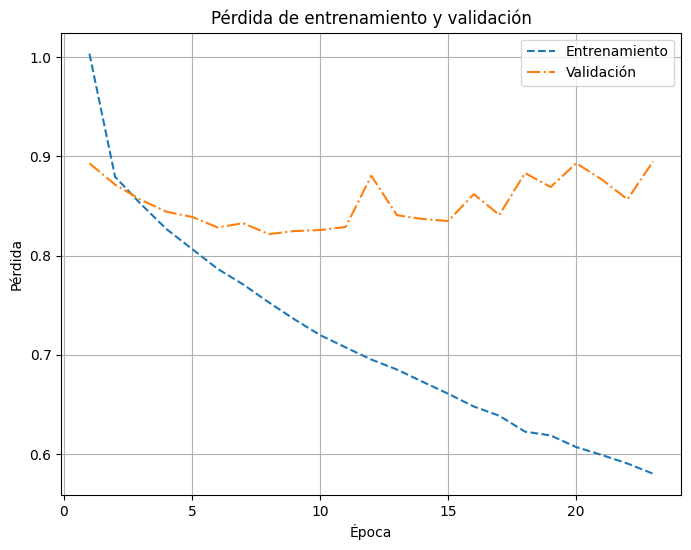

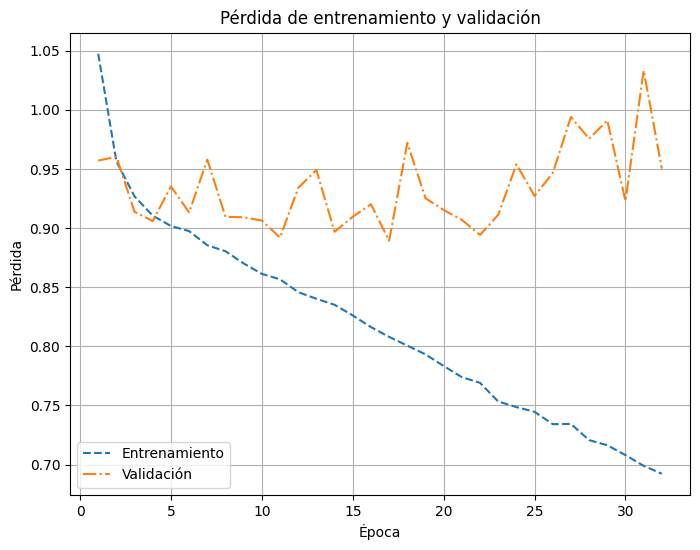

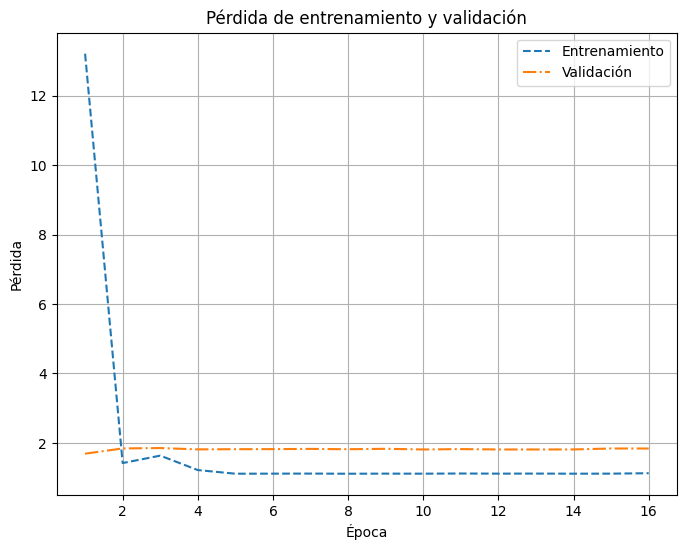

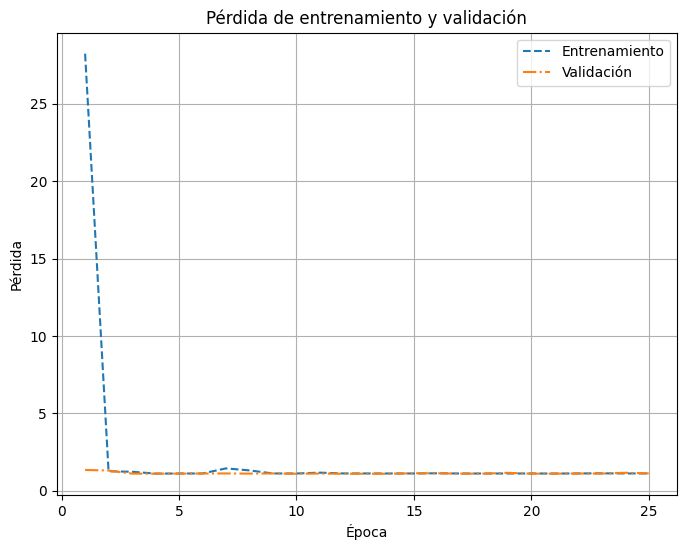

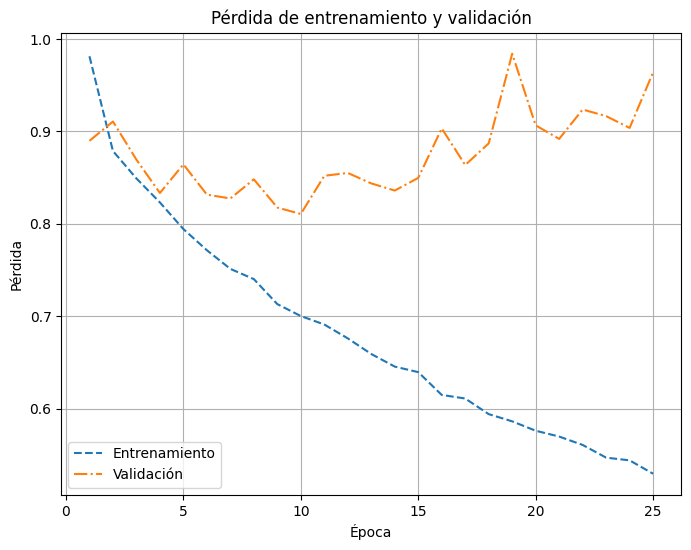

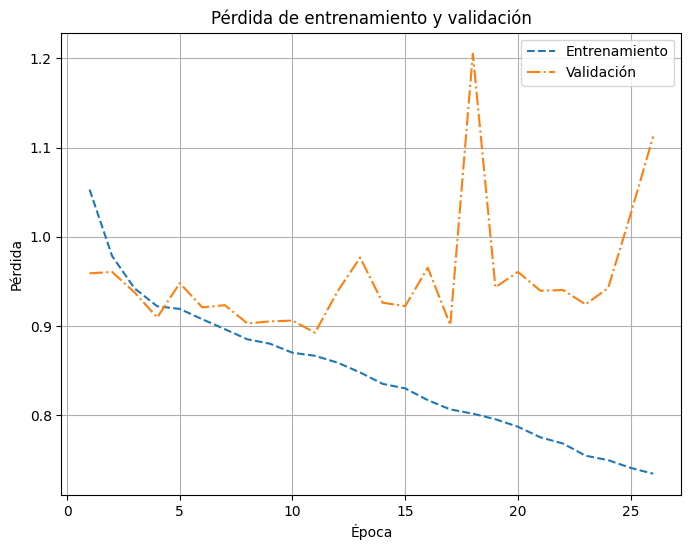

In [ ]:
from src.trainers.train_mlp import train_mlp
from src.trainers.utils import save_metrics, show_loss_val_curves, save_model_torch
from constants.constants_tiktok import MLP_LOSS_CURVES_DIR, MLP_MODEL_DIR, MLP_METRICS_PATH, EMBEDDING_W2V_TIKTOK_SENTENCES_PATH

best_accuracy = -1
for idx, param in enumerate(combinaciones, 1):
	model, metrics, train_losses, val_losses = train_mlp(
		dataset_train=dataset_train_tokenized,
    	dataset_val=dataset_val_tokenized,
    	embeddings_path=EMBEDDING_W2V_TIKTOK_SENTENCES_PATH,
    	model_args=model_args,
    	early_stopping = EarlyStopping(patience, min_delta),
    	batch_size=hp['batch_size'],
    	lr=param['lr'],
    	epochs=epochs,
    	optim=param['optim'],
    	pooling=param['pooling']
  	)

	metrics['name'] = f"model_{idx}"
	print(f"[{metrics['name']} Acc: {metrics['accuracy']:.4f}] {param}")
	save_metrics(metrics, MLP_METRICS_PATH)

	hp['pooling'] = param['pooling']
	model_args['input_size'] = metrics['embedding_dim']
	save_model_torch(model.get_model(), model_args, hp, os.path.join(MLP_MODEL_DIR, f"{metrics['name']}.pt"))

	title = f"Pérdida de entrenamiento y validación"
	path = os.path.join(MLP_LOSS_CURVES_DIR, f"{metrics['name']}.png")
	show_loss_val_curves(train_losses, val_losses, len(train_losses), title, path)

	if metrics['accuracy'] > best_accuracy:
		best_accuracy = metrics['accuracy']
		print(f"New best accuracy ({metrics['name']})\n")
		save_model_torch(model.get_model(), model_args, hp, os.path.join(MLP_MODEL_DIR, "best_model.pt"))

In [ ]:
import pandas as pd

# Seleccionar los hiperparámetros que generan mayor accuracy
df_metrics = pd.read_csv(MLP_METRICS_PATH)

best_acc = df_metrics.loc[df_metrics['accuracy'].idxmax()]
print(best_acc)

accuracy          0.652277
recall            0.652255
precision         0.652602
f1_score          0.649874
model             MLP SWEM
pooling               aver
optim                  sgd
lr                0.063096
patience                15
min_delta           0.0001
hidden_layers    [128, 64]
output_size              3
dropout                0.2
epochs              45/200
batch_size              64
embedding_dim          100
train_time       17.538045
name              model_27
Name: 26, dtype: object


In [ ]:
import torch
from src.trainers.train_mlp import evaluate_model, MLPModelCustom

checkpoint = torch.load(os.path.join(MLP_MODEL_DIR, "best_model.pt"))
config = checkpoint['config']
hp = checkpoint['hp']

model = MLPModelCustom(**config)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Inferencia (desactiva dropout)

metrics = evaluate_model(
    model,
    dataset_test_tokenized,
    "MLP",
    EMBEDDING_W2V_TIKTOK_SENTENCES_PATH,
    hp['pooling'], hp['batch_size']
)
display(metrics)

## Entrenar RNN

In [ ]:
import numpy as np
from sklearn.model_selection import ParameterGrid
from src.trainers.utils import EarlyStopping

param_grid = {
  "optim": ["adam", "sgd"],
  "lr": np.logspace(-3, -0.3, 10) # 0.003? # CAMBIA A 5
}

combinaciones = list(ParameterGrid(param_grid))
for idx, comb in enumerate(combinaciones, 1):
    print(f"Model {idx}: {comb}")

epochs = 200
patience = 15
min_delta = 1e-4
hp = {}
hp['batch_size'] = 64

model_args = {}
model_args['hidden_size'] = 128
model_args['num_layers'] = 2
model_args['output_size'] = 3
model_args['dropout'] = 0.20

Model 1: {'lr': 0.001, 'optim': 'adam'}
Model 2: {'lr': 0.001, 'optim': 'sgd'}
Model 3: {'lr': 0.001995262314968879, 'optim': 'adam'}
Model 4: {'lr': 0.001995262314968879, 'optim': 'sgd'}
Model 5: {'lr': 0.003981071705534973, 'optim': 'adam'}
Model 6: {'lr': 0.003981071705534973, 'optim': 'sgd'}
Model 7: {'lr': 0.00794328234724282, 'optim': 'adam'}
Model 8: {'lr': 0.00794328234724282, 'optim': 'sgd'}
Model 9: {'lr': 0.01584893192461114, 'optim': 'adam'}
Model 10: {'lr': 0.01584893192461114, 'optim': 'sgd'}
Model 11: {'lr': 0.03162277660168381, 'optim': 'adam'}
Model 12: {'lr': 0.03162277660168381, 'optim': 'sgd'}
Model 13: {'lr': 0.06309573444801936, 'optim': 'adam'}
Model 14: {'lr': 0.06309573444801936, 'optim': 'sgd'}
Model 15: {'lr': 0.12589254117941687, 'optim': 'adam'}
Model 16: {'lr': 0.12589254117941687, 'optim': 'sgd'}
Model 17: {'lr': 0.25118864315095824, 'optim': 'adam'}
Model 18: {'lr': 0.25118864315095824, 'optim': 'sgd'}
Model 19: {'lr': 0.5011872336272722, 'optim': 'adam'

Device: cuda


 10%|█         | 20/200 [00:43<06:27,  2.15s/it, train_loss=0.529, val_loss=1.01]


[model_1 Acc: 0.5795] {'lr': 0.001, 'optim': 'adam'}
New best accuracy (model_1)

Device: cuda


 90%|█████████ | 181/200 [05:59<00:37,  1.99s/it, train_loss=0.792, val_loss=0.832]


[model_2 Acc: 0.6278] {'lr': 0.001, 'optim': 'sgd'}
New best accuracy (model_2)

Device: cuda


...

[model_18 Acc: 0.5153] {'lr': 0.25118864315095824, 'optim': 'sgd'}
Device: cuda


  8%|▊         | 17/200 [00:37<06:38,  2.18s/it, train_loss=4.08, val_loss=5.6]


[model_19 Acc: 0.3562] {'lr': 0.5011872336272722, 'optim': 'adam'}
Device: cuda


  9%|▉         | 18/200 [00:37<06:23,  2.11s/it, train_loss=3.26, val_loss=4.72]


[model_20 Acc: 0.3243] {'lr': 0.5011872336272722, 'optim': 'sgd'}


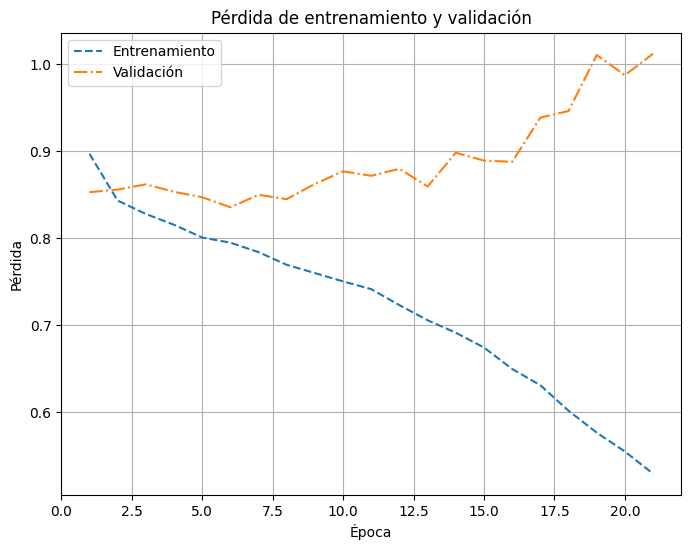

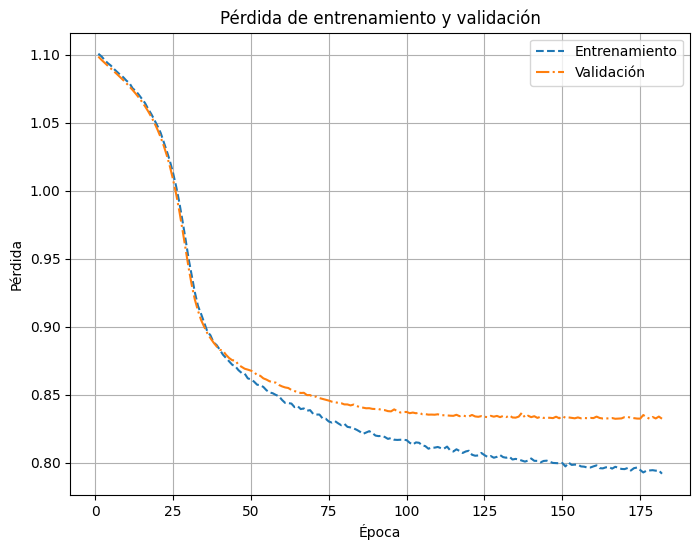

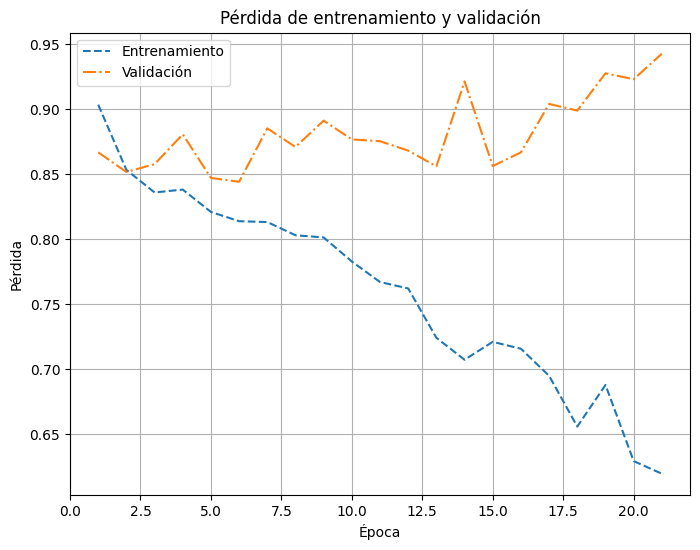

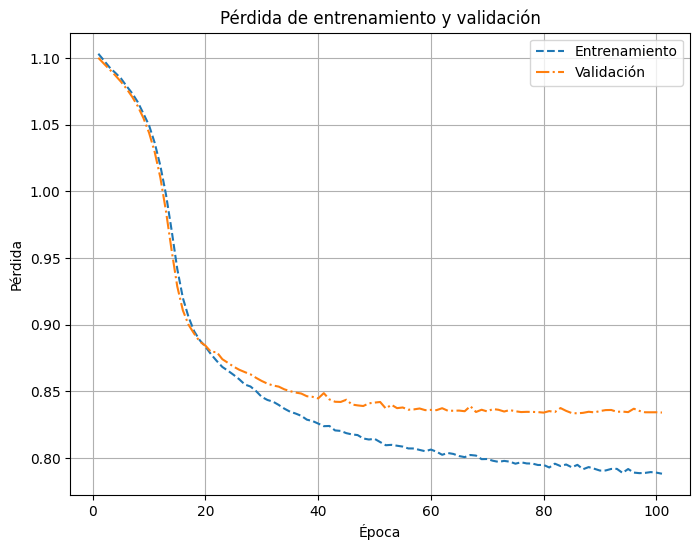

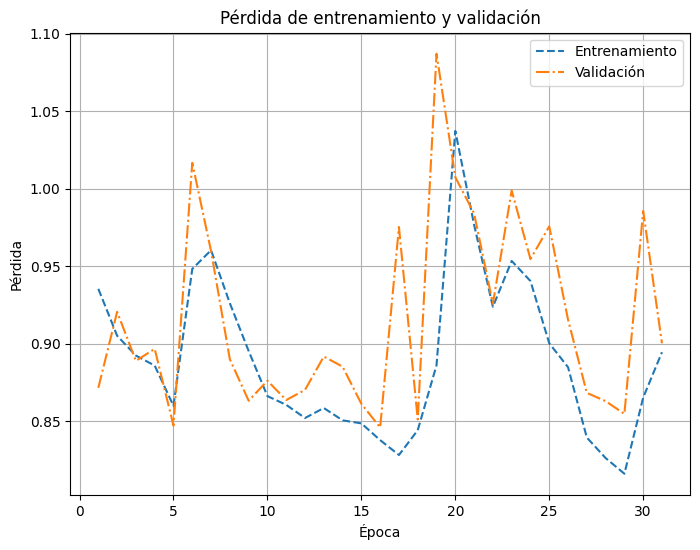

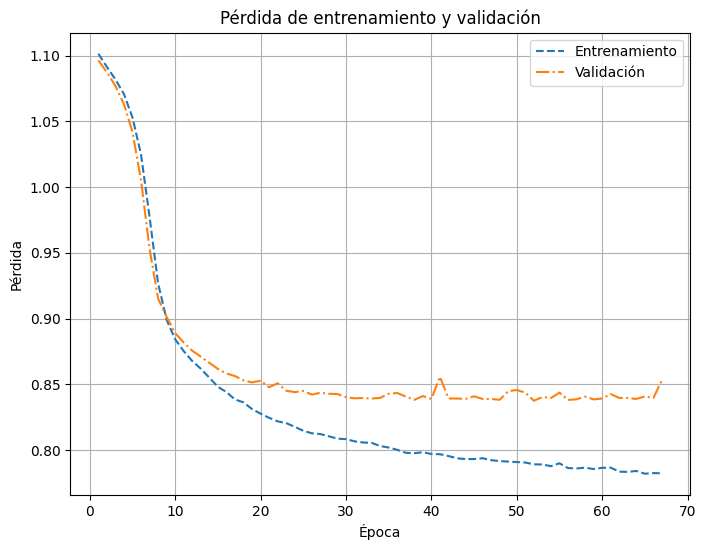

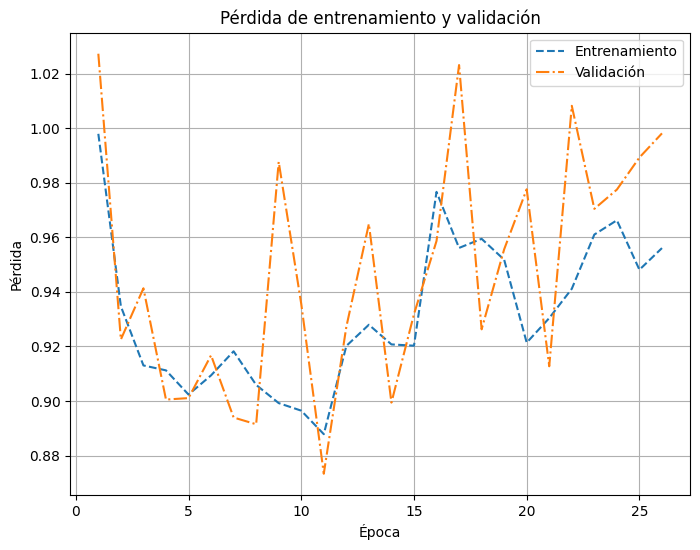

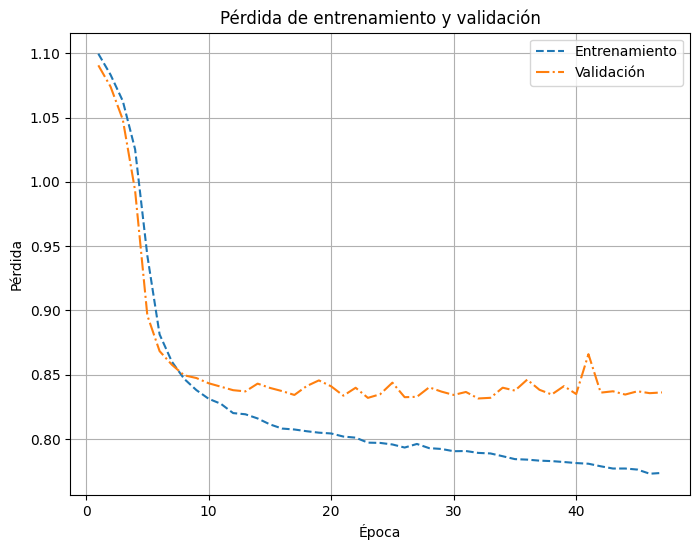

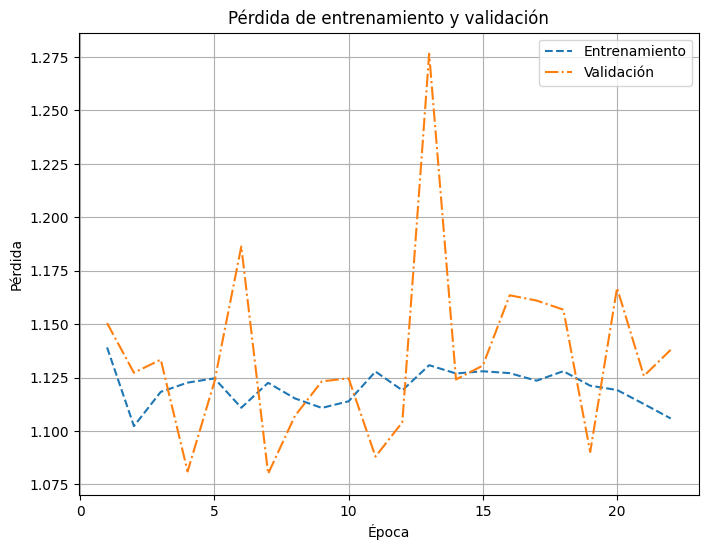

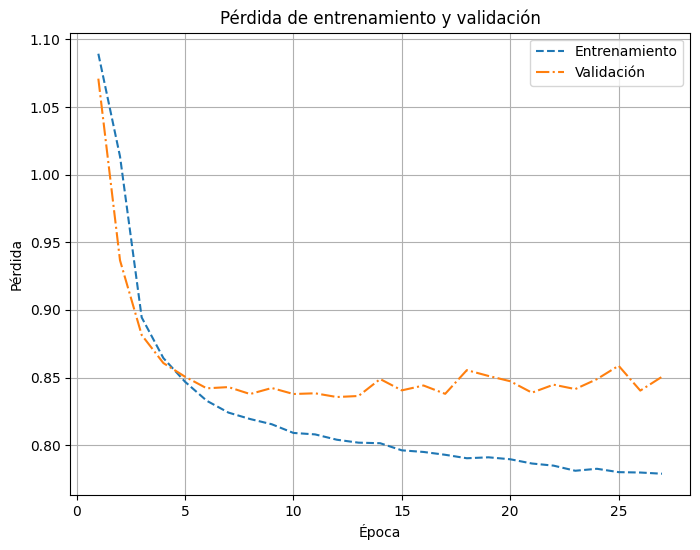

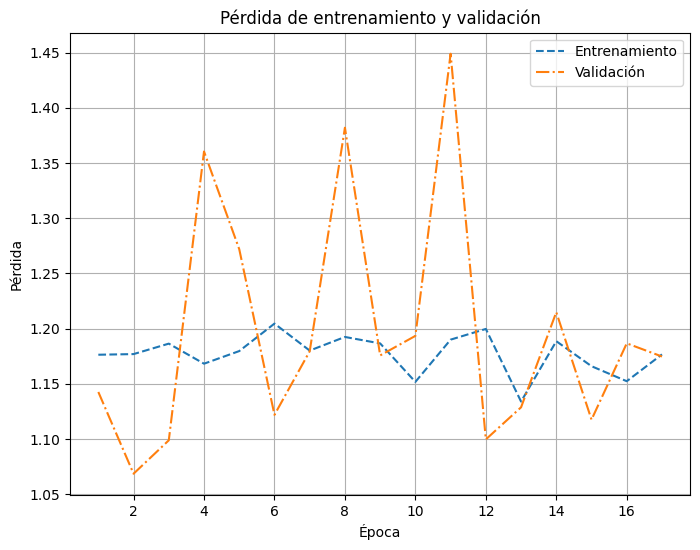

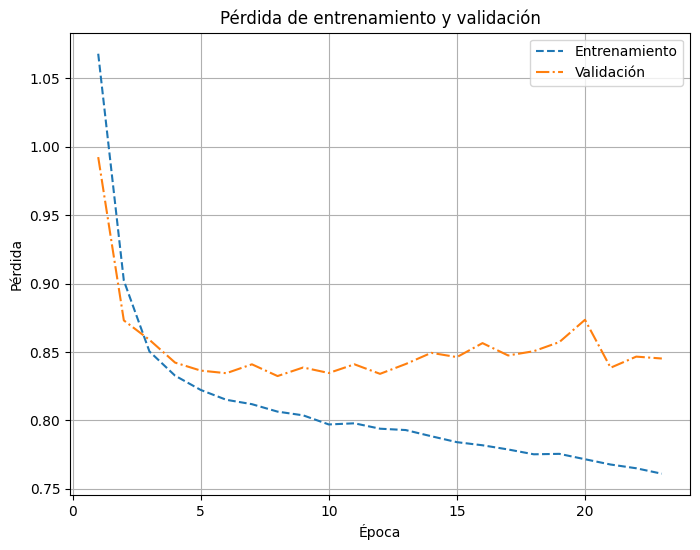

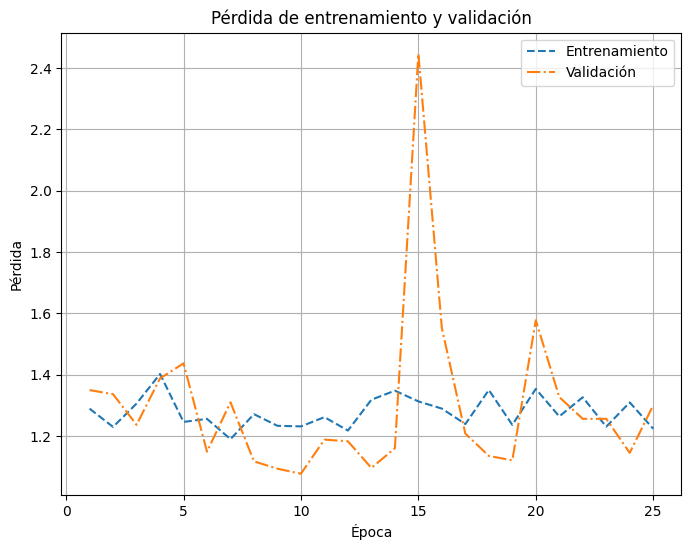

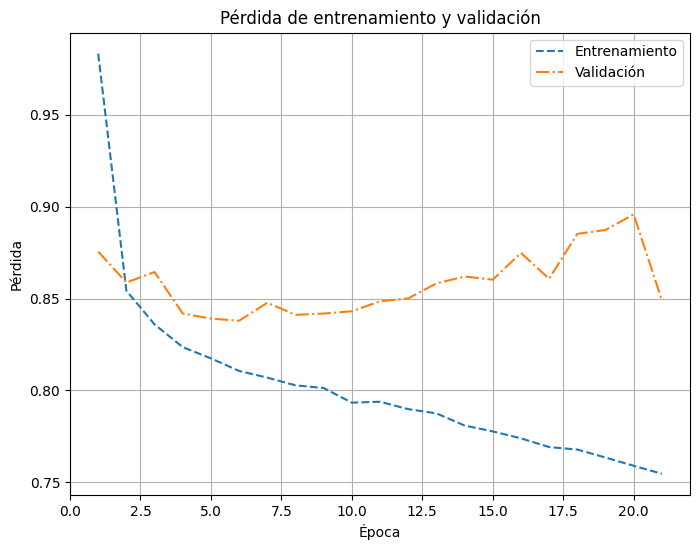

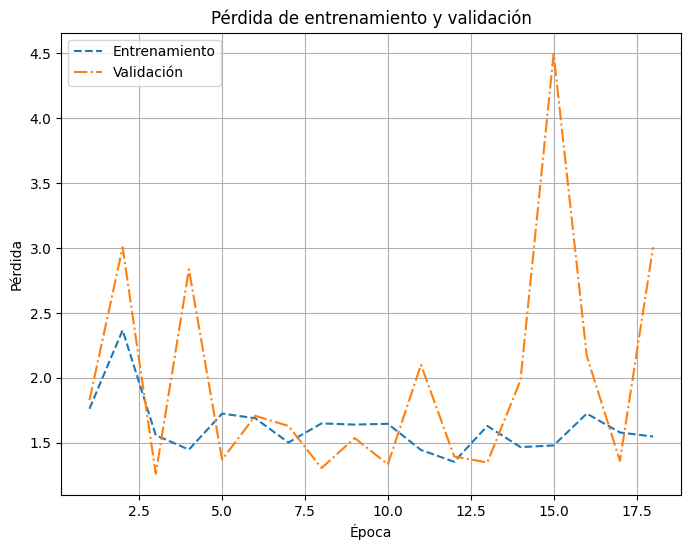

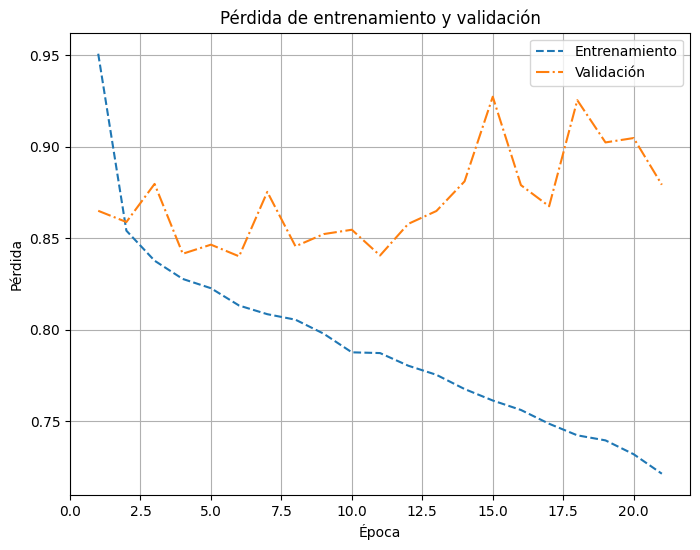

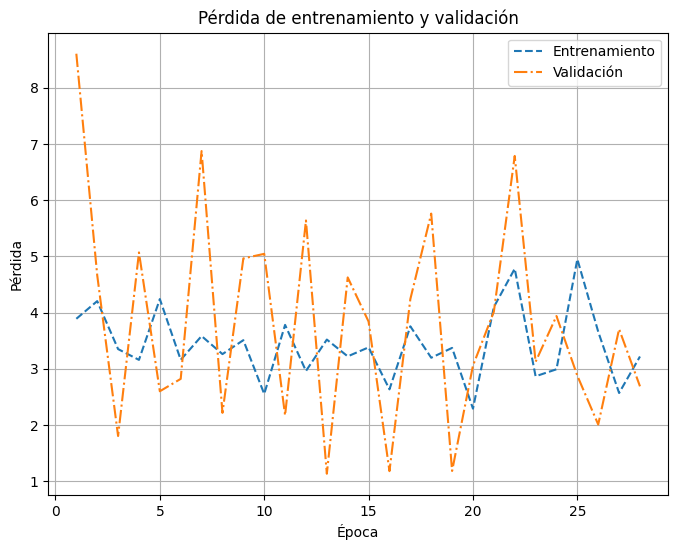

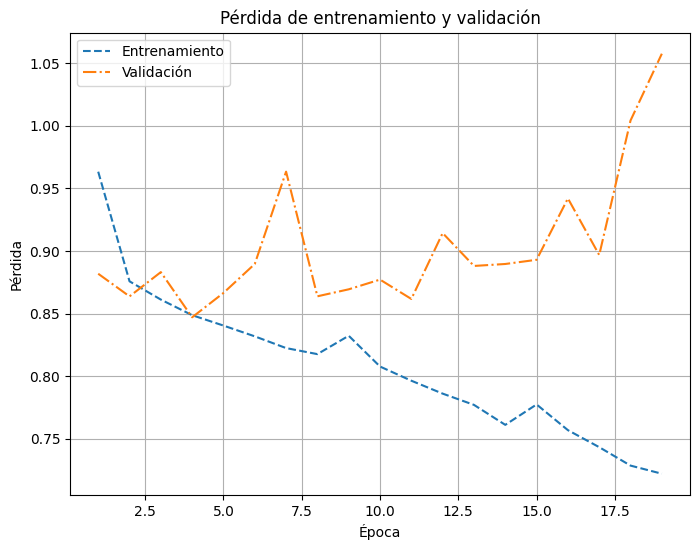

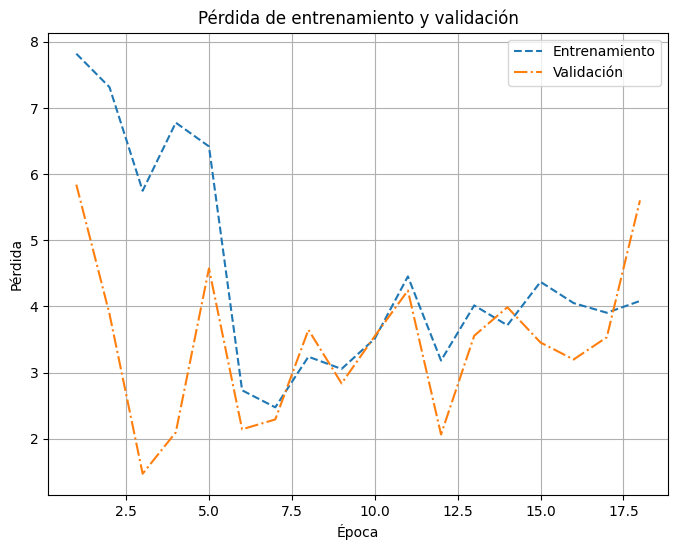

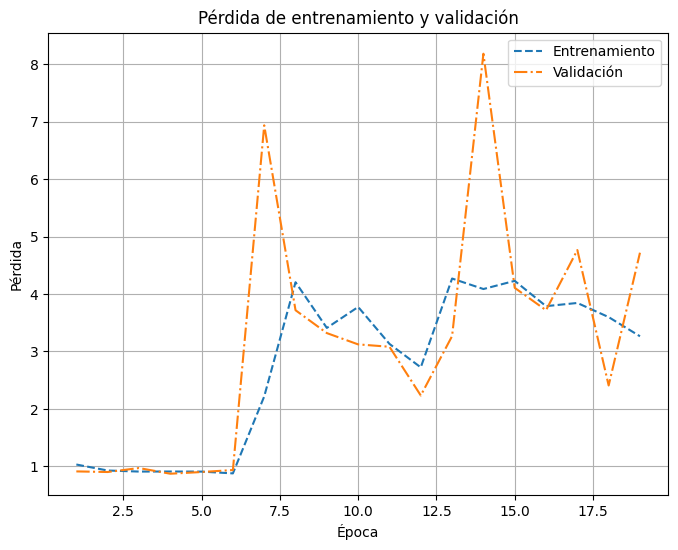

In [ ]:
from src.trainers.train_rnn import train_rnn
from src.trainers.utils import save_metrics, show_loss_val_curves, save_model_torch
from constants.constants_tiktok import RNN_LOSS_CURVES_DIR, RNN_MODEL_DIR, RNN_METRICS_PATH, EMBEDDING_W2V_TIKTOK_SENTENCES_PATH

best_accuracy = -1
for idx, param in enumerate(combinaciones, 1):
    model, metrics, train_losses, val_losses = train_rnn(
        dataset_train=dataset_train_tokenized,
        dataset_val=dataset_val_tokenized,
        embeddings_path=EMBEDDING_W2V_TIKTOK_SENTENCES_PATH,
        model_args=model_args,
        early_stopping = EarlyStopping(patience, min_delta), # reinicio
        batch_size=hp['batch_size'],
        lr=param['lr'],
        epochs=epochs,
        optim=param['optim'],
    )

    metrics['name'] = f"model_{idx}"
    print(f"[{metrics['name']} Acc: {metrics['accuracy']:.4f}] {param}")
    save_metrics(metrics, RNN_METRICS_PATH)

    model_args['input_size'] = metrics['embedding_dim']
    save_model_torch(model.get_model(), model_args, hp, os.path.join(RNN_MODEL_DIR, f"{metrics['name']}.pt"))

    title = f"Pérdida de entrenamiento y validación"
    path = os.path.join(RNN_LOSS_CURVES_DIR, f"{metrics['name']}.png")
    show_loss_val_curves(train_losses, val_losses, len(train_losses), title, path)

    if metrics['accuracy'] > best_accuracy:
        best_accuracy = metrics['accuracy']
        print(f"New best accuracy ({metrics['name']})\n")
        save_model_torch(model.get_model(), model_args, hp, os.path.join(RNN_MODEL_DIR, "best_model.pt"))

In [ ]:
import pandas as pd

# Seleccionar los hiperparámetros que generan mayor accuracy
df_metrics = pd.read_csv(RNN_METRICS_PATH)

best_acc = df_metrics.loc[df_metrics['accuracy'].idxmax()]
print(best_acc)

accuracy          0.632223
recall            0.632175
precision         0.630227
f1_score          0.628237
model                  RNN
optim                  sgd
lr                0.007943
patience                15
min_delta           0.0001
num_layers               2
hidden_size            128
dropout                0.2
epochs              47/200
batch_size              64
embedding_dim          100
train_time       91.406702
name               model_8
Name: 7, dtype: object


In [ ]:
import torch
from src.trainers.train_rnn import RNNModel
from src.trainers.trainer_rnn import evaluate_model

checkpoint = torch.load(os.path.join(RNN_MODEL_DIR, "best_model.pt"))
config = checkpoint['config']
hp = checkpoint['hp']

model = RNNModel(**config)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Inferencia (desactiva dropout)

metrics = evaluate_model(
    model,
    dataset_test_tokenized,
    "RNN",
    EMBEDDING_W2V_TIKTOK_SENTENCES_PATH,
    hp['batch_size']
)
display(metrics)

## Entenar LSTM

In [ ]:
import numpy as np
from sklearn.model_selection import ParameterGrid
from src.trainers.utils import EarlyStopping

param_grid = {
  "optim": ["adam", "sgd"],
  "lr": np.logspace(-3, -0.3, 10)
}

combinaciones = list(ParameterGrid(param_grid))
for idx, comb in enumerate(combinaciones, 1):
    print(f"Model {idx}: {comb}")

epochs = 200
patience = 15
min_delta = 1e-4
hp = {}
hp['batch_size'] = 64

model_args = {}
model_args['hidden_size'] = 128
model_args['num_layers'] = 2
model_args['output_size'] = 3
model_args['dropout'] = 0.20

Model 1: {'lr': 0.001, 'optim': 'adam'}
Model 2: {'lr': 0.001, 'optim': 'sgd'}
Model 3: {'lr': 0.001995262314968879, 'optim': 'adam'}
Model 4: {'lr': 0.001995262314968879, 'optim': 'sgd'}
Model 5: {'lr': 0.003981071705534973, 'optim': 'adam'}
Model 6: {'lr': 0.003981071705534973, 'optim': 'sgd'}
Model 7: {'lr': 0.00794328234724282, 'optim': 'adam'}
Model 8: {'lr': 0.00794328234724282, 'optim': 'sgd'}
Model 9: {'lr': 0.01584893192461114, 'optim': 'adam'}
Model 10: {'lr': 0.01584893192461114, 'optim': 'sgd'}
Model 11: {'lr': 0.03162277660168381, 'optim': 'adam'}
Model 12: {'lr': 0.03162277660168381, 'optim': 'sgd'}
Model 13: {'lr': 0.06309573444801936, 'optim': 'adam'}
Model 14: {'lr': 0.06309573444801936, 'optim': 'sgd'}
Model 15: {'lr': 0.12589254117941687, 'optim': 'adam'}
Model 16: {'lr': 0.12589254117941687, 'optim': 'sgd'}
Model 17: {'lr': 0.25118864315095824, 'optim': 'adam'}
Model 18: {'lr': 0.25118864315095824, 'optim': 'sgd'}
Model 19: {'lr': 0.5011872336272722, 'optim': 'adam'

Device: cuda


 10%|█         | 20/200 [00:46<06:58,  2.33s/it, train_loss=0.119, val_loss=1.57]


[model_1 Acc: 0.6608] {'lr': 0.001, 'optim': 'adam'}
New best accuracy (model_1)

Device: cuda


100%|██████████| 200/200 [07:14<00:00,  2.17s/it, train_loss=1.07, val_loss=1.07]


[model_2 Acc: 0.5591] {'lr': 0.001, 'optim': 'sgd'}
Device: cuda


...

[model_18 Acc: 0.6468] {'lr': 0.25118864315095824, 'optim': 'sgd'}
Device: cuda


  8%|▊         | 16/200 [00:36<07:05,  2.31s/it, train_loss=1.86, val_loss=1.93]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[model_19 Acc: 0.3946] {'lr': 0.5011872336272722, 'optim': 'adam'}
Device: cuda


 18%|█▊        | 35/200 [01:19<06:12,  2.26s/it, train_loss=0.286, val_loss=1.15]


[model_20 Acc: 0.6625] {'lr': 0.5011872336272722, 'optim': 'sgd'}


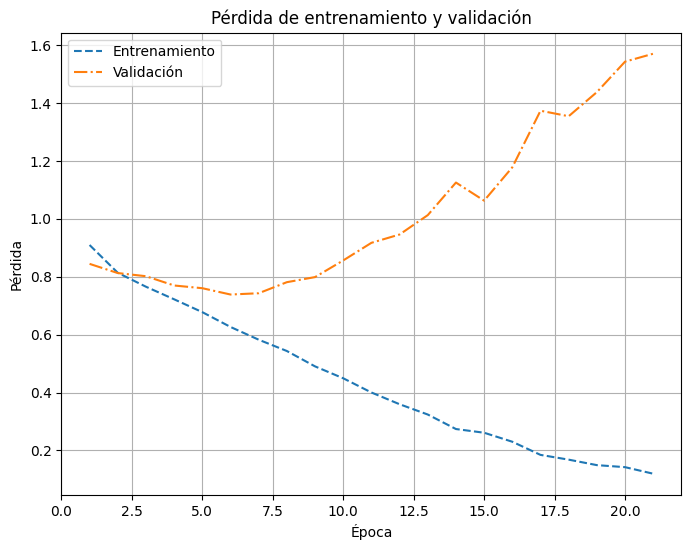

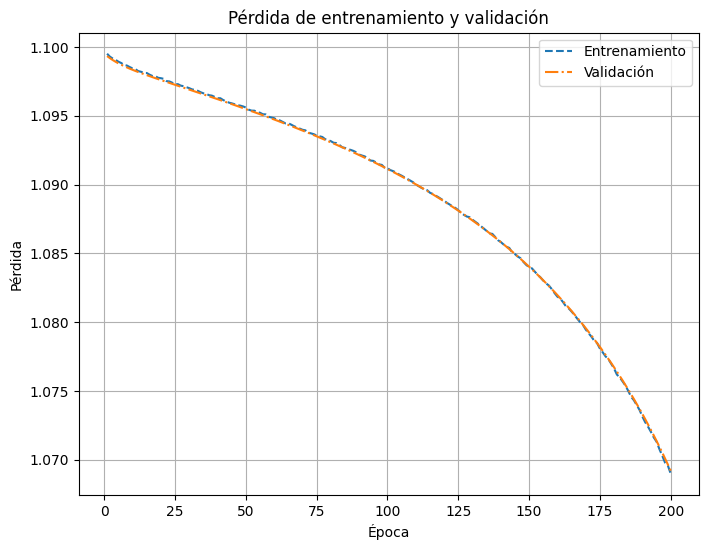

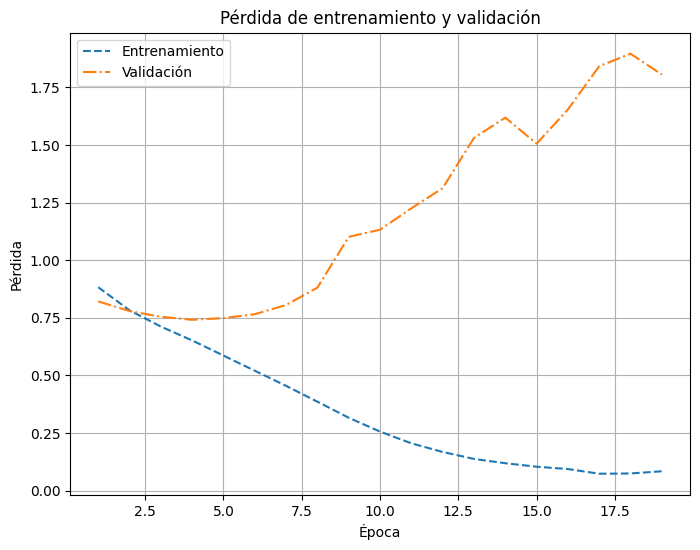

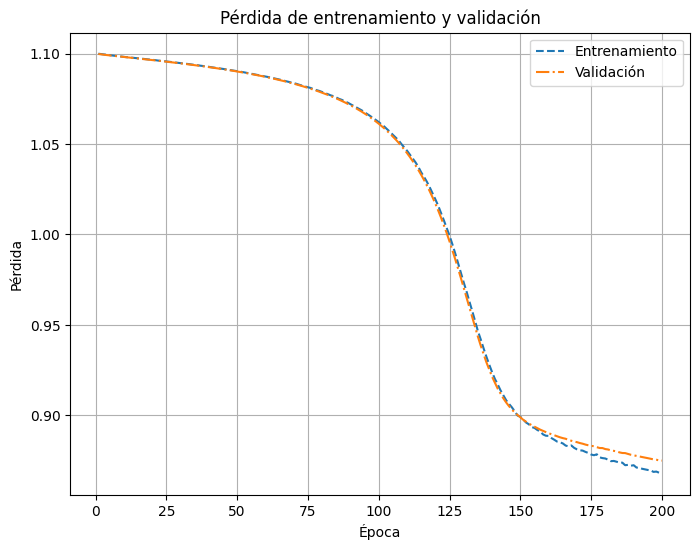

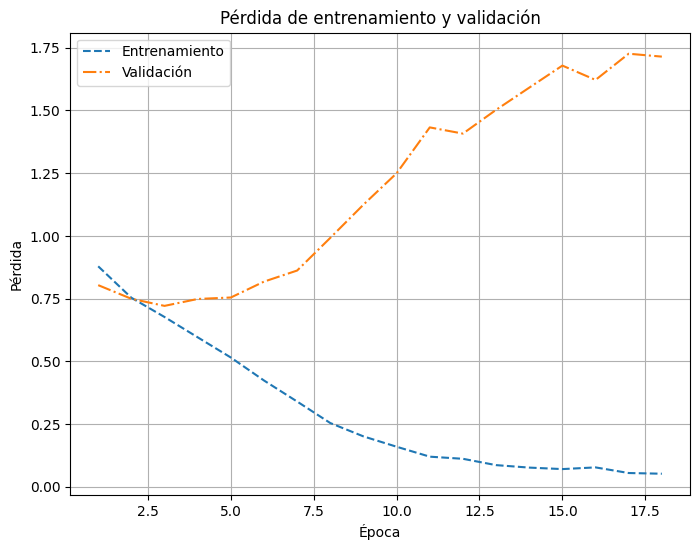

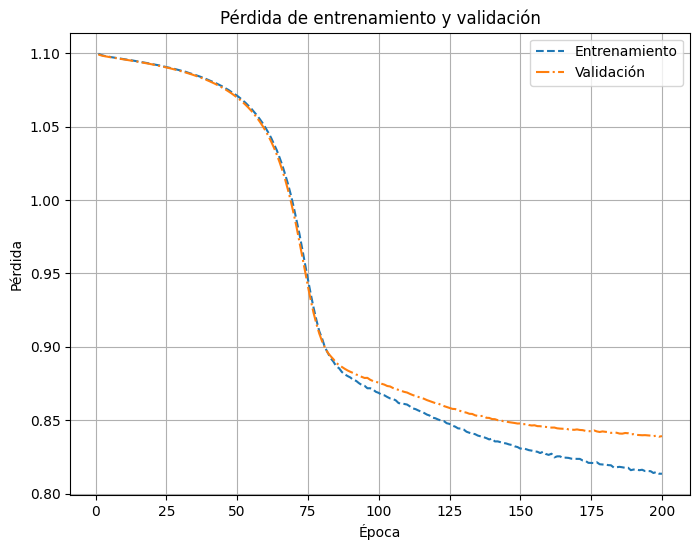

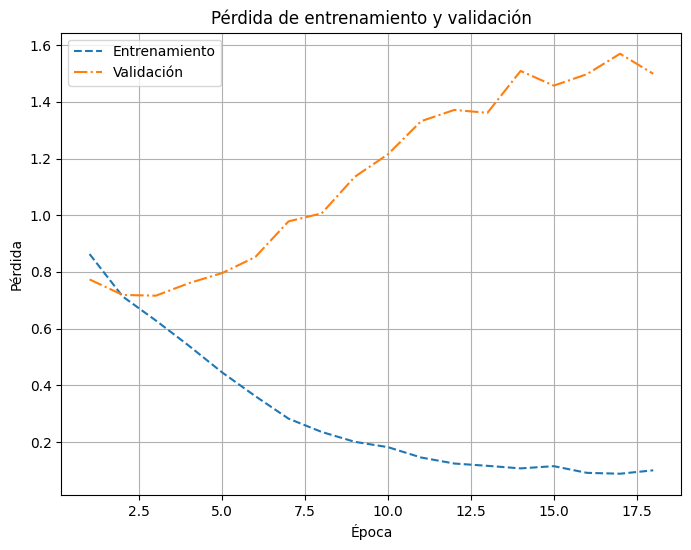

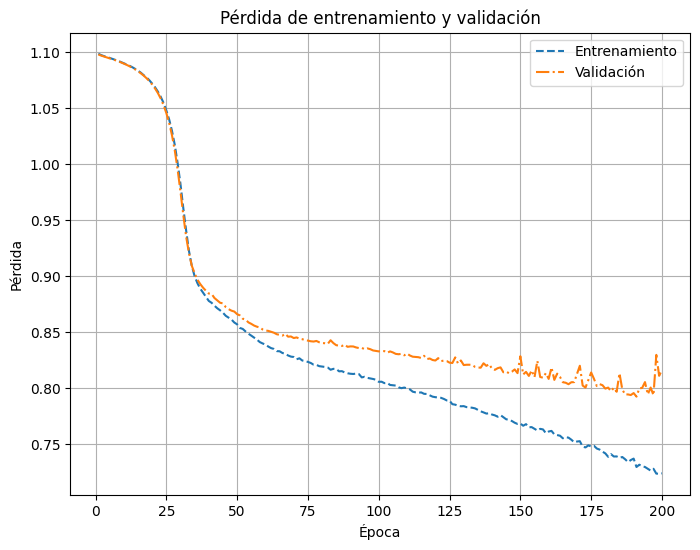

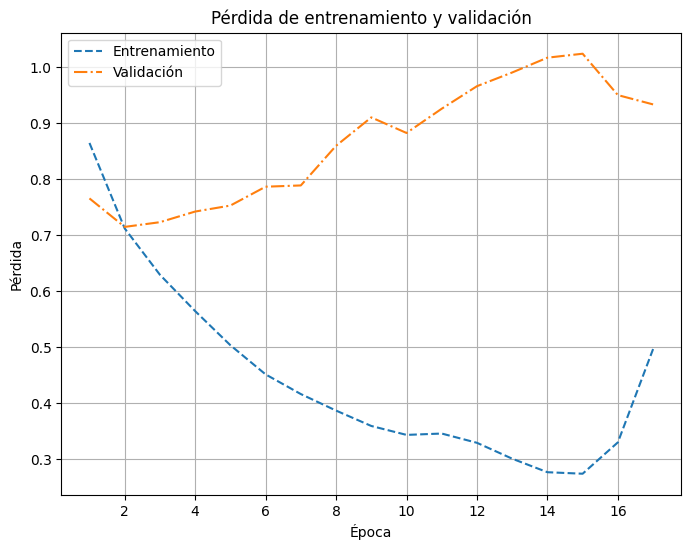

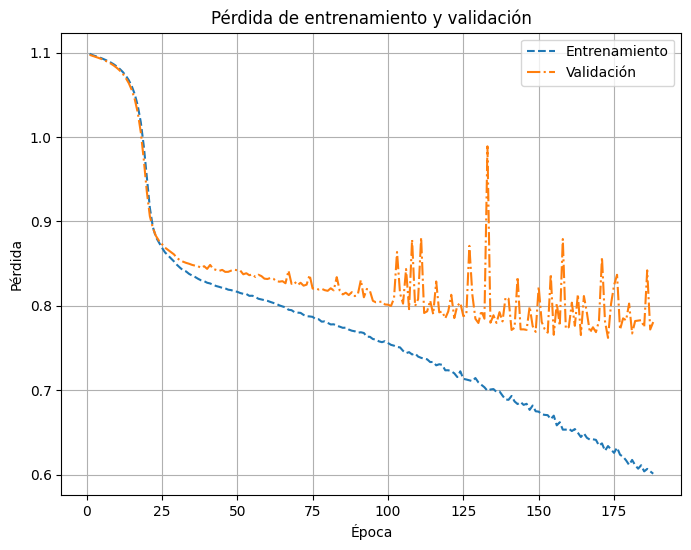

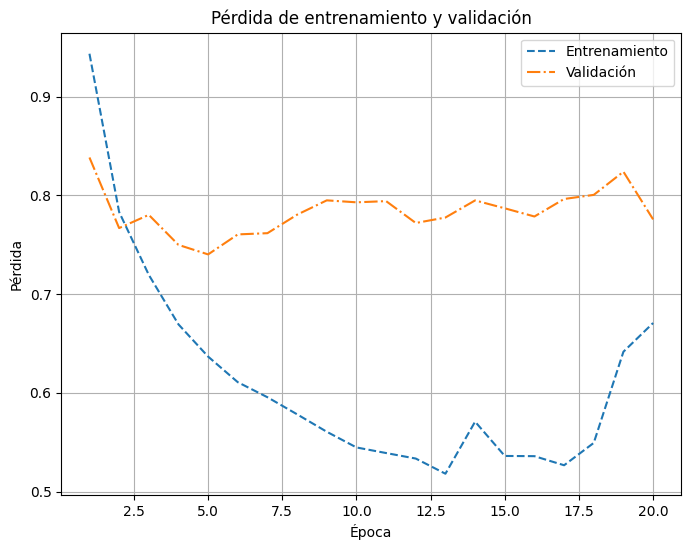

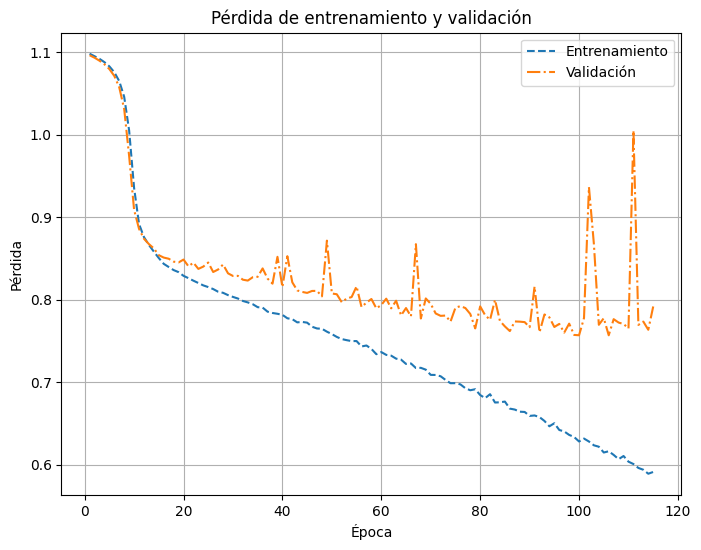

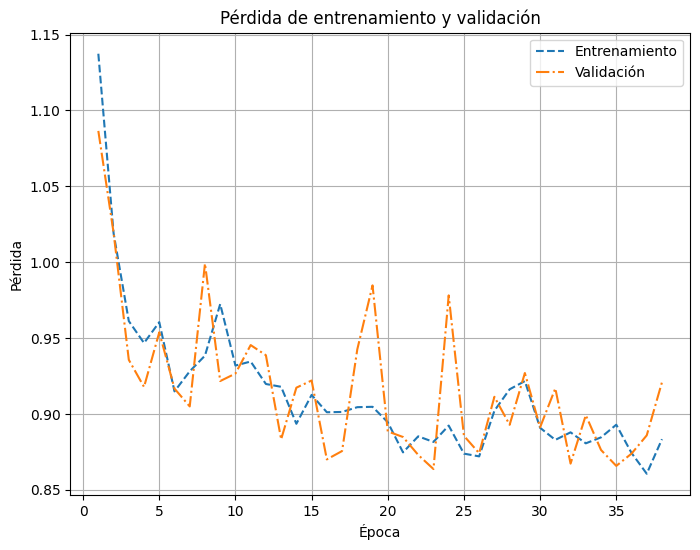

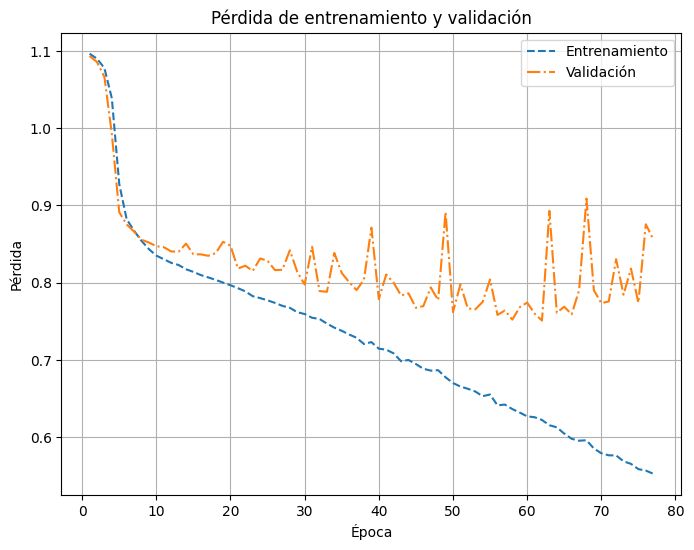

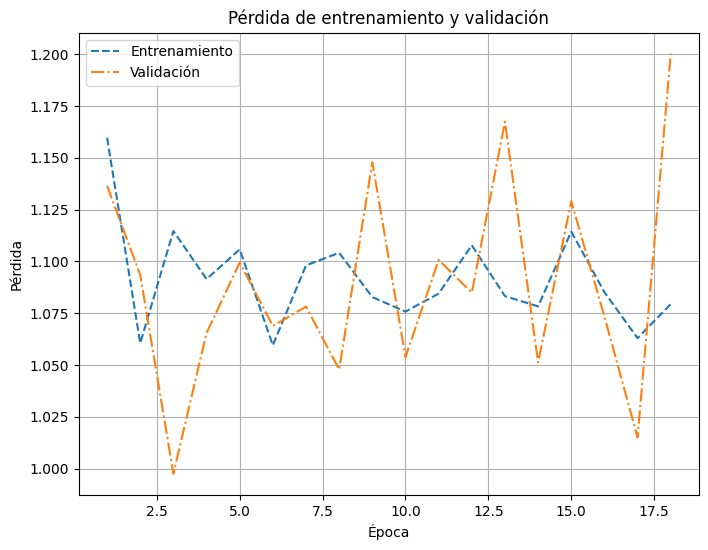

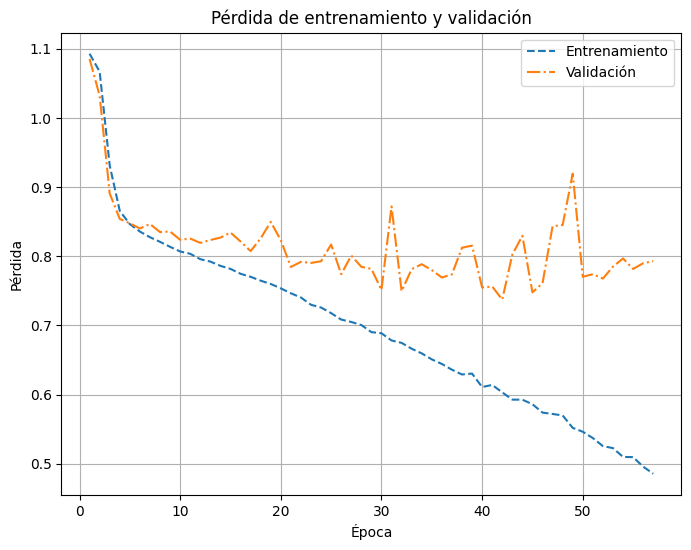

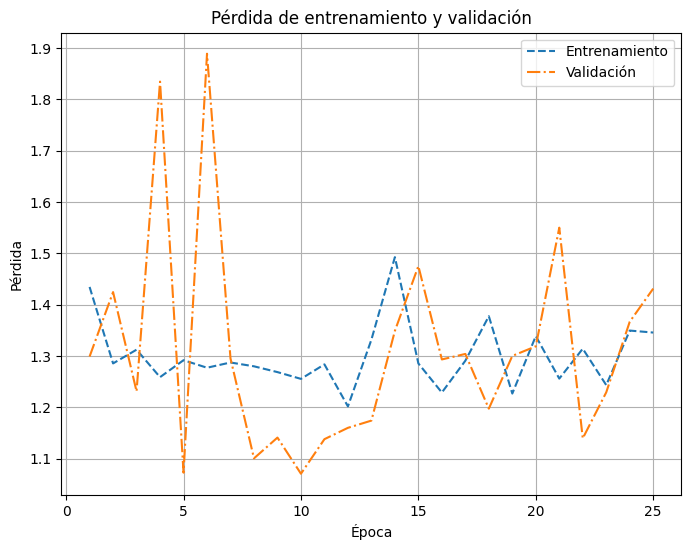

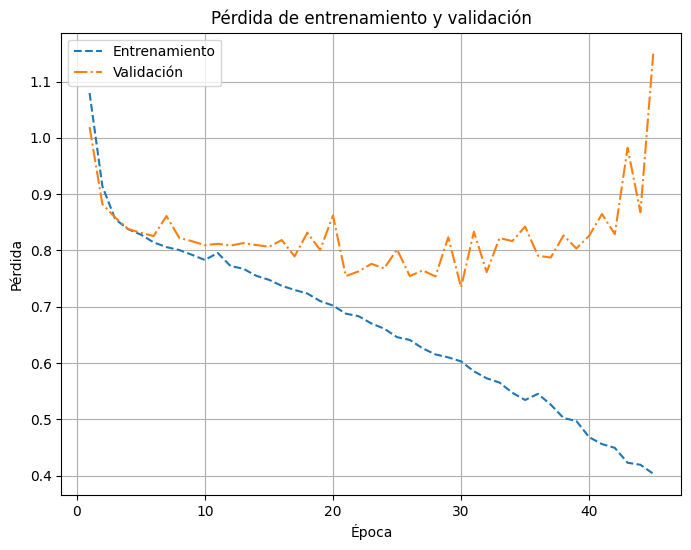

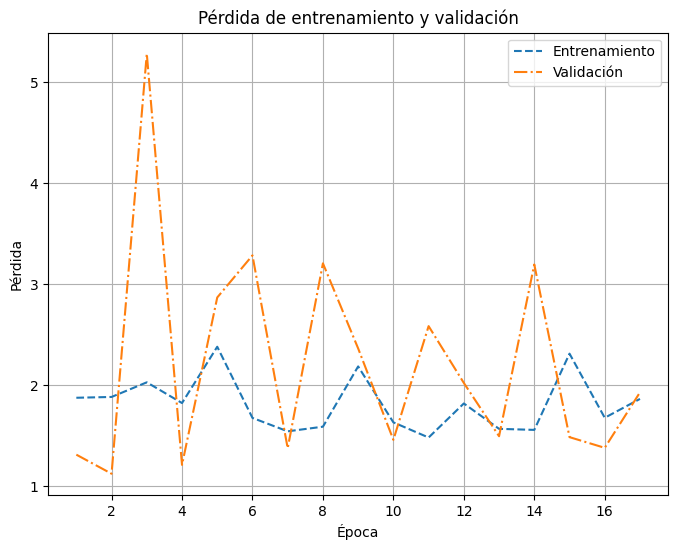

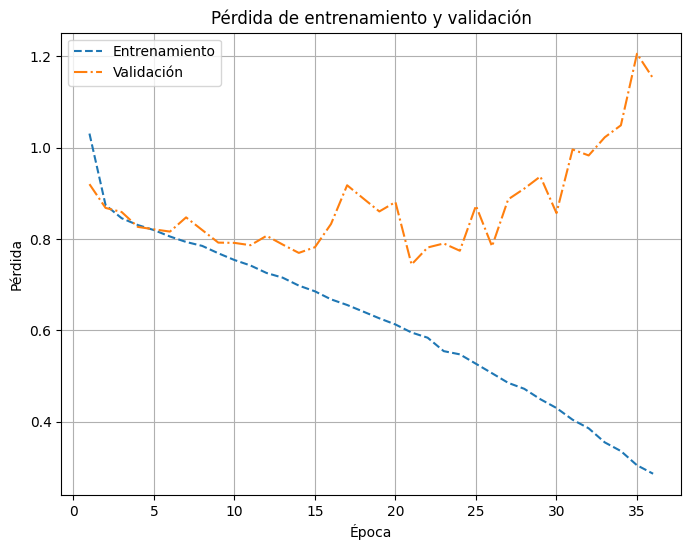

In [ ]:
from src.trainers.train_lstm import train_lstm
from src.trainers.utils import save_metrics, show_loss_val_curves, save_model_torch
from constants.constants_tiktok import LSTM_LOSS_CURVES_DIR, LSTM_MODEL_DIR, LSTM_METRICS_PATH, EMBEDDING_W2V_TIKTOK_SENTENCES_PATH

best_accuracy = -1
for idx, param in enumerate(combinaciones, 1):
    model, metrics, train_losses, val_losses = train_lstm(
        dataset_train=dataset_train_tokenized,
        dataset_val=dataset_val_tokenized,
        embeddings_path=EMBEDDING_W2V_TIKTOK_SENTENCES_PATH,
        model_args=model_args,
        early_stopping = EarlyStopping(patience, min_delta), # reinicio
        batch_size=hp['batch_size'],
        lr=param['lr'],
        epochs=epochs,
        optim=param['optim'],
    )

    metrics['name'] = f"model_{idx}"
    print(f"[{metrics['name']} Acc: {metrics['accuracy']:.4f}] {param}")
    save_metrics(metrics, LSTM_METRICS_PATH)

    model_args['input_size'] = metrics['embedding_dim']
    save_model_torch(model.get_model(), model_args, hp, os.path.join(LSTM_MODEL_DIR, f"{metrics['name']}.pt"))

    title = f"Pérdida de entrenamiento y validación"
    path = os.path.join(LSTM_LOSS_CURVES_DIR, f"{metrics['name']}.png")
    show_loss_val_curves(train_losses, val_losses, len(train_losses), title, path)

    if metrics['accuracy'] > best_accuracy:
        best_accuracy = metrics['accuracy']
        print(f"New best accuracy ({metrics['name']})\n")
        save_model_torch(model.get_model(), model_args, hp, os.path.join(LSTM_MODEL_DIR, "best_model.pt"))

In [ ]:
import pandas as pd

# Seleccionar los hiperparámetros que generan mayor accuracy
df_metrics = pd.read_csv(LSTM_METRICS_PATH)

best_acc = df_metrics.loc[df_metrics['accuracy'].idxmax()]
print(best_acc)

accuracy            0.67981
recall             0.679801
precision           0.68437
f1_score           0.681126
model                  LSTM
optim                   sgd
lr                 0.125893
patience                 15
min_delta            0.0001
num_layers                2
hidden_size             128
dropout                 0.2
epochs                  200
batch_size               64
embedding_dim           100
train_time       125.163693
name               model_16
Name: 15, dtype: object


In [ ]:
import torch
from src.trainers.train_lstm import LSTMModel
from src.trainers.trainer_rnn import evaluate_model

checkpoint = torch.load(os.path.join(LSTM_MODEL_DIR, "best_model.pt"))
config = checkpoint['config']
hp = checkpoint['hp']

model = LSTMModel(**config)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Inferencia (desactiva dropout)

metrics = evaluate_model(
    model,
    dataset_test_tokenized,
    "LSTM",
    EMBEDDING_W2V_TIKTOK_SENTENCES_PATH,
    hp['batch_size']
)
display(metrics)

# Twitter

## Cargar datos

In [5]:
from src.trainers.utils import build_datasets, set_seed
from constants.constants_twitter import TWITTER_DATASET_TRAIN_PATH

set_seed()

dataset_train, dataset_test, dataset_val = build_datasets(
    TWITTER_DATASET_TRAIN_PATH,
    test_size=0.3,
    val_size=0.5, # 0.5 de 0.3
    random_state=42,
    undersampling=True
)
print(dataset_train.shape)
print(dataset_test.shape)
print(dataset_val.shape)

(36924, 2)
(7912, 2)
(7913, 2)


## Tokenizar el texto

In [6]:
from src.preprocesamiento.nlp_spacy import Tokenizer

tokenizer = Tokenizer("en") # El dataset de tiktok se encuentra en inglés

dataset_train_tokenized = {}
dataset_val_tokenized = {}
dataset_test_tokenized = {}

dataset_train_tokenized['tokens'] = tokenizer.tokenize(dataset_train['text'], True)
dataset_val_tokenized['tokens'] = tokenizer.tokenize(dataset_val['text'], True)
dataset_test_tokenized['tokens'] = tokenizer.tokenize(dataset_test['text'], True)

dataset_train_tokenized['polarity'] = dataset_train['polarity'].to_numpy()
dataset_val_tokenized['polarity'] = dataset_val['polarity'].to_numpy()
dataset_test_tokenized['polarity'] = dataset_test['polarity'].to_numpy()

Modelo cargado: en_core_web_sm


100%|██████████| 7912/7912 [00:10<00:00, 743.86it/s]


## MLP

In [ ]:
import numpy as np
from sklearn.model_selection import ParameterGrid
from src.trainers.utils import EarlyStopping

param_grid = {
    "pooling": ["aver", "max"],
    "optim": ["adam", "sgd"],
    "lr": np.logspace(-3, -0.3, 10)
}

combinaciones = list(ParameterGrid(param_grid))
for idx, comb in enumerate(combinaciones, 1):
    print(f"Model {idx}: {comb}")

epochs = 200
patience = 15
min_delta = 1e-4
hp = {}
hp['batch_size'] = 64

model_args = {}
model_args['hidden_layers'] = [128, 64]
model_args['output_size'] = 3
model_args['dropout'] = 0.20

Model 1: {'lr': 0.001, 'optim': 'adam', 'pooling': 'aver'}
Model 2: {'lr': 0.001, 'optim': 'adam', 'pooling': 'max'}
Model 3: {'lr': 0.001, 'optim': 'sgd', 'pooling': 'aver'}
Model 4: {'lr': 0.001, 'optim': 'sgd', 'pooling': 'max'}
Model 5: {'lr': 0.001995262314968879, 'optim': 'adam', 'pooling': 'aver'}
Model 6: {'lr': 0.001995262314968879, 'optim': 'adam', 'pooling': 'max'}
Model 7: {'lr': 0.001995262314968879, 'optim': 'sgd', 'pooling': 'aver'}
Model 8: {'lr': 0.001995262314968879, 'optim': 'sgd', 'pooling': 'max'}
Model 9: {'lr': 0.003981071705534973, 'optim': 'adam', 'pooling': 'aver'}
Model 10: {'lr': 0.003981071705534973, 'optim': 'adam', 'pooling': 'max'}
Model 11: {'lr': 0.003981071705534973, 'optim': 'sgd', 'pooling': 'aver'}
Model 12: {'lr': 0.003981071705534973, 'optim': 'sgd', 'pooling': 'max'}
Model 13: {'lr': 0.00794328234724282, 'optim': 'adam', 'pooling': 'aver'}
Model 14: {'lr': 0.00794328234724282, 'optim': 'adam', 'pooling': 'max'}
Model 15: {'lr': 0.007943282347242

Device: cuda


 53%|█████▎    | 106/200 [02:06<01:51,  1.19s/it, train_loss=0.314, val_loss=0.44]


[model_1 Acc: 0.8418] {'lr': 0.001, 'optim': 'adam', 'pooling': 'aver'}
New best accuracy (model_1)

Device: cuda


 55%|█████▍    | 109/200 [02:10<01:48,  1.20s/it, train_loss=0.437, val_loss=0.644]


[model_2 Acc: 0.7600] {'lr': 0.001, 'optim': 'adam', 'pooling': 'max'}
Device: cuda


...

[model_38 Acc: 0.3334] {'lr': 0.5011872336272722, 'optim': 'adam', 'pooling': 'max'}
Device: cuda


 28%|██▊       | 57/200 [01:03<02:39,  1.12s/it, train_loss=0.363, val_loss=0.469]


[model_39 Acc: 0.8279] {'lr': 0.5011872336272722, 'optim': 'sgd', 'pooling': 'aver'}
Device: cuda


 43%|████▎     | 86/200 [01:32<02:03,  1.08s/it, train_loss=0.492, val_loss=0.657]


[model_40 Acc: 0.7382] {'lr': 0.5011872336272722, 'optim': 'sgd', 'pooling': 'max'}


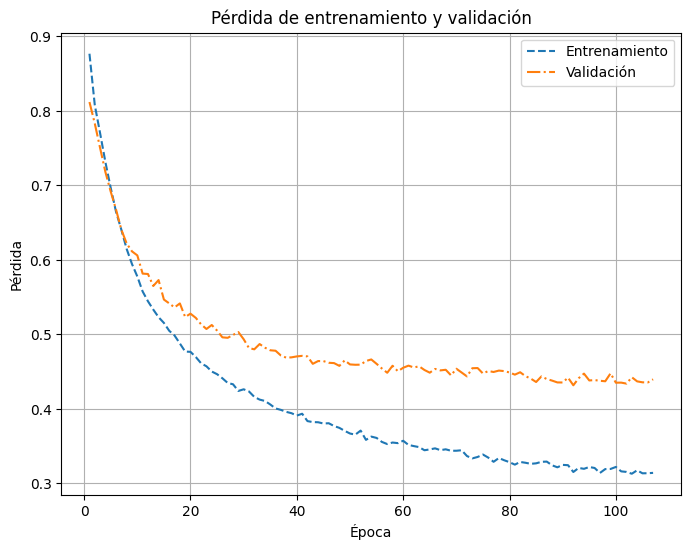

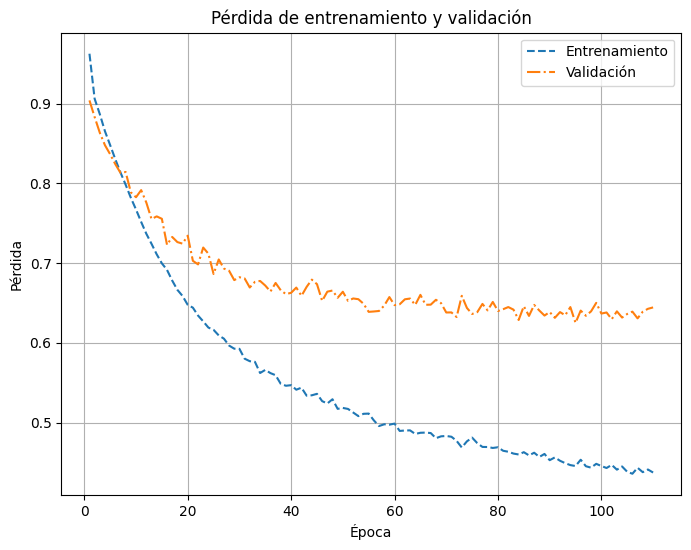

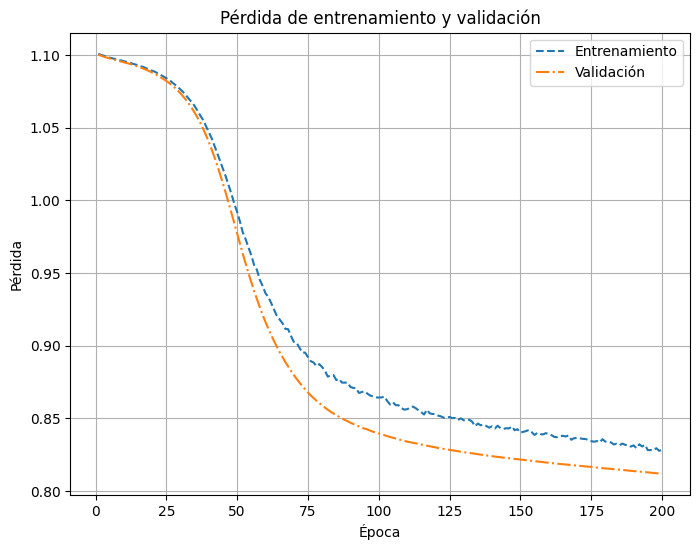

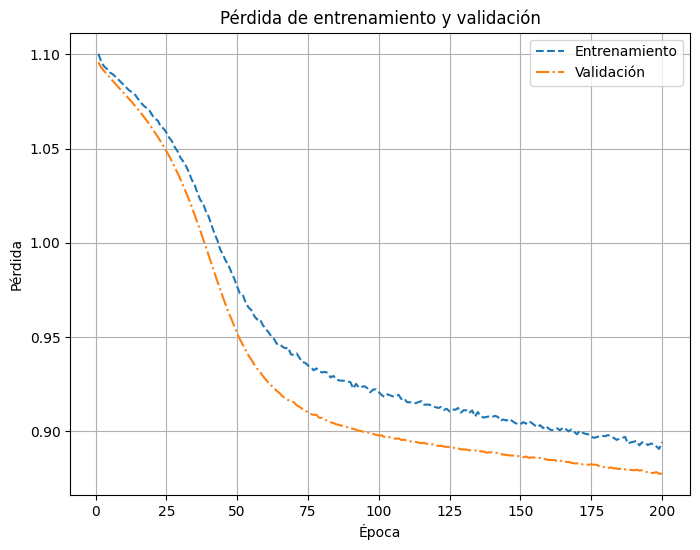

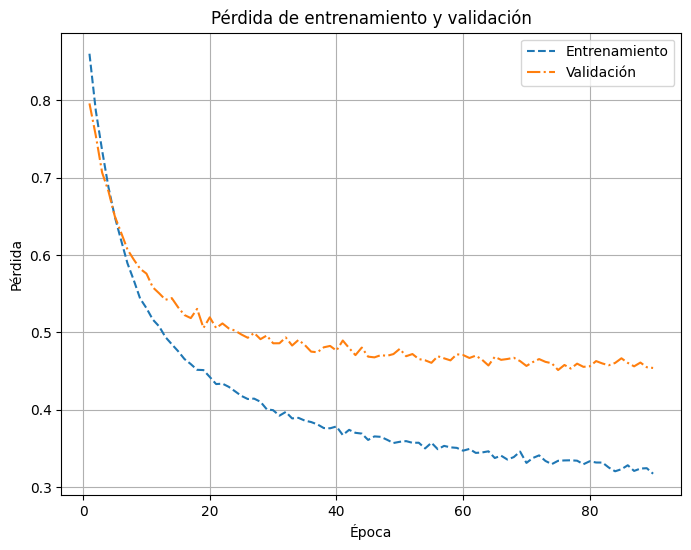

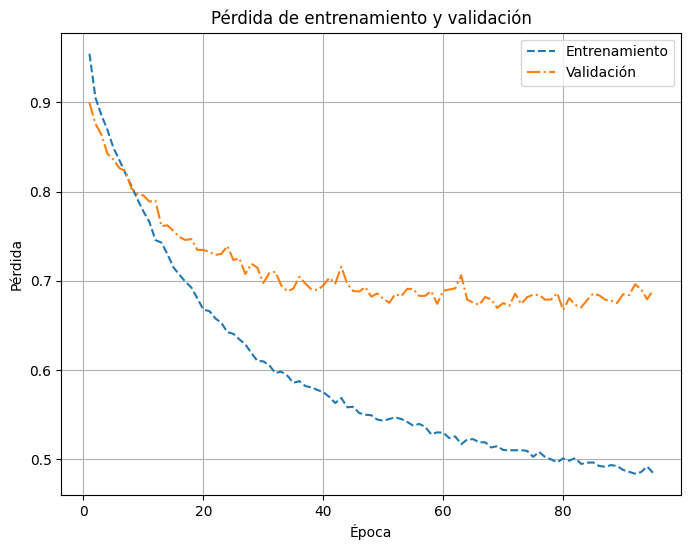

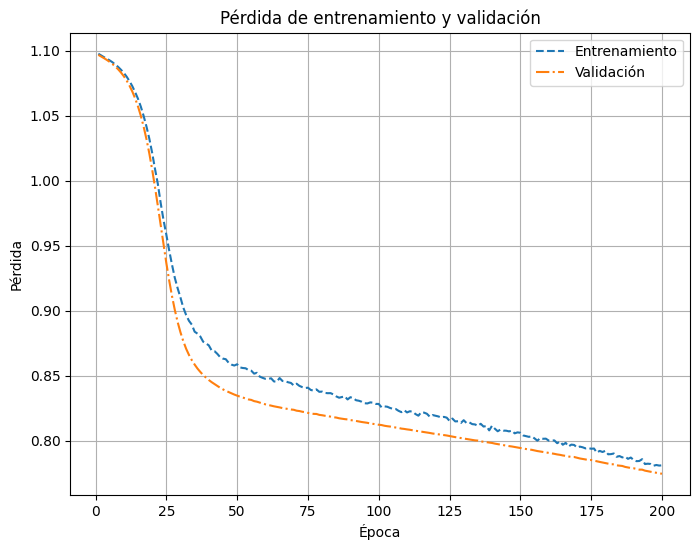

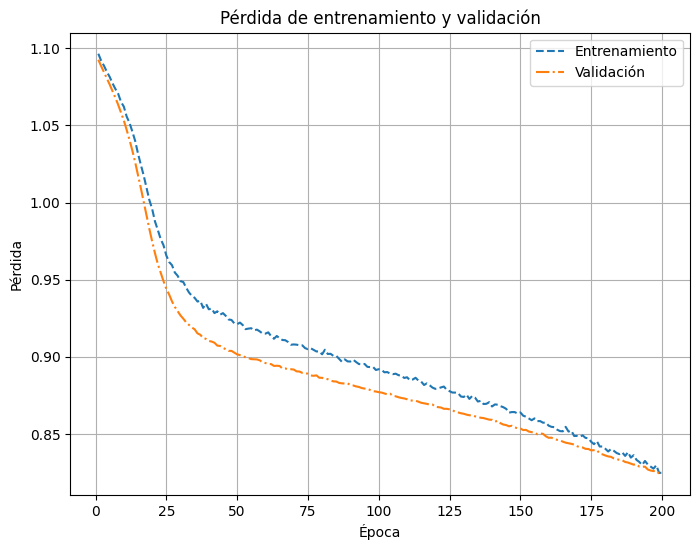

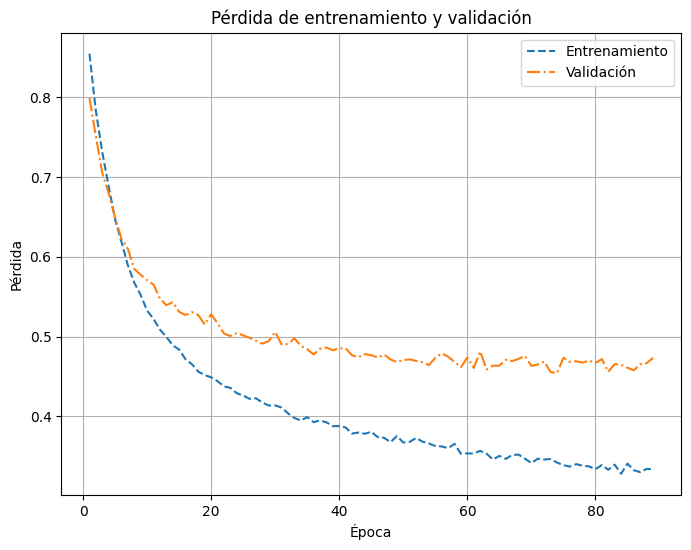

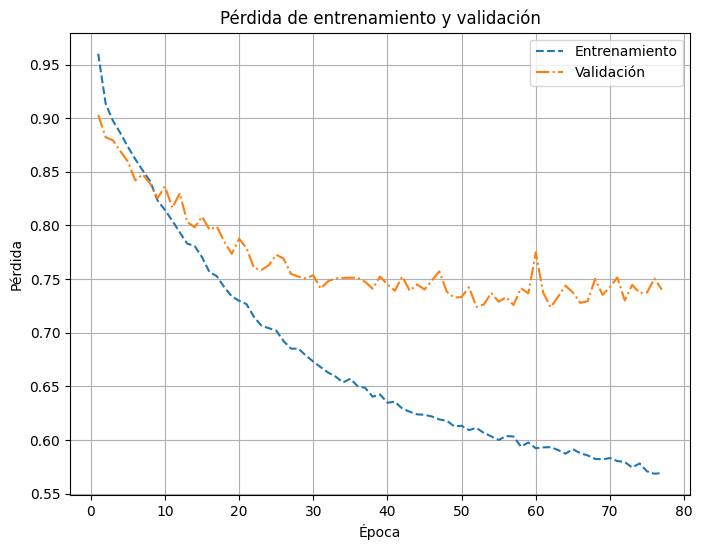

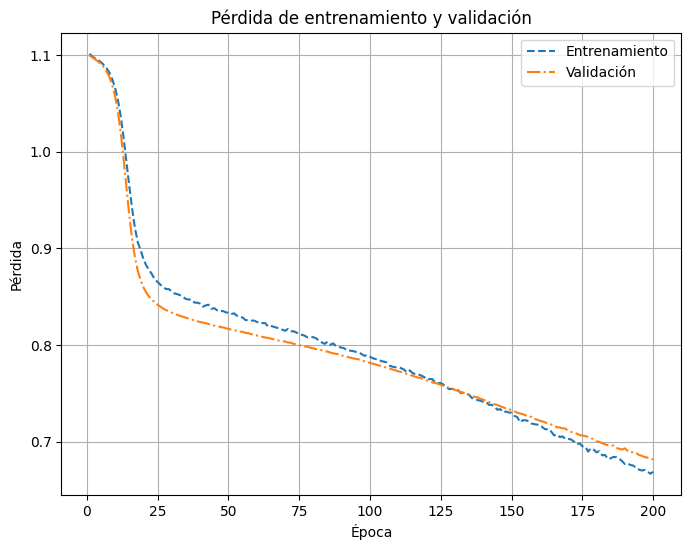

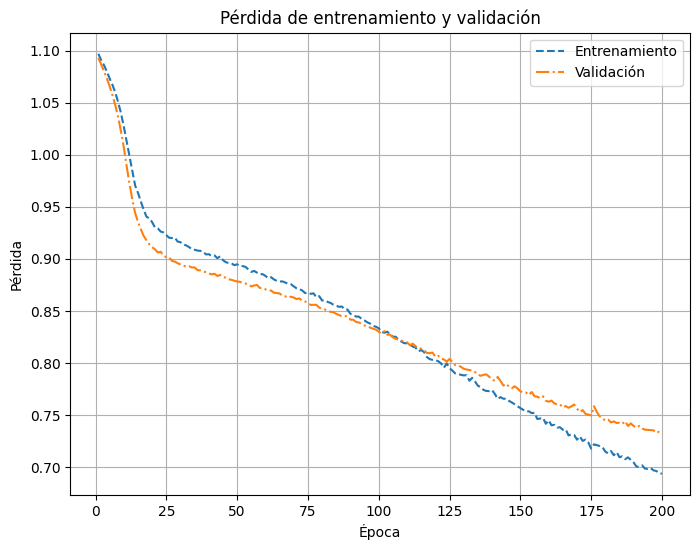

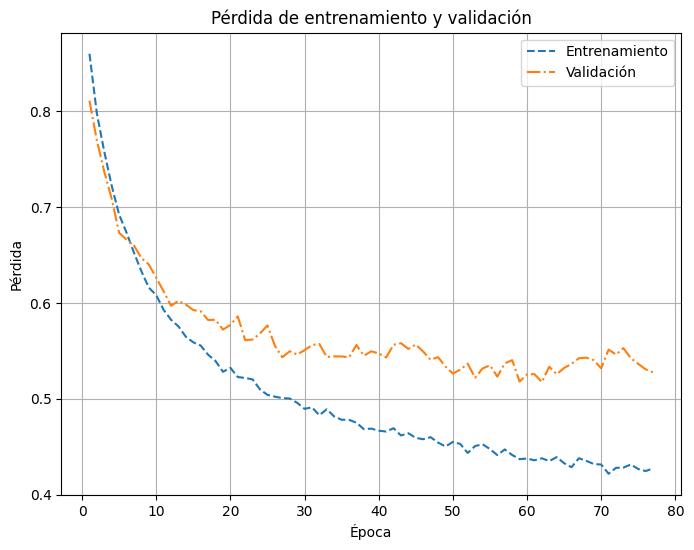

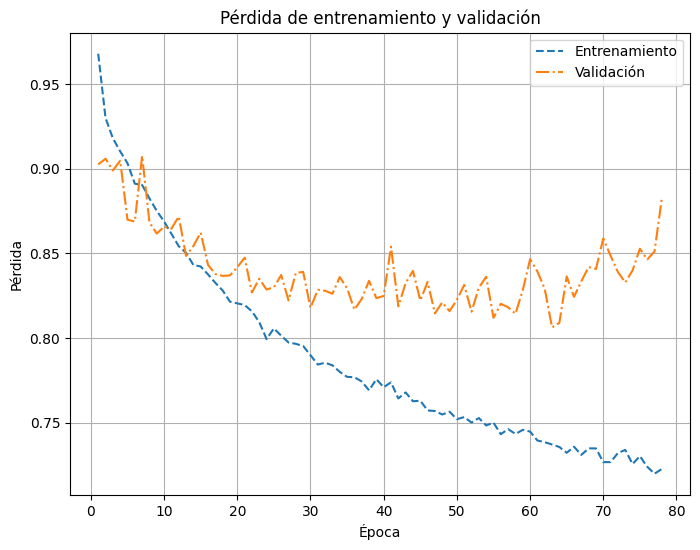

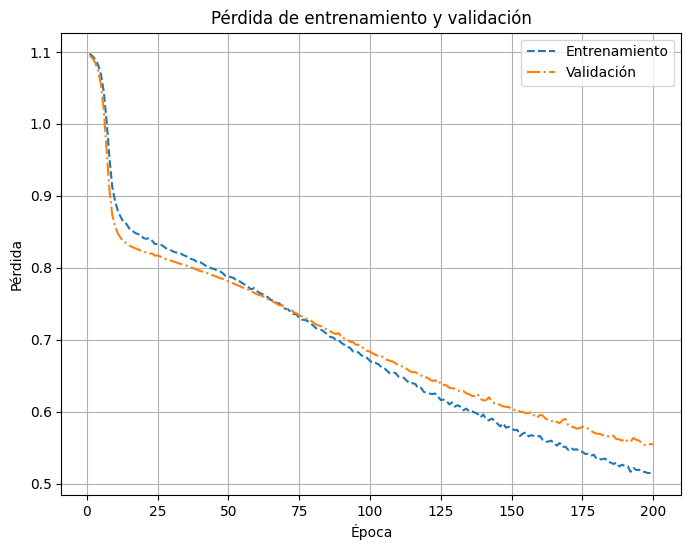

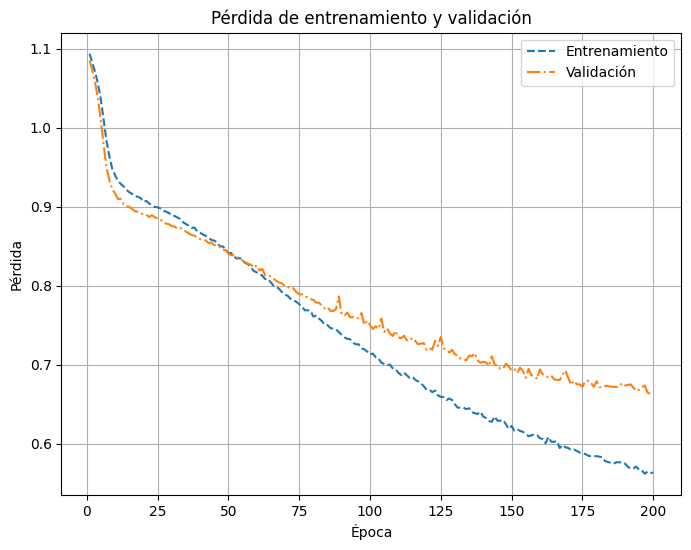

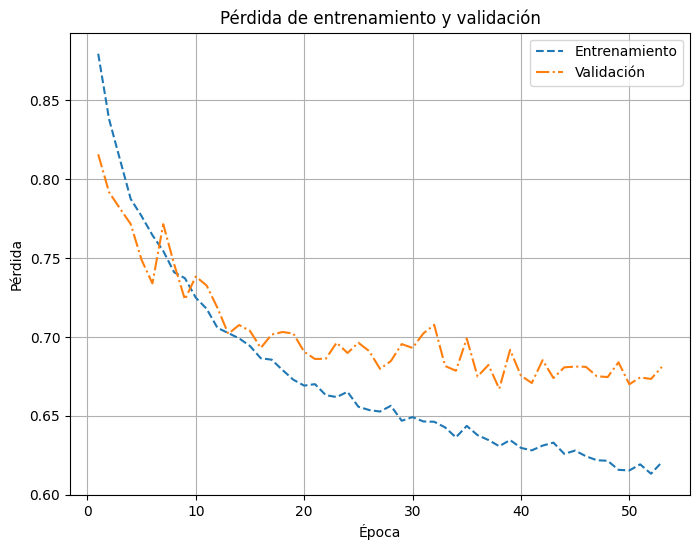

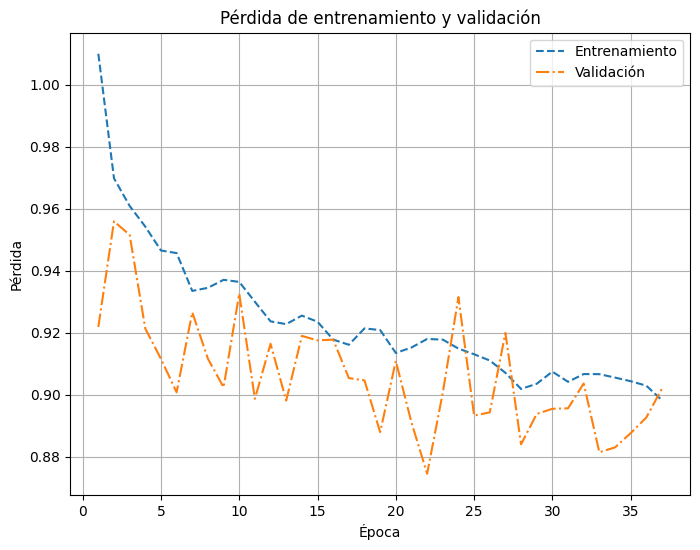

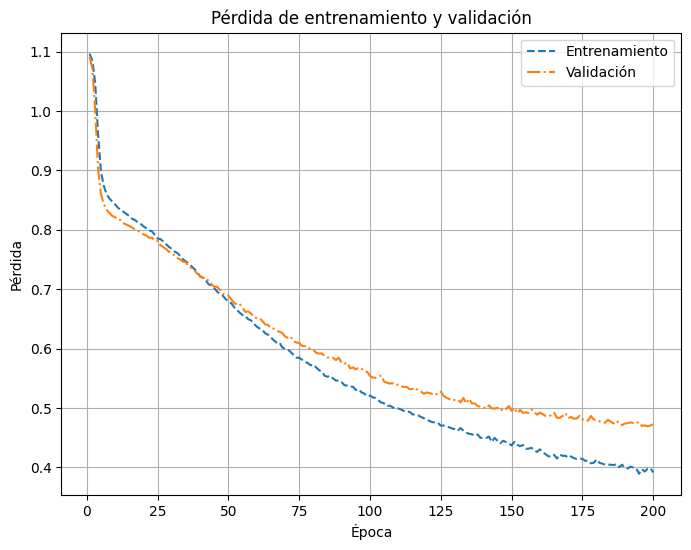

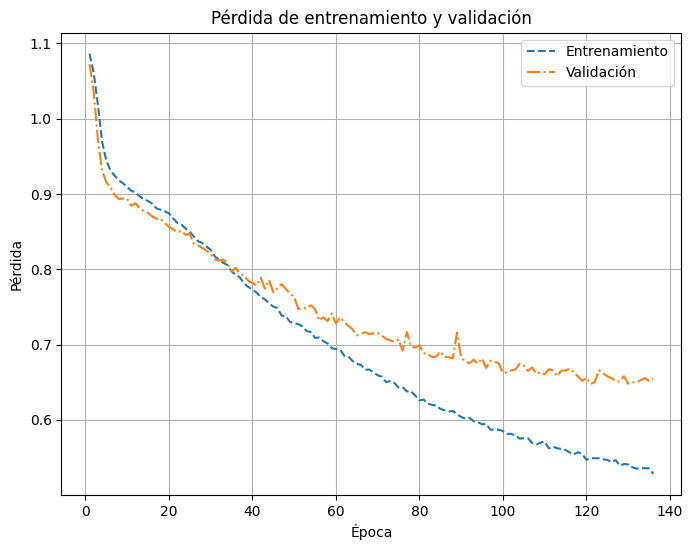

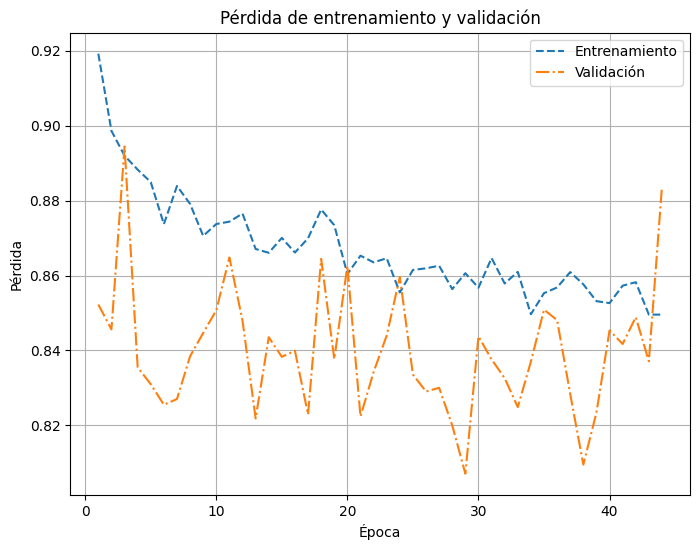

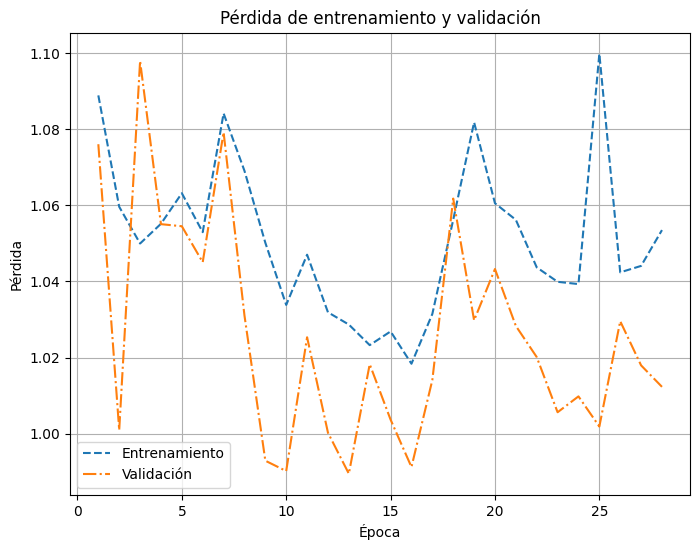

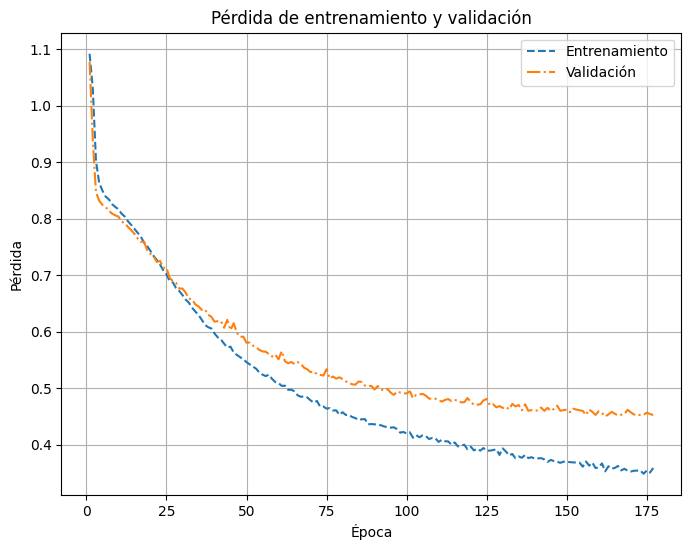

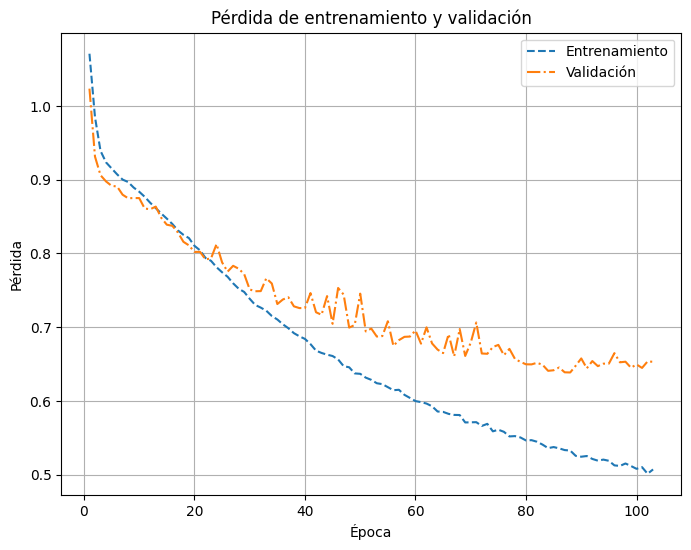

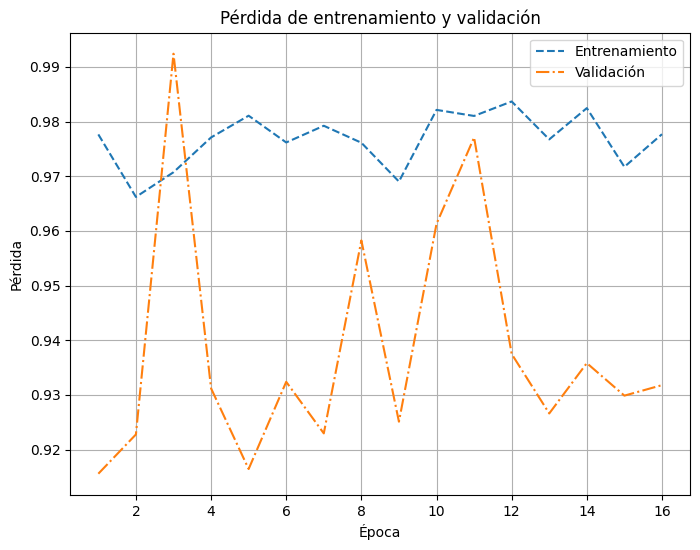

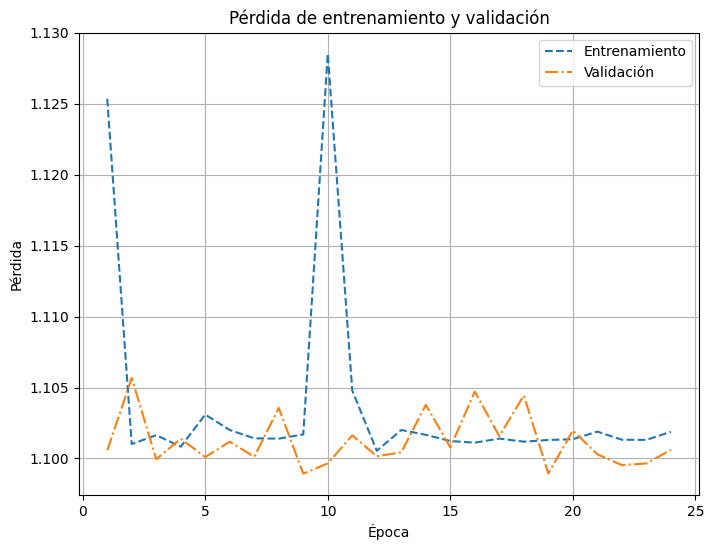

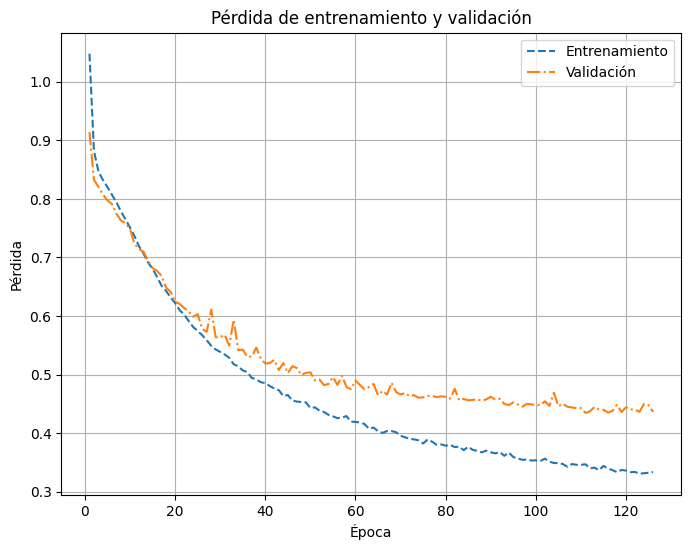

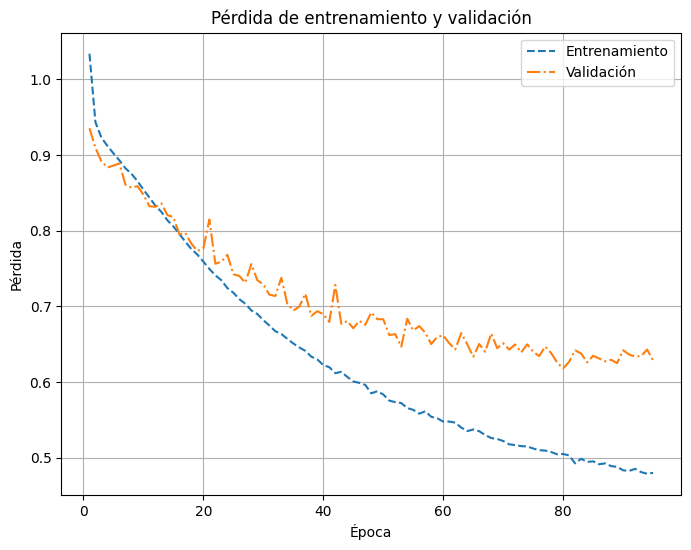

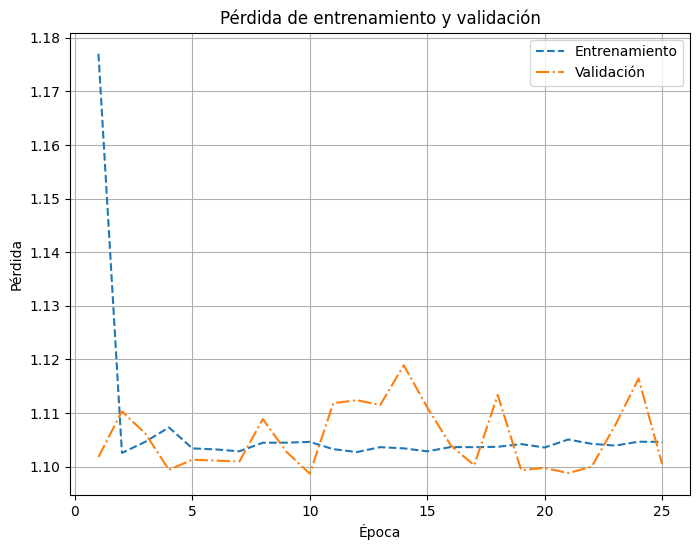

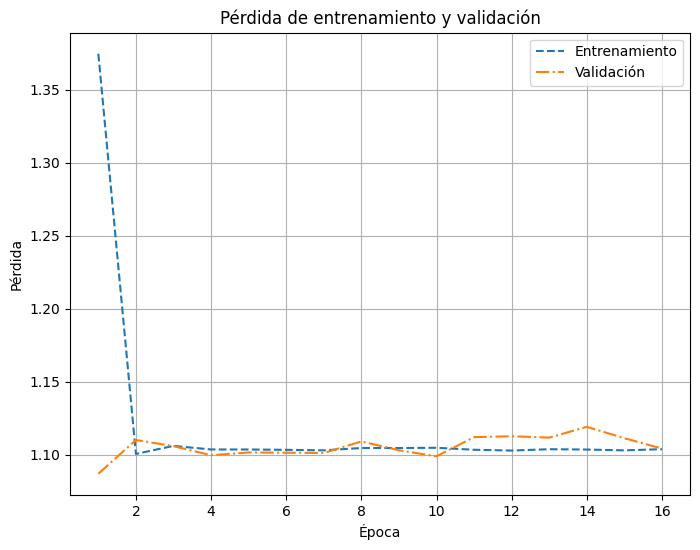

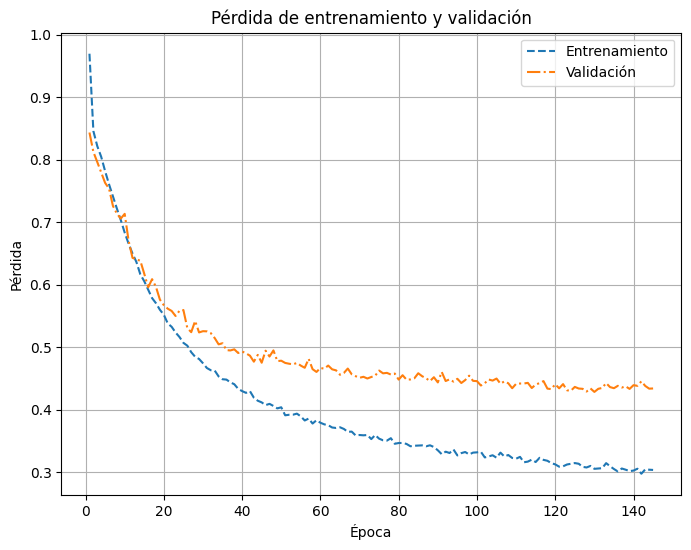

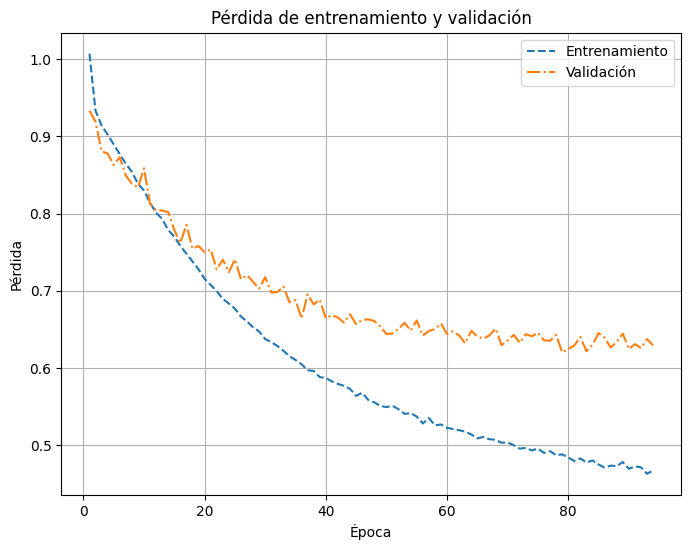

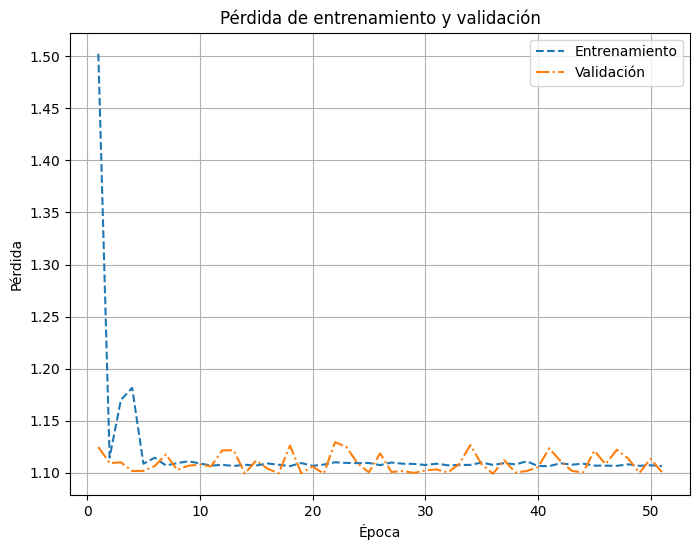

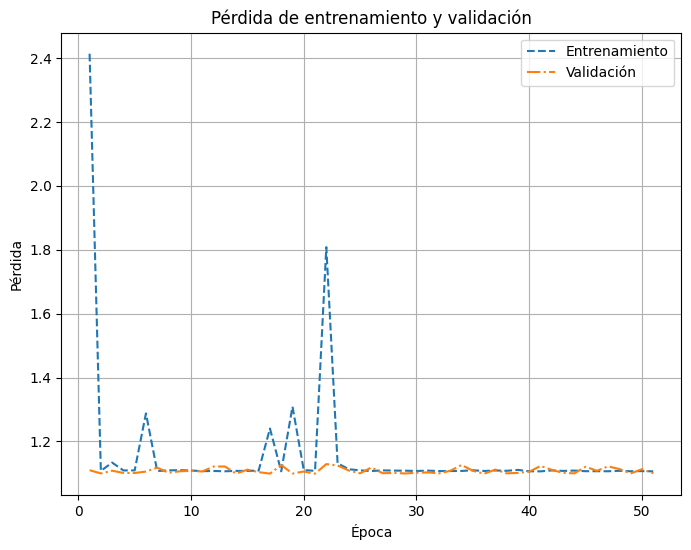

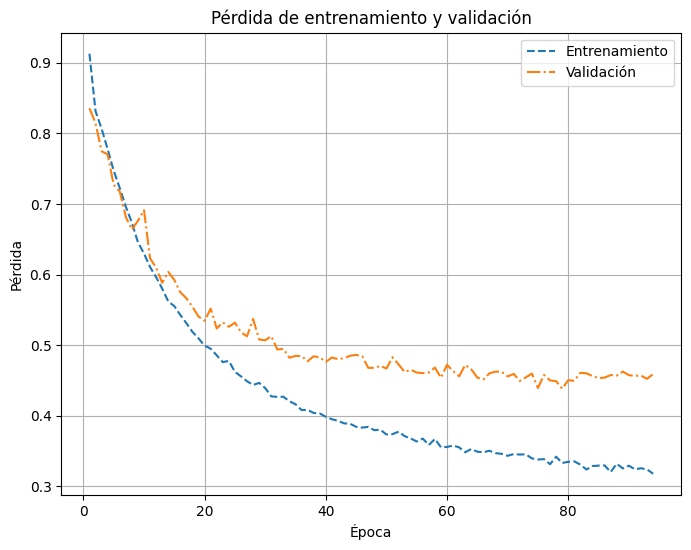

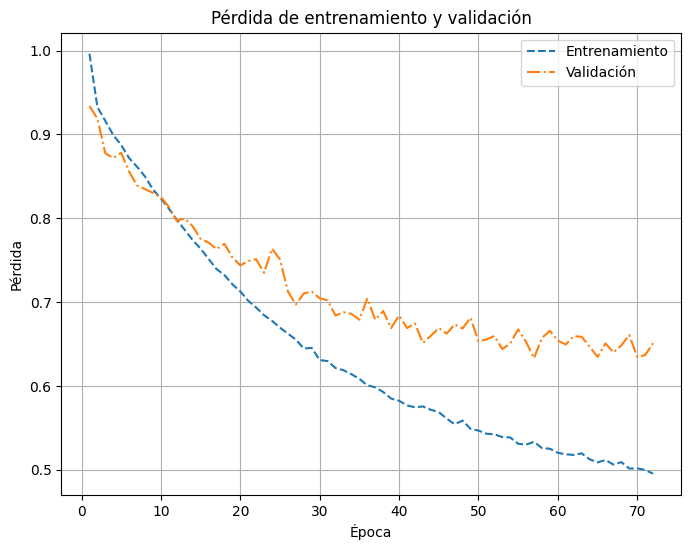

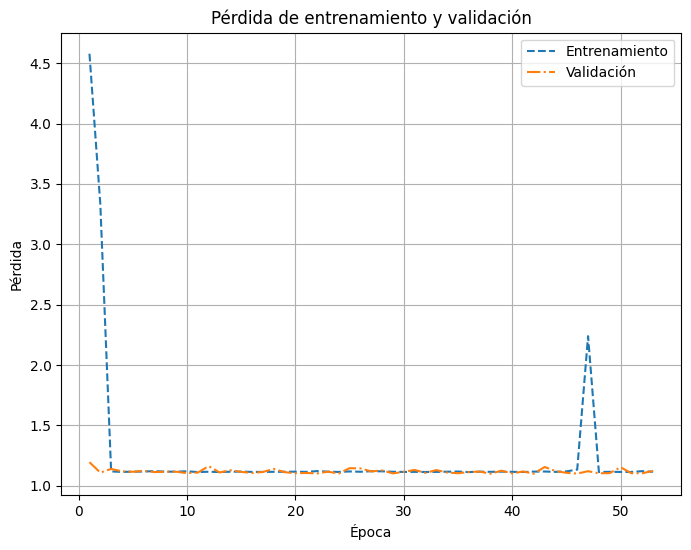

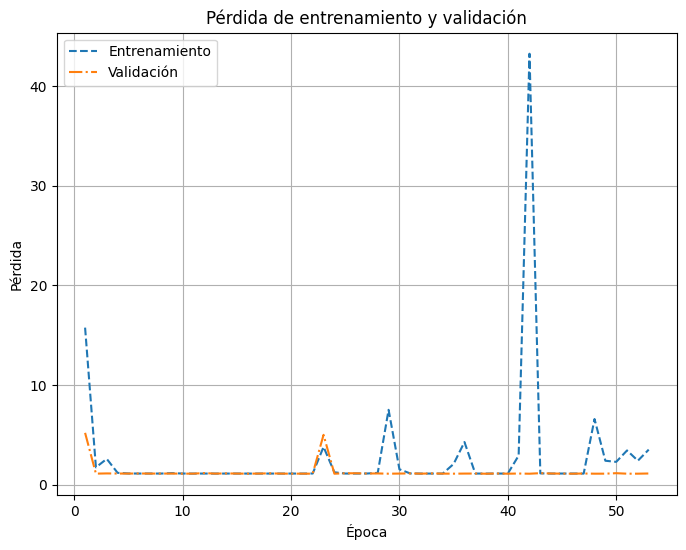

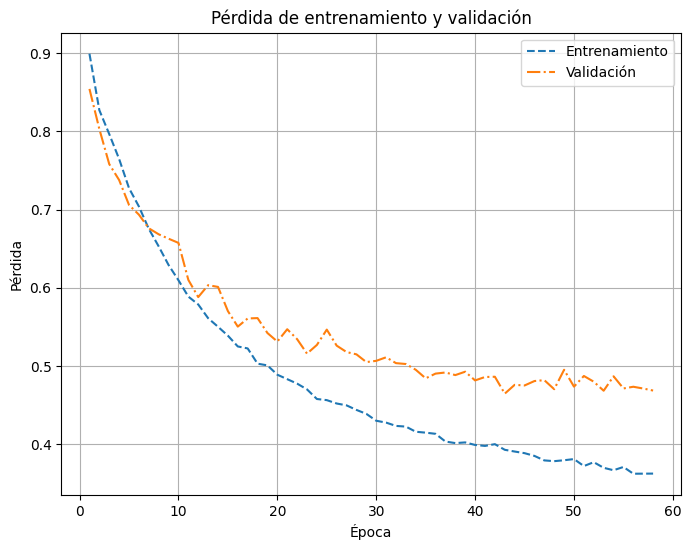

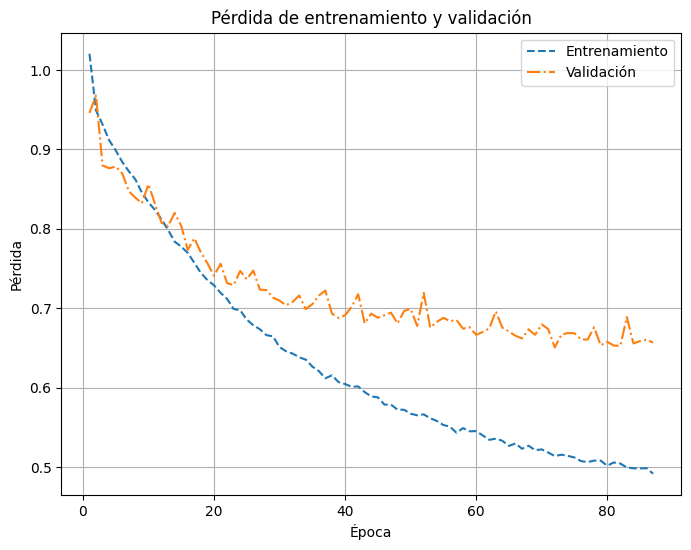

In [ ]:
from src.trainers.train_mlp import train_mlp
from src.trainers.utils import save_metrics, show_loss_val_curves, save_model_torch
from constants.constants_twitter import MLP_LOSS_CURVES_DIR, MLP_MODEL_DIR, MLP_METRICS_PATH, EMBEDDING_W2V_TWITTER_PATH

best_accuracy = -1
for idx, param in enumerate(combinaciones, 1):
	model, metrics, train_losses, val_losses = train_mlp(
		dataset_train=dataset_train_tokenized,
    	dataset_val=dataset_val_tokenized,
    	embeddings_path=EMBEDDING_W2V_TWITTER_PATH,
    	model_args=model_args,
    	early_stopping = EarlyStopping(patience, min_delta),
    	batch_size=hp['batch_size'],
    	lr=param['lr'],
    	epochs=epochs,
    	optim=param['optim'],
    	pooling=param['pooling']
  	)

	metrics['name'] = f"model_{idx}"
	print(f"[{metrics['name']} Acc: {metrics['accuracy']:.4f}] {param}")
	save_metrics(metrics, MLP_METRICS_PATH)

	hp['pooling'] = param['pooling']
	model_args['input_size'] = metrics['embedding_dim']
	save_model_torch(model.get_model(), model_args, hp, os.path.join(MLP_MODEL_DIR, f"{metrics['name']}.pt"))

	title = f"Pérdida de entrenamiento y validación"
	path = os.path.join(MLP_LOSS_CURVES_DIR, f"{metrics['name']}.png")
	show_loss_val_curves(train_losses, val_losses, len(train_losses), title, path)

	if metrics['accuracy'] > best_accuracy:
		best_accuracy = metrics['accuracy']
		print(f"New best accuracy ({metrics['name']})\n")
		save_model_torch(model.get_model(), model_args, hp, os.path.join(MLP_MODEL_DIR, "best_model.pt"))

In [ ]:
import pandas as pd

# Seleccionar los hiperparámetros que generan mayor accuracy
df_metrics = pd.read_csv(MLP_METRICS_PATH)

best_acc = df_metrics.loc[df_metrics['accuracy'].idxmax()]
print(best_acc)

accuracy           0.842917
recall             0.842915
precision          0.843424
f1_score           0.842943
model              MLP SWEM
pooling                aver
optim                   sgd
lr                 0.125893
patience                 15
min_delta            0.0001
hidden_layers     [128, 64]
output_size               3
dropout                 0.2
epochs              145/200
batch_size               64
embedding_dim           100
train_time       145.768165
name               model_31
Name: 30, dtype: object


In [ ]:
import torch
from src.trainers.train_mlp import evaluate_model, MLPModelCustom

checkpoint = torch.load(os.path.join(MLP_MODEL_DIR, "best_model.pt"))
config = checkpoint['config']
hp = checkpoint['hp']

model = MLPModelCustom(**config)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Inferencia (desactiva dropout)

metrics = evaluate_model(
    model,
    dataset_test_tokenized,
    "MLP",
    EMBEDDING_W2V_TWITTER_PATH,
    hp['pooling'], hp['batch_size']
)
display(metrics)

## RNN

In [7]:
import numpy as np
from sklearn.model_selection import ParameterGrid
from src.trainers.utils import EarlyStopping

param_grid = {
  "optim": ["adam", "sgd"],
  "lr": np.logspace(-3, -0.3, 10)
}

combinaciones = list(ParameterGrid(param_grid))
for idx, comb in enumerate(combinaciones, 1):
    print(f"Model {idx}: {comb}")

epochs = 200
patience = 15
min_delta = 1e-4
hp = {}
hp['batch_size'] = 64

model_args = {}
model_args['hidden_size'] = 128
model_args['num_layers'] = 2
model_args['output_size'] = 3
model_args['dropout'] = 0.20

Model 1: {'lr': 0.001, 'optim': 'adam'}
Model 2: {'lr': 0.001, 'optim': 'sgd'}
Model 3: {'lr': 0.001995262314968879, 'optim': 'adam'}
Model 4: {'lr': 0.001995262314968879, 'optim': 'sgd'}
Model 5: {'lr': 0.003981071705534973, 'optim': 'adam'}
Model 6: {'lr': 0.003981071705534973, 'optim': 'sgd'}
Model 7: {'lr': 0.00794328234724282, 'optim': 'adam'}
Model 8: {'lr': 0.00794328234724282, 'optim': 'sgd'}
Model 9: {'lr': 0.01584893192461114, 'optim': 'adam'}
Model 10: {'lr': 0.01584893192461114, 'optim': 'sgd'}
Model 11: {'lr': 0.03162277660168381, 'optim': 'adam'}
Model 12: {'lr': 0.03162277660168381, 'optim': 'sgd'}
Model 13: {'lr': 0.06309573444801936, 'optim': 'adam'}
Model 14: {'lr': 0.06309573444801936, 'optim': 'sgd'}
Model 15: {'lr': 0.12589254117941687, 'optim': 'adam'}
Model 16: {'lr': 0.12589254117941687, 'optim': 'sgd'}
Model 17: {'lr': 0.25118864315095824, 'optim': 'adam'}
Model 18: {'lr': 0.25118864315095824, 'optim': 'sgd'}
Model 19: {'lr': 0.5011872336272722, 'optim': 'adam'

Device: cuda


 17%|█▋        | 34/200 [02:29<12:09,  4.39s/it, train_loss=0.27, val_loss=0.814]


[model_1 Acc: 0.7542] {'lr': 0.001, 'optim': 'adam'}
New best accuracy (model_1)

Device: cuda


100%|██████████| 200/200 [13:07<00:00,  3.94s/it, train_loss=0.756, val_loss=0.782]


[model_2 Acc: 0.6642] {'lr': 0.001, 'optim': 'sgd'}
Device: cuda


...

[model_18 Acc: 0.4333] {'lr': 0.25118864315095824, 'optim': 'sgd'}
Device: cuda


 12%|█▎        | 25/200 [01:56<13:35,  4.66s/it, train_loss=10.4, val_loss=7.75]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[model_19 Acc: 0.3469] {'lr': 0.5011872336272722, 'optim': 'adam'}
Device: cuda


  8%|▊         | 15/200 [01:16<15:44,  5.11s/it, train_loss=17.3, val_loss=14.8]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[model_20 Acc: 0.3464] {'lr': 0.5011872336272722, 'optim': 'sgd'}


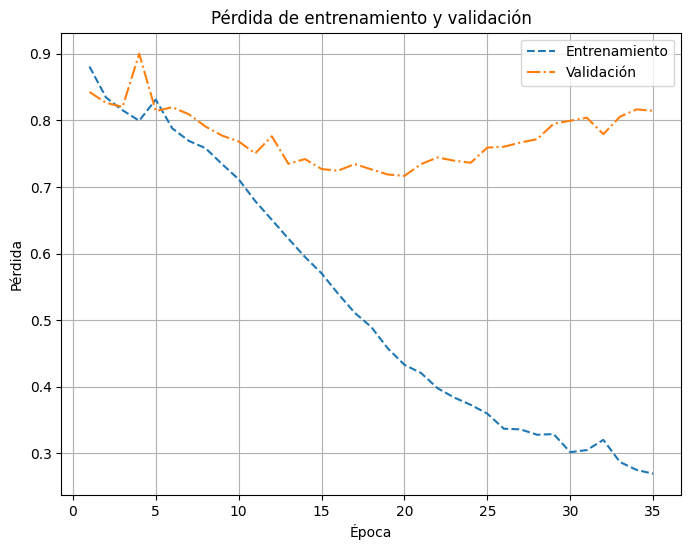

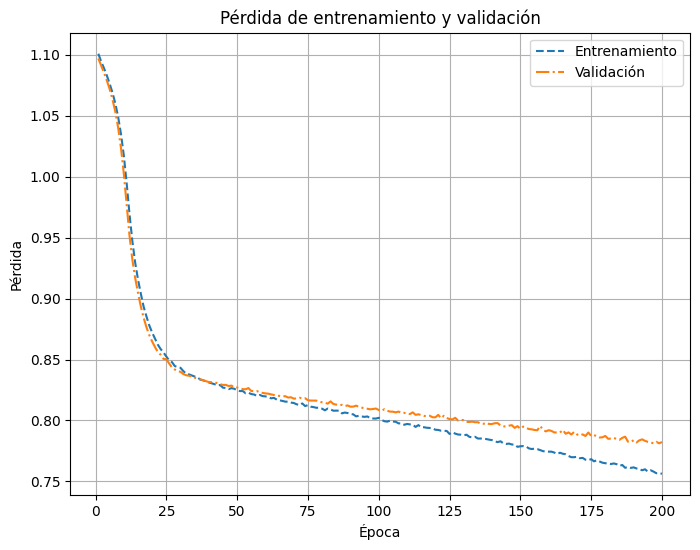

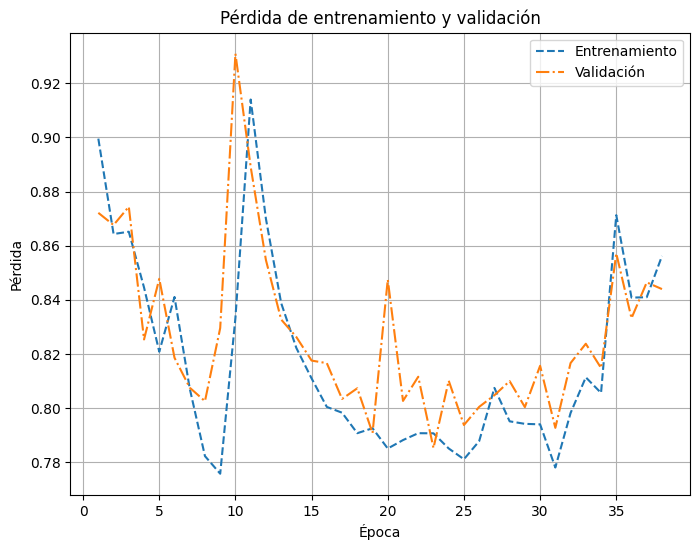

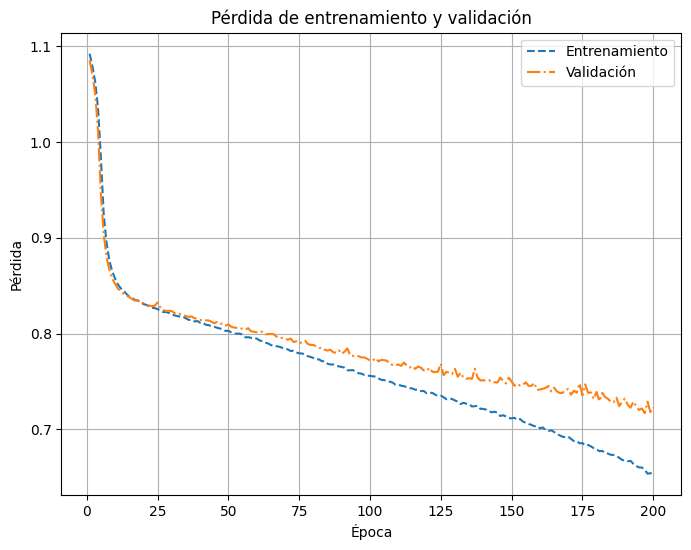

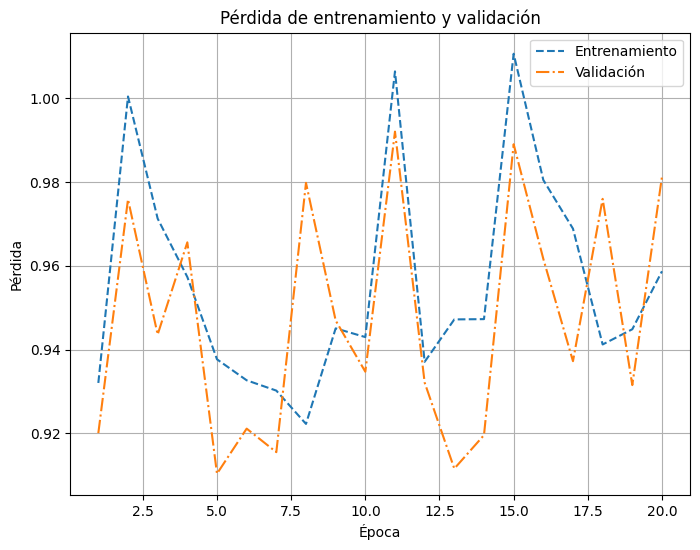

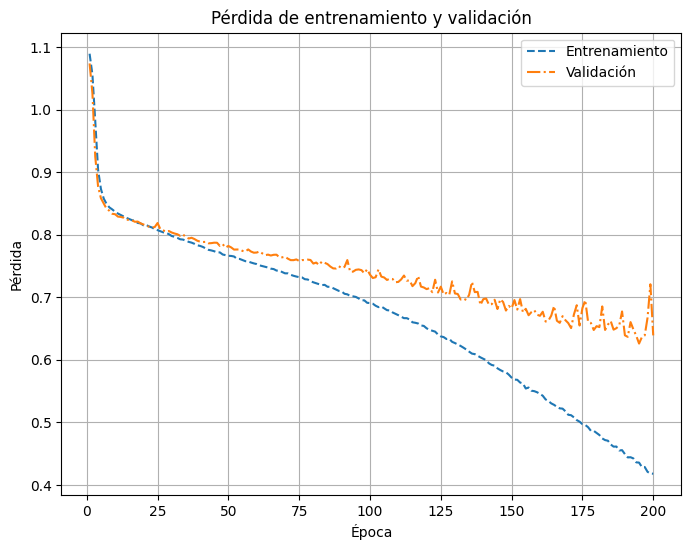

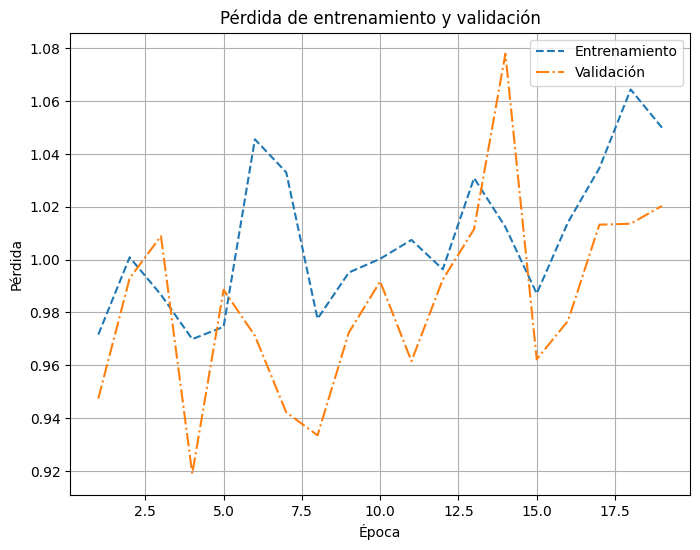

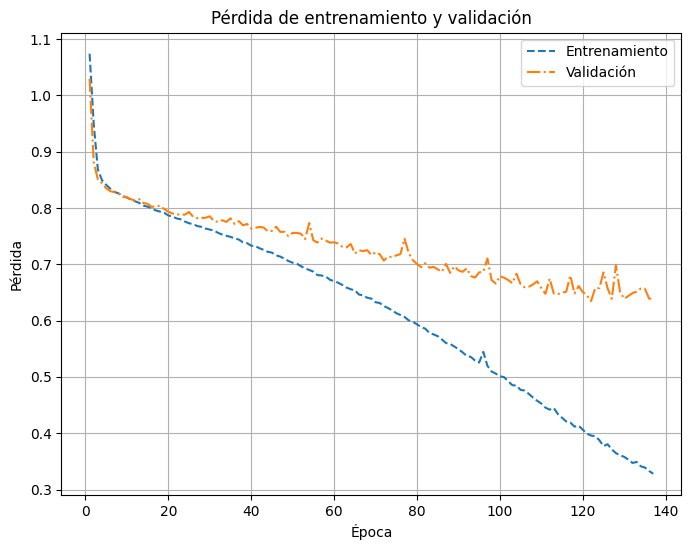

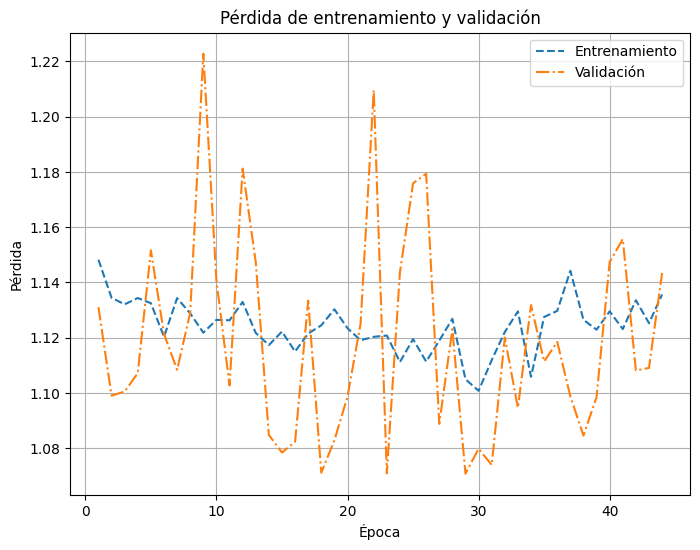

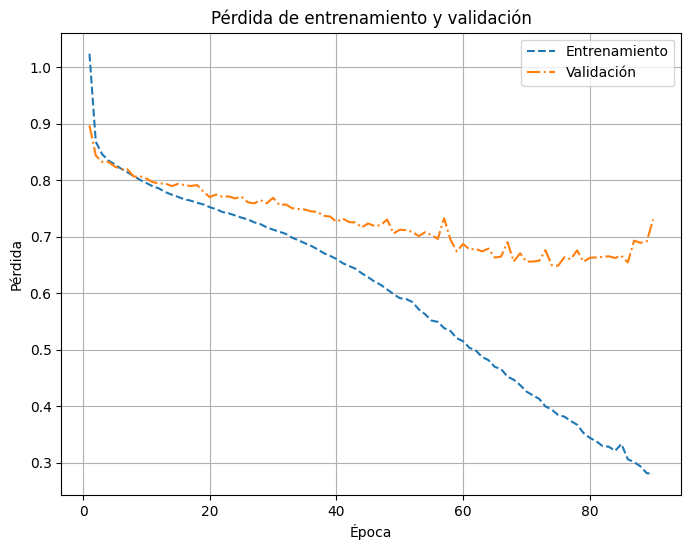

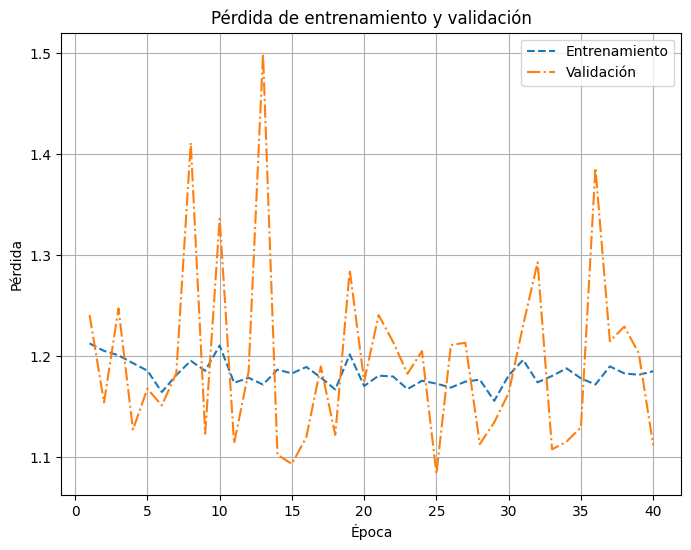

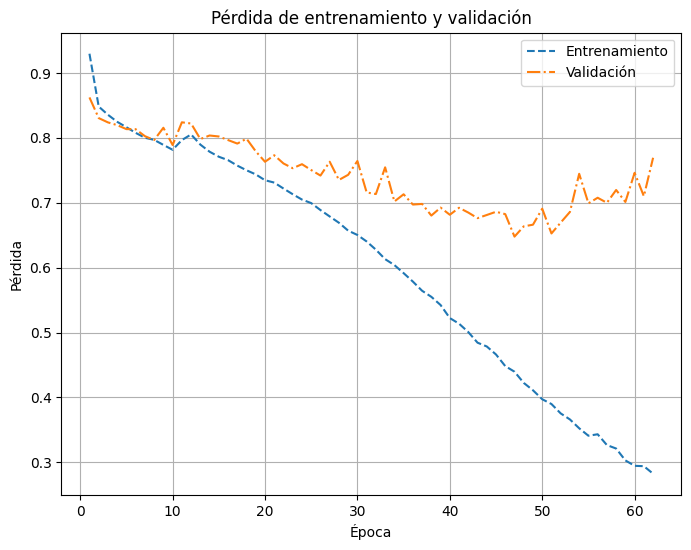

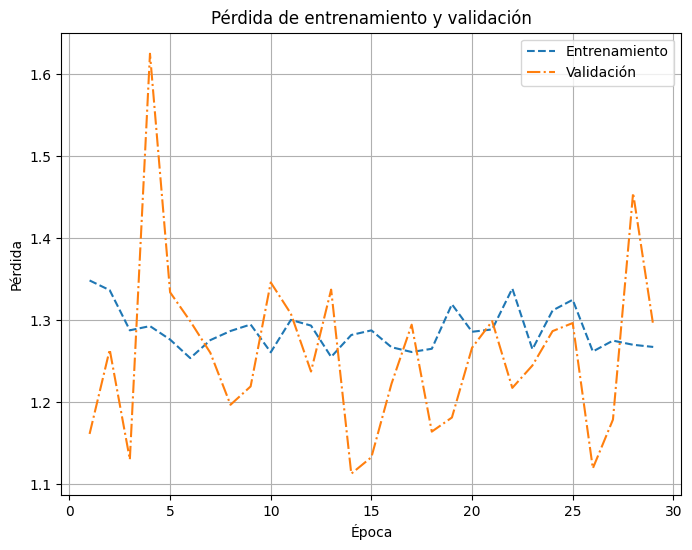

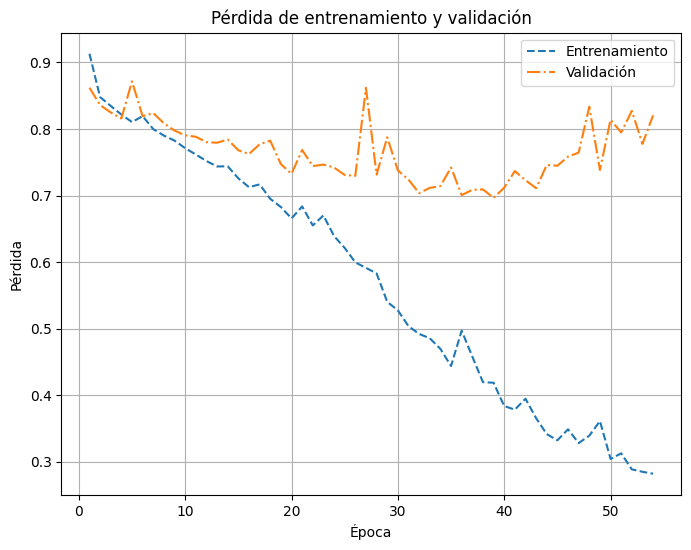

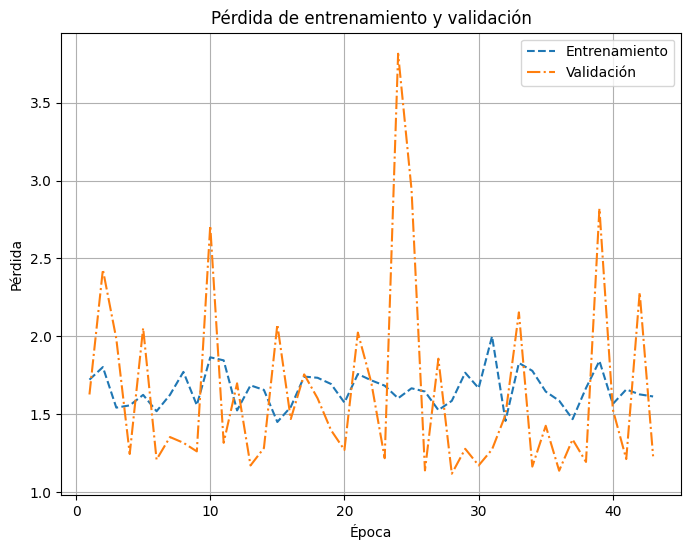

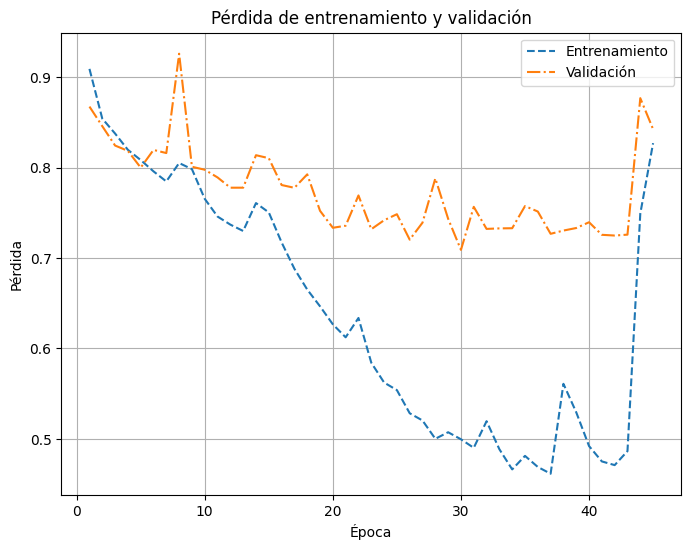

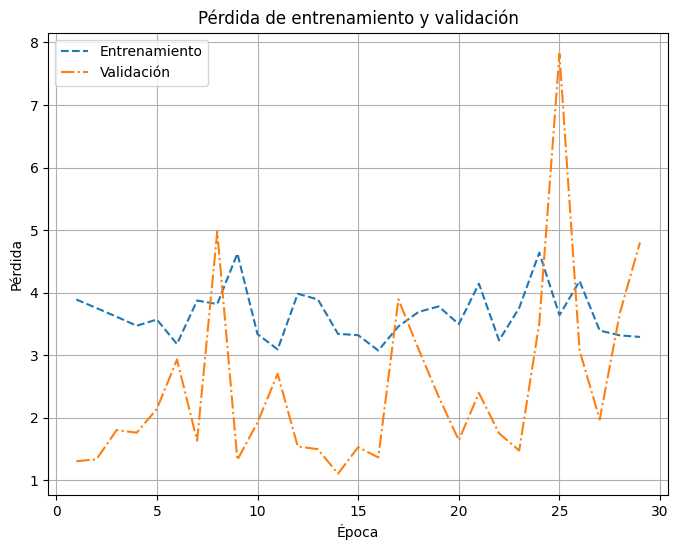

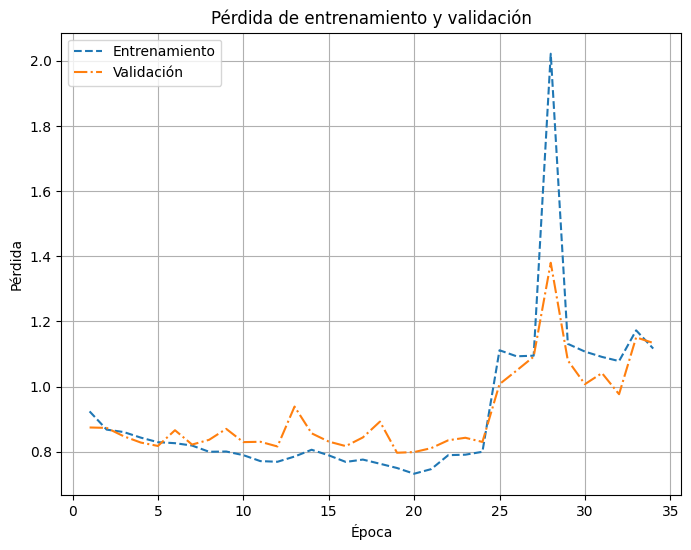

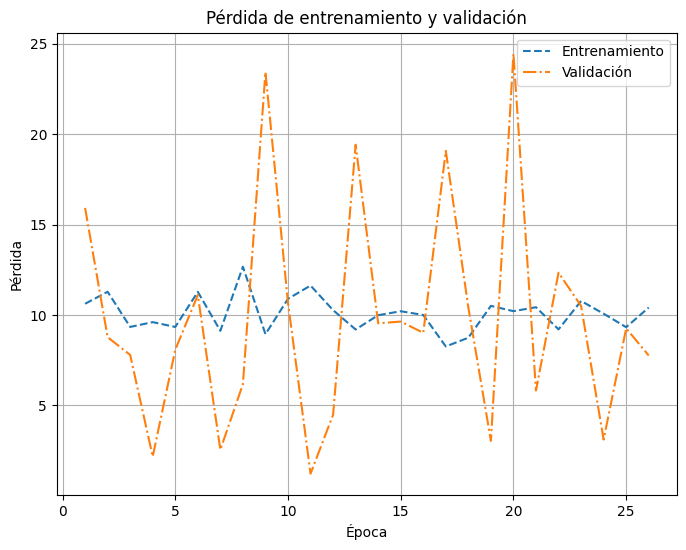

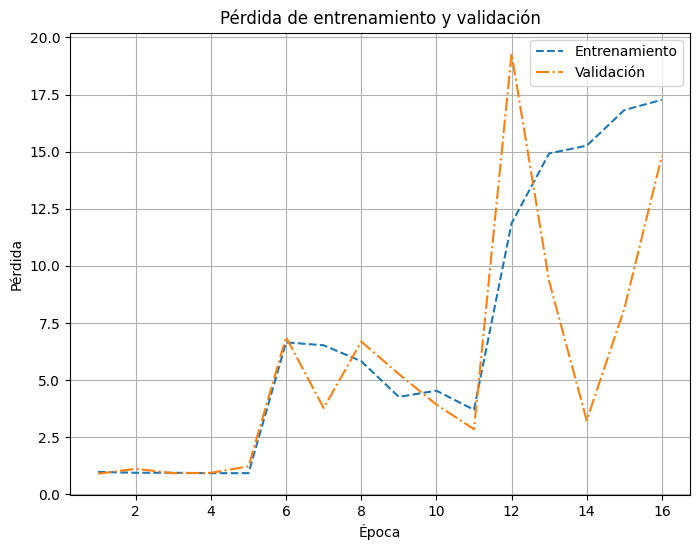

In [8]:
from src.trainers.train_rnn import train_rnn
from src.trainers.utils import save_metrics, show_loss_val_curves, save_model_torch
from constants.constants_twitter import RNN_LOSS_CURVES_DIR, RNN_MODEL_DIR, RNN_METRICS_PATH, EMBEDDING_W2V_TWITTER_PATH

best_accuracy = -1
for idx, param in enumerate(combinaciones, 1):
    model, metrics, train_losses, val_losses = train_rnn(
        dataset_train=dataset_train_tokenized,
        dataset_val=dataset_val_tokenized,
        embeddings_path=EMBEDDING_W2V_TWITTER_PATH,
        model_args=model_args,
        early_stopping = EarlyStopping(patience, min_delta), # reinicio
        batch_size=hp['batch_size'],
        lr=param['lr'],
        epochs=epochs,
        optim=param['optim'],
    )

    metrics['name'] = f"model_{idx}"
    print(f"[{metrics['name']} Acc: {metrics['accuracy']:.4f}] {param}")
    save_metrics(metrics, RNN_METRICS_PATH)

    model_args['input_size'] = metrics['embedding_dim']
    save_model_torch(model.get_model(), model_args, hp, os.path.join(RNN_MODEL_DIR, f"{metrics['name']}.pt"))

    title = f"Pérdida de entrenamiento y validación"
    path = os.path.join(RNN_LOSS_CURVES_DIR, f"{metrics['name']}.png")
    show_loss_val_curves(train_losses, val_losses, len(train_losses), title, path)

    if metrics['accuracy'] > best_accuracy:
        best_accuracy = metrics['accuracy']
        print(f"New best accuracy ({metrics['name']})\n")
        save_model_torch(model.get_model(), model_args, hp, os.path.join(RNN_MODEL_DIR, "best_model.pt"))

In [9]:
import pandas as pd

# Seleccionar los hiperparámetros que generan mayor accuracy
df_metrics = pd.read_csv(RNN_METRICS_PATH)

best_acc = df_metrics.loc[df_metrics['accuracy'].idxmax()]
print(best_acc)

accuracy           0.773158
recall             0.773161
precision          0.773699
f1_score           0.773091
model                   RNN
optim                   sgd
lr                 0.007943
patience                 15
min_delta            0.0001
num_layers                2
hidden_size             128
dropout                 0.2
epochs              137/200
batch_size               64
embedding_dim           100
train_time       548.074079
name                model_8
Name: 7, dtype: object


In [ ]:
import torch
from src.trainers.train_rnn import RNNModel
from src.trainers.trainer_rnn import evaluate_model

checkpoint = torch.load(os.path.join(RNN_MODEL_DIR, "best_model.pt"))
config = checkpoint['config']
hp = checkpoint['hp']

model = RNNModel(**config)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Inferencia (desactiva dropout)

metrics = evaluate_model(
    model,
    dataset_test_tokenized,
    "RNN",
    EMBEDDING_W2V_TWITTER_PATH,
    hp['batch_size']
)
display(metrics)

## LSTM

In [11]:
import numpy as np
from sklearn.model_selection import ParameterGrid
from src.trainers.utils import EarlyStopping

param_grid = {
  "optim": ["adam", "sgd"],
  "lr": np.logspace(-3, -0.3, 10)
}

combinaciones = list(ParameterGrid(param_grid))
for idx, comb in enumerate(combinaciones, 1):
    print(f"Model {idx}: {comb}")

epochs = 200
patience = 15
min_delta = 1e-4
hp = {}
hp['batch_size'] = 64

model_args = {}
model_args['hidden_size'] = 128
model_args['num_layers'] = 2
model_args['output_size'] = 3
model_args['dropout'] = 0.20

Model 1: {'lr': 0.001, 'optim': 'adam'}
Model 2: {'lr': 0.001, 'optim': 'sgd'}
Model 3: {'lr': 0.001995262314968879, 'optim': 'adam'}
Model 4: {'lr': 0.001995262314968879, 'optim': 'sgd'}
Model 5: {'lr': 0.003981071705534973, 'optim': 'adam'}
Model 6: {'lr': 0.003981071705534973, 'optim': 'sgd'}
Model 7: {'lr': 0.00794328234724282, 'optim': 'adam'}
Model 8: {'lr': 0.00794328234724282, 'optim': 'sgd'}
Model 9: {'lr': 0.01584893192461114, 'optim': 'adam'}
Model 10: {'lr': 0.01584893192461114, 'optim': 'sgd'}
Model 11: {'lr': 0.03162277660168381, 'optim': 'adam'}
Model 12: {'lr': 0.03162277660168381, 'optim': 'sgd'}
Model 13: {'lr': 0.06309573444801936, 'optim': 'adam'}
Model 14: {'lr': 0.06309573444801936, 'optim': 'sgd'}
Model 15: {'lr': 0.12589254117941687, 'optim': 'adam'}
Model 16: {'lr': 0.12589254117941687, 'optim': 'sgd'}
Model 17: {'lr': 0.25118864315095824, 'optim': 'adam'}
Model 18: {'lr': 0.25118864315095824, 'optim': 'sgd'}
Model 19: {'lr': 0.5011872336272722, 'optim': 'adam'

Device: cuda


 14%|█▍        | 29/200 [02:24<14:12,  4.99s/it, train_loss=0.0634, val_loss=0.44]


[model_1 Acc: 0.8960] {'lr': 0.001, 'optim': 'adam'}
New best accuracy (model_1)

Device: cuda


100%|██████████| 200/200 [14:48<00:00,  4.44s/it, train_loss=0.844, val_loss=0.844]


[model_2 Acc: 0.6333] {'lr': 0.001, 'optim': 'sgd'}
Device: cuda


...

[model_18 Acc: 0.8721] {'lr': 0.25118864315095824, 'optim': 'sgd'}
Device: cuda


 16%|█▌        | 32/200 [02:55<15:20,  5.48s/it, train_loss=1.56, val_loss=1.36]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[model_19 Acc: 0.3332] {'lr': 0.5011872336272722, 'optim': 'adam'}
Device: cuda


 16%|█▋        | 33/200 [02:52<14:34,  5.24s/it, train_loss=0.0694, val_loss=0.533]


[model_20 Acc: 0.8855] {'lr': 0.5011872336272722, 'optim': 'sgd'}


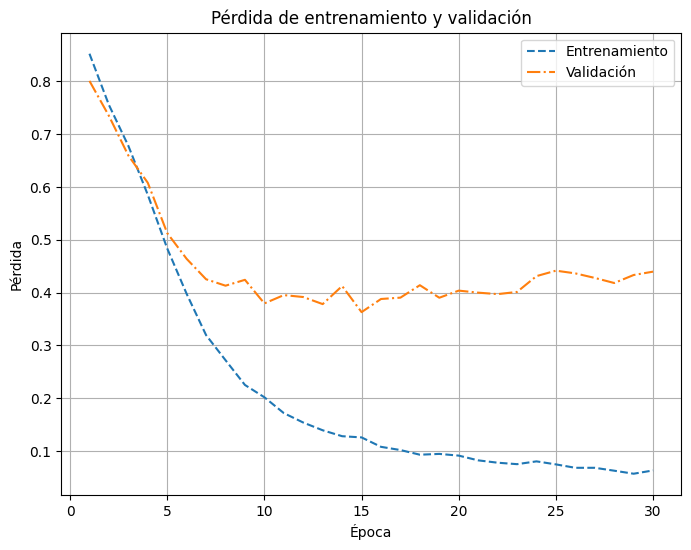

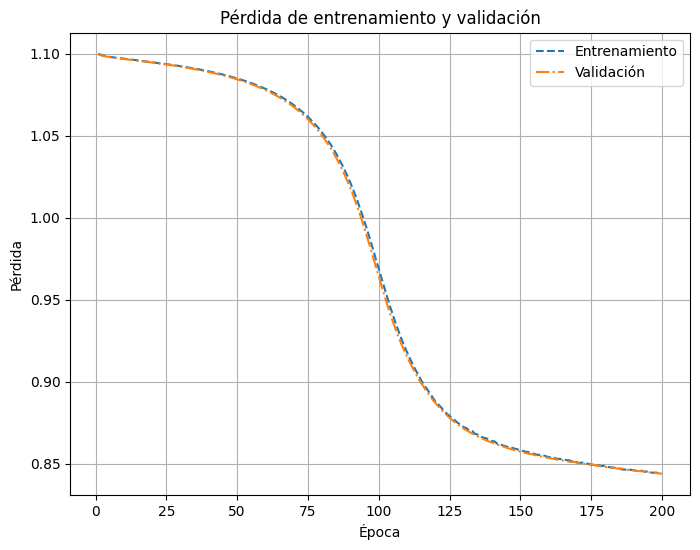

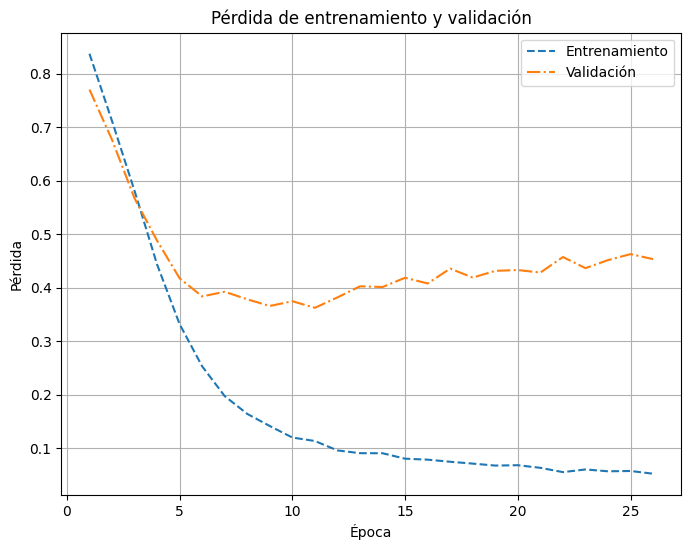

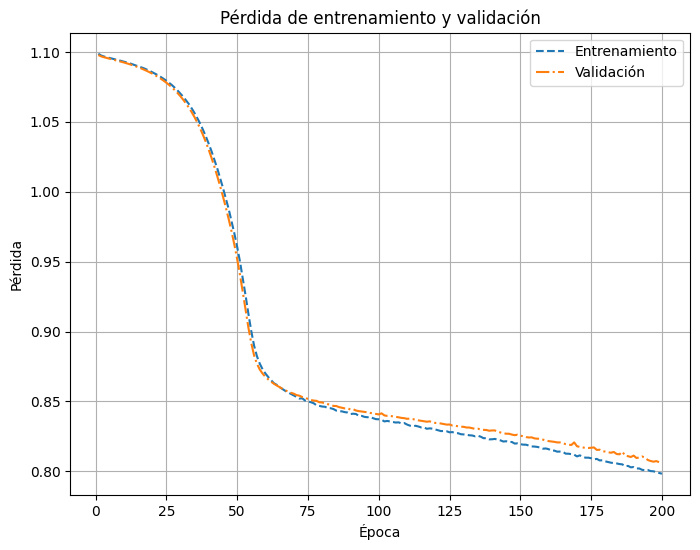

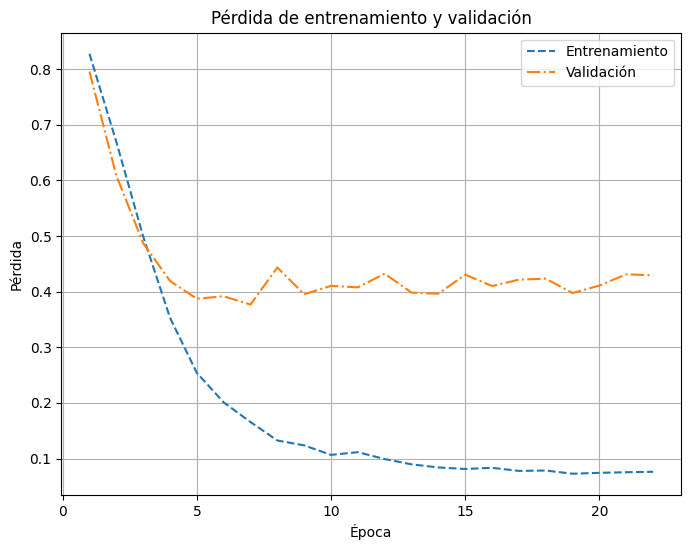

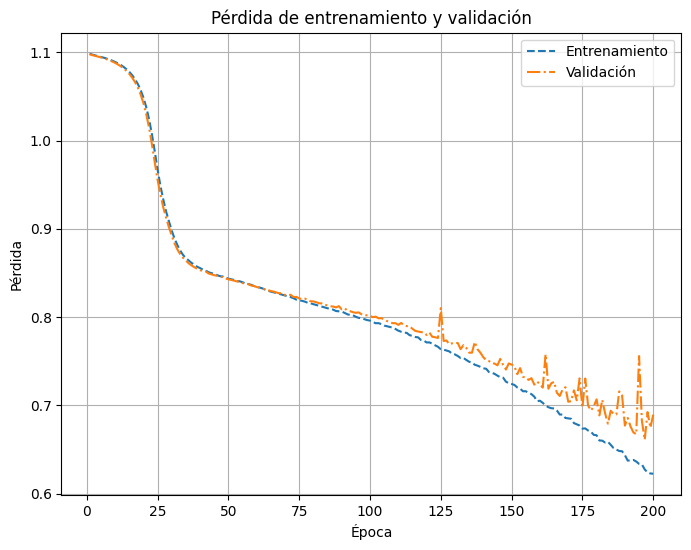

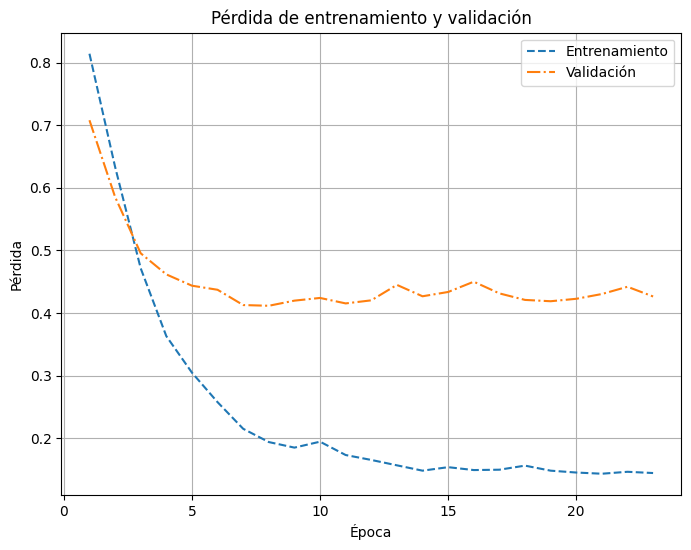

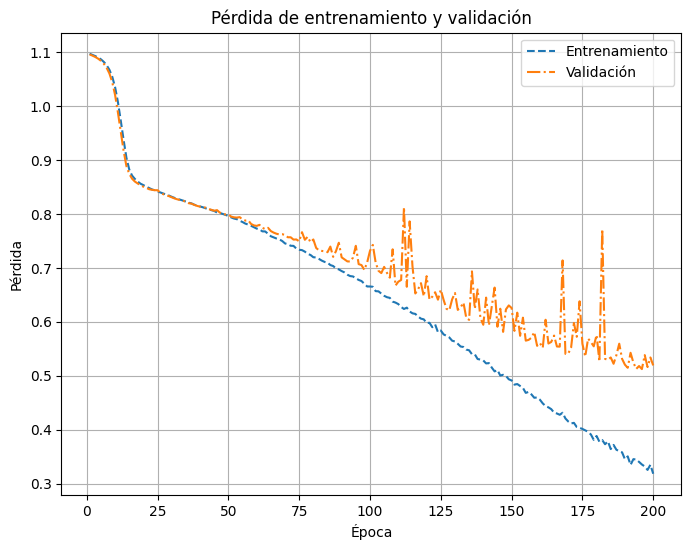

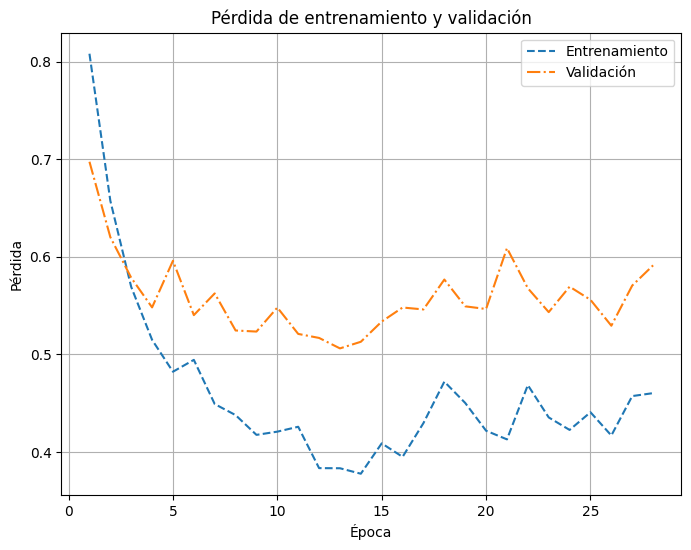

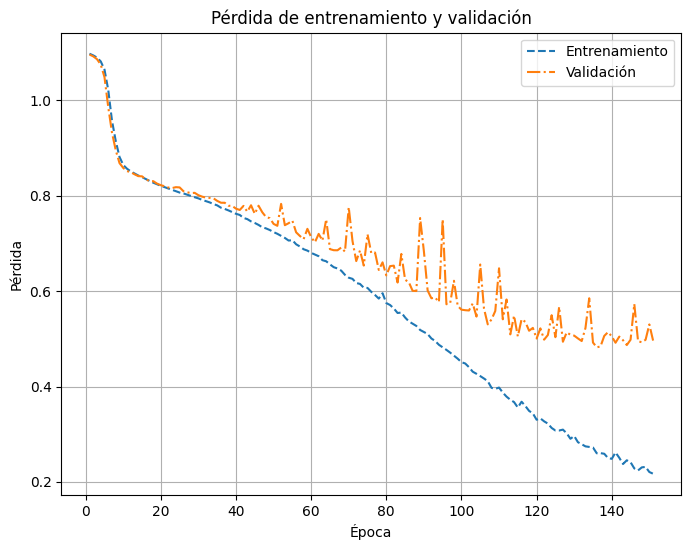

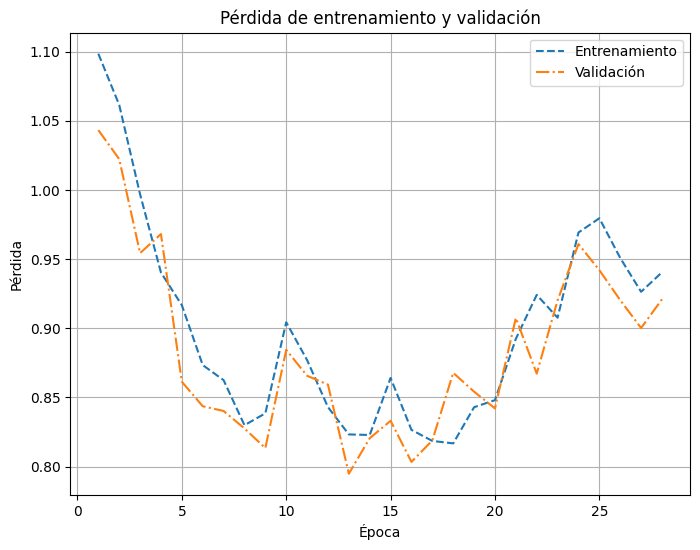

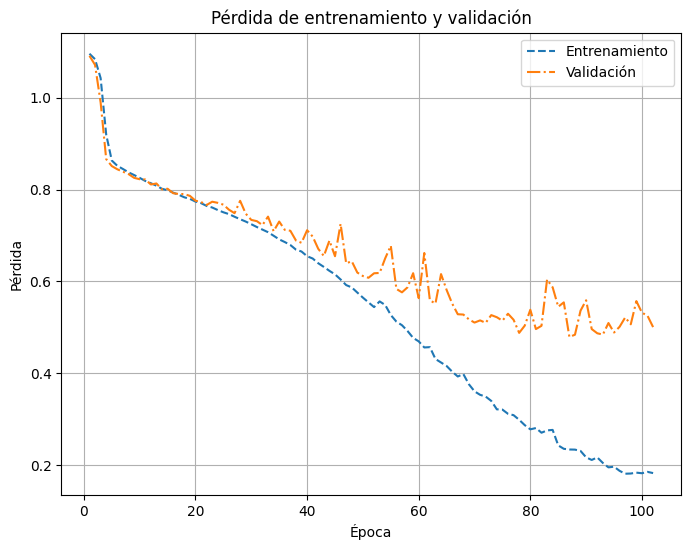

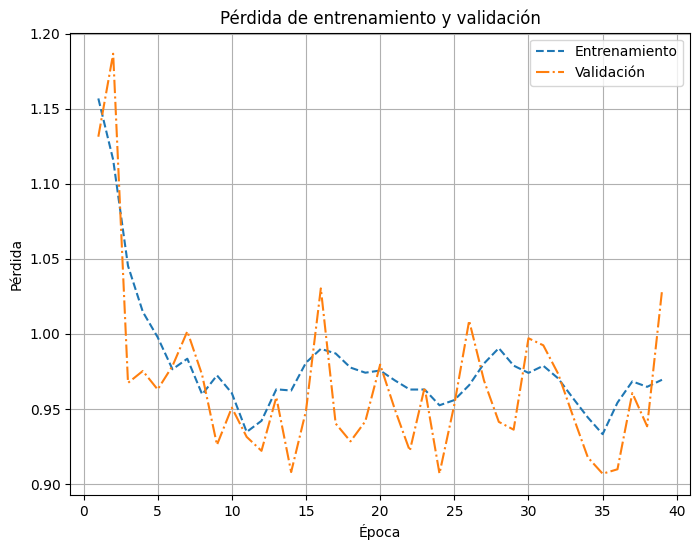

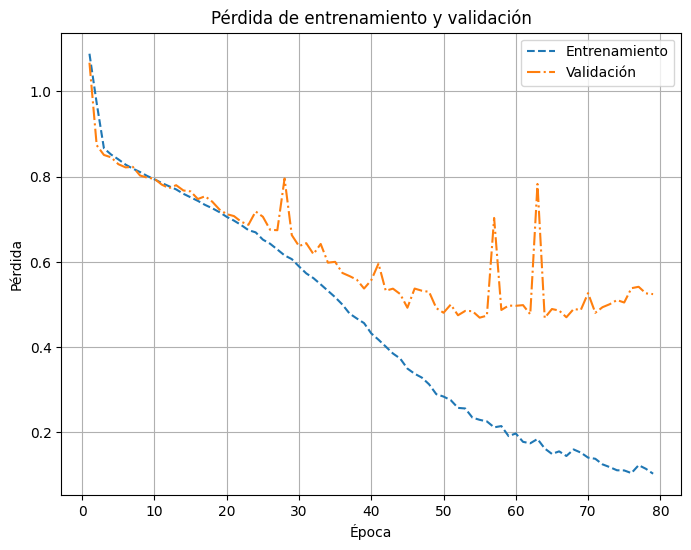

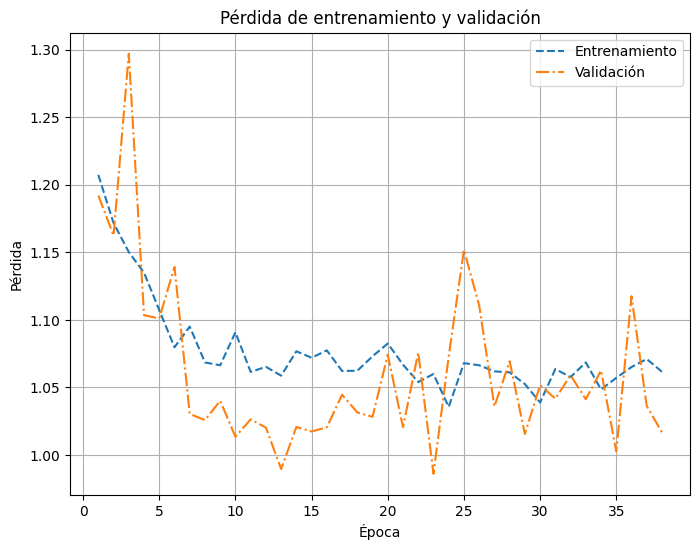

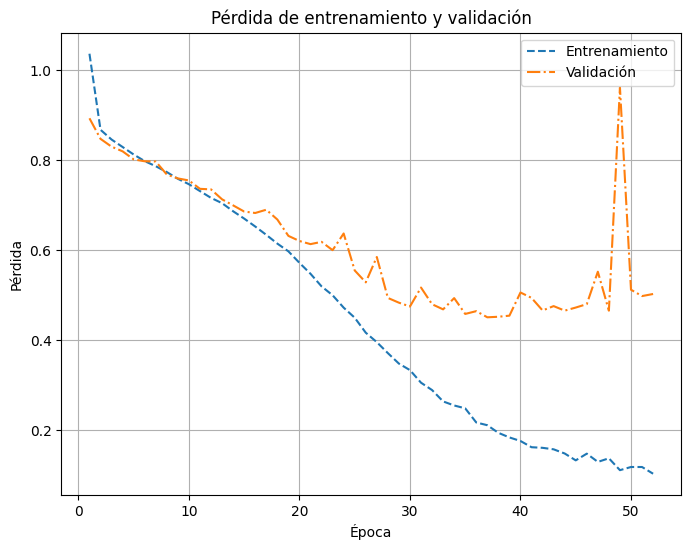

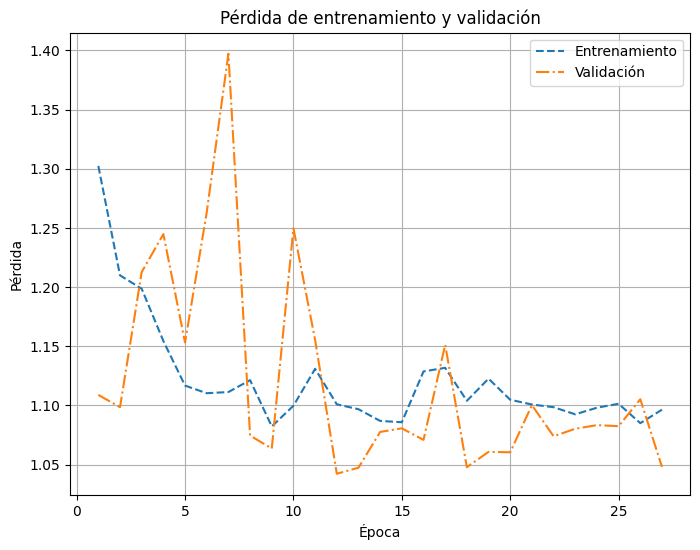

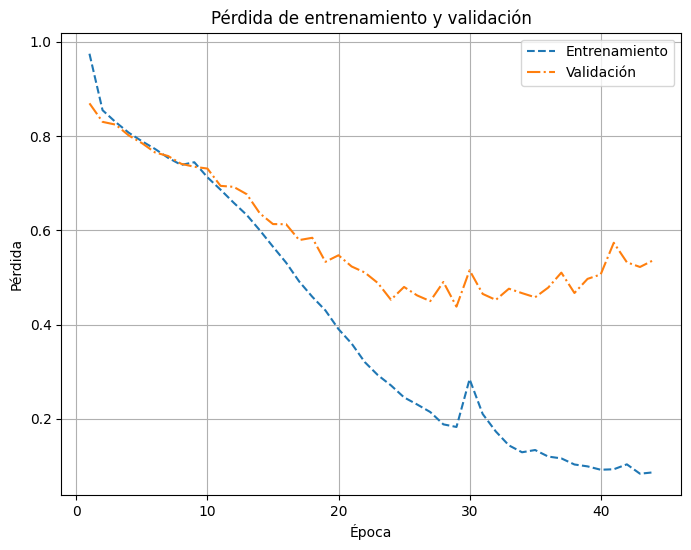

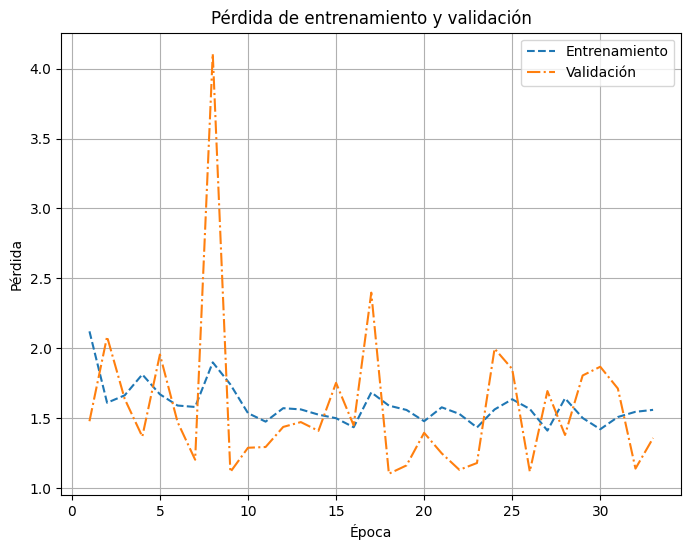

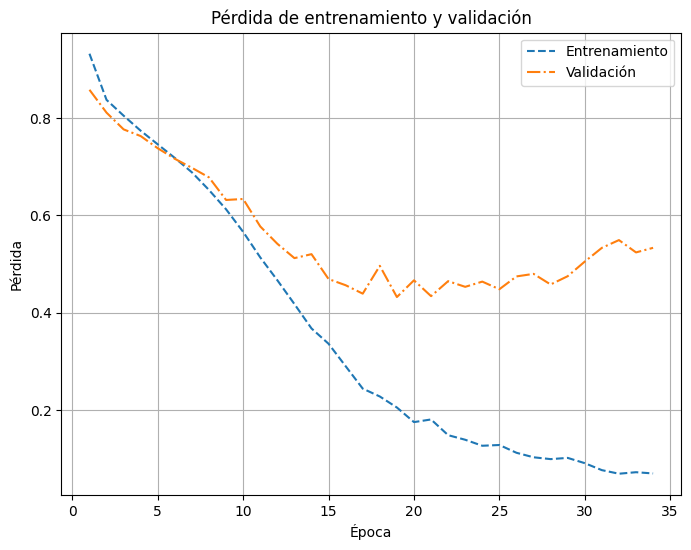

In [12]:
from src.trainers.train_lstm import train_lstm
from src.trainers.utils import save_metrics, show_loss_val_curves, save_model_torch
from constants.constants_twitter import LSTM_LOSS_CURVES_DIR, LSTM_MODEL_DIR, LSTM_METRICS_PATH, EMBEDDING_W2V_TWITTER_PATH

best_accuracy = -1
for idx, param in enumerate(combinaciones, 1):
    model, metrics, train_losses, val_losses = train_lstm(
        dataset_train=dataset_train_tokenized,
        dataset_val=dataset_val_tokenized,
        embeddings_path=EMBEDDING_W2V_TWITTER_PATH,
        model_args=model_args,
        early_stopping = EarlyStopping(patience, min_delta), # reinicio
        batch_size=hp['batch_size'],
        lr=param['lr'],
        epochs=epochs,
        optim=param['optim'],
    )

    metrics['name'] = f"model_{idx}"
    print(f"[{metrics['name']} Acc: {metrics['accuracy']:.4f}] {param}")
    save_metrics(metrics, LSTM_METRICS_PATH)

    model_args['input_size'] = metrics['embedding_dim']
    save_model_torch(model.get_model(), model_args, hp, os.path.join(LSTM_MODEL_DIR, f"{metrics['name']}.pt"))

    title = f"Pérdida de entrenamiento y validación"
    path = os.path.join(LSTM_LOSS_CURVES_DIR, f"{metrics['name']}.png")
    show_loss_val_curves(train_losses, val_losses, len(train_losses), title, path)

    if metrics['accuracy'] > best_accuracy:
        best_accuracy = metrics['accuracy']
        print(f"New best accuracy ({metrics['name']})\n")
        save_model_torch(model.get_model(), model_args, hp, os.path.join(LSTM_MODEL_DIR, "best_model.pt"))

In [13]:
import pandas as pd

# Seleccionar los hiperparámetros que generan mayor accuracy
df_metrics = pd.read_csv(LSTM_METRICS_PATH)

best_acc = df_metrics.loc[df_metrics['accuracy'].idxmax()]
print(best_acc)

accuracy          0.900164
recall            0.900164
precision         0.900253
f1_score          0.900175
model                 LSTM
optim                 adam
lr                0.001995
patience                15
min_delta           0.0001
num_layers               2
hidden_size            128
dropout                0.2
epochs                 200
batch_size              64
embedding_dim          100
train_time       117.56437
name               model_3
Name: 2, dtype: object


In [ ]:
import torch
from src.trainers.train_lstm import LSTMModel
from src.trainers.trainer_rnn import evaluate_model

checkpoint = torch.load(os.path.join(LSTM_MODEL_DIR, "best_model.pt"))
config = checkpoint['config']
hp = checkpoint['hp']

model = LSTMModel(**config)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Inferencia (desactiva dropout)

metrics = evaluate_model(
    model,
    dataset_test_tokenized,
    "LSTM",
    EMBEDDING_W2V_TWITTER_PATH,
    hp['batch_size']
)
display(metrics)